<a href="https://colab.research.google.com/github/LepingWan/testrepo/blob/main/Panini_Course_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



You will work with both supplied 100-question packages. Read
`PROJECT_HANDOUT.pdf` before editing this notebook. Every section
below corresponds to a numbered handout question, and every
explanation cell is part of the submission.

## How to run this notebook on a free Colab GPU

The neural stages are deliberately separated. Never keep two Qwen
models resident at once.

```text
CPU audit and indices
        ↓
Stage A: decomposer → save JSONL → unload model and clear CUDA
        ↓
Stage B: reranker   → save traces/rankings → unload and clear CUDA
        ↓
Stage C: answerer   → save predictions → unload and clear CUDA
```

During development, keep `QUESTION_LIMIT = 2`. Once your tests and
output schemas are correct, set it to `None`, enable exactly one
neural stage, and run all cells. Completed question IDs are read
from JSONL checkpoints, so reconnecting and running again resumes
rather than starts over. The supplied query vectors mean that you
must not load or regenerate the Qwen embedding model.

## Run Map

Use this map after every Colab runtime reset. Run the shared foundation first, then run only the stage you need. Each runnable cell has a searchable banner label at the top, such as `FOUNDATION 1`, `Q7A CONTROL`, or `Q12A`.

| Stage | Runtime | Run These Labeled Cells In Order | Notes |
| --- | --- | --- | --- |
| Foundation | CPU or GPU | `FOUNDATION 1` -> `FOUNDATION 2` -> `FOUNDATION 3` -> `FOUNDATION 4` | Required after every reset. Run `STATUS` after setup if you want a runtime summary. |
| Q1 audit | CPU | Foundation -> `Q1` | No GPU needed. |
| Q2-Q3 graph analysis | CPU | Foundation -> `Q2` -> `Q3` | No GPU needed; save tables/figures before resetting. |
| Q4 parser only | CPU | Foundation -> `Q4A` | No model loaded. |
| Q4 decomposition | GPU, T4 first | Foundation -> `Q4A` -> `Q4B / STAGE A` | Set only `RUN_DECOMPOSITION_STAGE=True`. Writes `decompositions.jsonl`. |
| Q4 decomposition audit | CPU | Foundation -> `Q4A` -> `Q4C` | Reads saved decompositions; no Qwen model. |
| Q5-Q6 retrieval | CPU | Foundation -> `Q5` -> `Q6` | FAISS/query embeddings are supplied; no Qwen model. |
| Q7 reranker audit | GPU, bounded | Foundation -> `Q5` -> `Q6` -> `Q7` -> `Q7A CONTROL` -> `Q7A` | Safe default is 20 tasks per dataset. Writes `cache/q7_rerank_audit.jsonl` and resumes by `question_id`. |
| Q7-Q8 default RICR | GPU, T4 first | Foundation -> `Q4A` -> `Q5` -> `Q6` -> `Q7` -> `Q8A` -> `Q8B / STAGE B` | Set only `RUN_RERANK_AND_RICR_STAGE=True`. Reads decompositions and writes default RICR traces. |
| Q9 ablations | GPU | Foundation -> `Q4A` -> `Q9 FAST BOOTSTRAP` -> `Q9 CONTROL` -> `Q9` | Run after Q8B default traces exist. Writes non-default configurations into `ricr_traces.jsonl`. |
| Q10 answer generation | GPU | Foundation -> `Q10A CONTROL` -> `Q10A / STAGE C` | Set only `RUN_ANSWER_STAGE=True`; reads saved RICR traces and writes `answers.jsonl`. |
| Q10-Q12 final CPU replay | CPU | Foundation -> `FINAL CPU REPLAY CONTROL` -> `Q10C` -> `Q11` -> `Q12A` -> `Q12B` | Reads saved checkpoints, regenerates richer metrics, final JSONL schema, environment, and RUNME. No Qwen model. |

For a cheap smoke test, keep all neural flags false and `QUESTION_LIMIT=2`. For a model stage, turn on exactly one expensive flag, run that stage, save/pull outputs, then restart or clear GPU memory before the next model stage. For final CPU replay, keep every expensive flag false and `QUESTION_LIMIT=None`.


In [1]:
# === STATUS: Run Context Helper (safe anytime) ===
def print_run_context():
    import json as _json
    try:
        import torch
        cuda_available = torch.cuda.is_available()
        gpu_name = torch.cuda.get_device_name(0) if cuda_available else None
        gpu_memory_gib = (
            round(torch.cuda.get_device_properties(0).total_memory / 2**30, 2)
            if cuda_available else None
        )
    except Exception:
        cuda_available = False
        gpu_name = None
        gpu_memory_gib = None

    stage_flags = {
        'RUN_DECOMPOSITION_STAGE': globals().get('RUN_DECOMPOSITION_STAGE', False),
        'RUN_RERANK_AND_RICR_STAGE': globals().get('RUN_RERANK_AND_RICR_STAGE', False),
        'RUN_ANSWER_STAGE': globals().get('RUN_ANSWER_STAGE', False),
        'RUN_ABLATIONS': globals().get('RUN_ABLATIONS', False),
        'RUN_Q7_RERANK_AUDIT': globals().get('RUN_Q7_RERANK_AUDIT', False),
    }
    context = {
        'question_limit': globals().get('QUESTION_LIMIT', 'not initialized'),
        'mount_drive_in_colab': globals().get('MOUNT_DRIVE_IN_COLAB', 'not initialized'),
        'require_durable_work_root': globals().get('REQUIRE_DURABLE_WORK_ROOT', 'not initialized'),
        'work_root_is_durable': globals().get('WORK_ROOT_IS_DURABLE', 'not initialized'),
        'strict_smoke_tests': globals().get('STRICT_SMOKE_TESTS', 'not initialized'),
        'run_decomposition_stage': stage_flags['RUN_DECOMPOSITION_STAGE'],
        'run_rerank_and_ricr_stage': stage_flags['RUN_RERANK_AND_RICR_STAGE'],
        'run_answer_stage': stage_flags['RUN_ANSWER_STAGE'],
        'run_ablations': stage_flags['RUN_ABLATIONS'],
        'run_q7_rerank_audit': stage_flags['RUN_Q7_RERANK_AUDIT'],
        'cuda_available': cuda_available,
        'gpu_name': gpu_name,
        'gpu_memory_gib': gpu_memory_gib,
        'work_root': str(globals().get('WORK_ROOT', 'not initialized')),
        'repo_root': str(globals().get('REPO_ROOT', 'not initialized')),
    }
    print(_json.dumps(context, indent=2))
    enabled = [name for name, enabled in stage_flags.items() if enabled]
    if len(enabled) > 1:
        print('WARNING: more than one expensive stage flag is enabled:', enabled)
    elif enabled:
        print('Enabled expensive stage:', enabled[0])
    else:
        print('No expensive model stage enabled.')

print_run_context()


{
  "question_limit": "not initialized",
  "mount_drive_in_colab": "not initialized",
  "require_durable_work_root": "not initialized",
  "work_root_is_durable": "not initialized",
  "strict_smoke_tests": "not initialized",
  "run_decomposition_stage": false,
  "run_rerank_and_ricr_stage": false,
  "run_answer_stage": false,
  "run_ablations": false,
  "run_q7_rerank_audit": false,
  "cuda_available": false,
  "gpu_name": null,
  "gpu_memory_gib": null,
  "work_root": "not initialized",
  "repo_root": "not initialized"
}
No expensive model stage enabled.


In [2]:
# === FOUNDATION 1: Run Controls ===
# Run controls. Change one neural stage at a time.
# Defaults are cheap and restart-safe: they let Runtime > Run all complete
# without loading Qwen models. Turn on one expensive stage at a time in Colab.
RUN_DECOMPOSITION_STAGE = False
RUN_RERANK_AND_RICR_STAGE = False
RUN_ANSWER_STAGE = False
RUN_ABLATIONS = False
RUN_Q7_RERANK_AUDIT = False

# Use 2 while developing. Set to None for every required final run.
QUESTION_LIMIT = None
# Keep long-running checkpoints on Google Drive instead of disposable /content.
MOUNT_DRIVE_IN_COLAB = True
# If Drive cannot mount in Colab, stop before expensive stages write wipeable checkpoints.
REQUIRE_DURABLE_WORK_ROOT = True
STRICT_SMOKE_TESTS = False
DATASETS = ('2wiki',
            'musique'
            )
# For debugging Q4B, you may temporarily use DATASETS = ('2wiki',)
# to verify one dataset before running both.

# Frozen default configuration from the project specification.
BEAM_WIDTH = 5
CANDIDATES_PER_HOP = 15
RETRIEVAL_POOL = 60
RRF_CONSTANT = 60.0
MULTI_PARENT_THRESHOLD = 0.3


In [3]:
# === FOUNDATION 2: Colab/Repo Setup And Paths ===
from pathlib import Path
import gc, json, os, platform, shutil, subprocess, sys, time

IN_COLAB = 'google.colab' in sys.modules
DEFAULT_REPO_URL = 'https://github.com/YigitTurali/panini-course-project.git'
DEFAULT_STUDENT_REPO_URL = 'https://github.com/LepingWan/testrepo.git'
PANINI_REPO_URL = os.environ.get('PANINI_REPO_URL', DEFAULT_REPO_URL)
PANINI_STUDENT_REPO_URL = os.environ.get('PANINI_STUDENT_REPO_URL', DEFAULT_STUDENT_REPO_URL)
PANINI_STUDENT_REPO_BRANCH = os.environ.get('PANINI_STUDENT_REPO_BRANCH', 'main')

if IN_COLAB:
    REPO_ROOT = Path(os.environ.get('PANINI_REPO_ROOT', '/content/panini-course-project'))
    if not (REPO_ROOT / 'manifest.json').exists():
        if REPO_ROOT.exists() and any(REPO_ROOT.iterdir()):
            raise FileNotFoundError(
                f'{REPO_ROOT} exists but does not look like the Panini package. '
                'Set PANINI_REPO_ROOT to a clean path or delete the partial clone.'
            )
        subprocess.run([
            'git', 'clone', '--depth', '1',
            PANINI_REPO_URL,
            str(REPO_ROOT),
        ], check=True)

    requirements = REPO_ROOT / 'requirements-colab.txt'
    if requirements.exists():
        subprocess.run([
            sys.executable, '-m', 'pip', 'install', '-q', '-r',
            str(requirements),
        ], check=True)

    if MOUNT_DRIVE_IN_COLAB:
        try:
            from google.colab import drive
            drive.mount('/content/drive', force_remount=True)
            WORK_ROOT = Path('/content/drive/MyDrive/panini-course-project-work')
        except Exception as error:
            print(f'Drive mount failed ({error!r}); falling back to temporary /content storage.')
            WORK_ROOT = Path('/content/panini-course-project-work')
    else:
        WORK_ROOT = Path('/content/panini-course-project-work')
else:
    here = Path.cwd().resolve()
    if (here / 'manifest.json').exists():
        REPO_ROOT = here
    else:
        source = here
        while source != source.parent and not (source / 'course_project').exists():
            source = source.parent
        if not (source / 'course_project').exists():
            raise FileNotFoundError(
                'Run from the public Panini repository, the gsw-memory checkout, '
                'or Colab. This lightweight testrepo contains only the notebook.'
            )
        REPO_ROOT = source / 'course_project/release/panini_2wiki_100'
    WORK_ROOT = Path(os.environ.get('PANINI_STUDENT_WORK', here / 'panini-student-work'))

PACKAGE_ROOTS = {
    '2wiki': REPO_ROOT,
    'musique': REPO_ROOT / 'packages/panini_musique_100'
        if (REPO_ROOT / 'packages').exists()
        else REPO_ROOT.parent / 'panini_musique_100',
}
sys.path.insert(0, str(REPO_ROOT))
WORK_ROOT_IS_DURABLE = (not IN_COLAB) or str(WORK_ROOT).startswith('/content/drive/')
if IN_COLAB and not WORK_ROOT_IS_DURABLE:
    warning = (
        f'WARNING: WORK_ROOT={WORK_ROOT} is temporary Colab storage. '
        'Runtime disconnects can wipe JSONL checkpoints.'
    )
    if globals().get('REQUIRE_DURABLE_WORK_ROOT', False):
        raise RuntimeError(
            warning + ' Set MOUNT_DRIVE_IN_COLAB=True and complete Drive authorization, '
            'or temporarily set REQUIRE_DURABLE_WORK_ROOT=False for a disposable smoke run.'
        )
    print(warning)
WORK_ROOT.mkdir(parents=True, exist_ok=True)

STUDENT_CODE_ROOT = WORK_ROOT / 'student_code'
LOCAL_STUDENT_CODE_ROOT = Path.cwd().resolve() / 'student_code'
TEAM_REPO_ROOT = Path(os.environ.get('PANINI_STUDENT_REPO_ROOT', '/content/panini-student-repo'))
TEAM_STUDENT_CODE_ROOT = TEAM_REPO_ROOT / 'student_code'

if IN_COLAB and not (LOCAL_STUDENT_CODE_ROOT / 'ricr.py').exists():
    if TEAM_REPO_ROOT.exists() and any(TEAM_REPO_ROOT.iterdir()) and not (TEAM_REPO_ROOT / '.git').exists():
        raise FileNotFoundError(
            f'{TEAM_REPO_ROOT} exists but is not the team repo. '
            'Set PANINI_STUDENT_REPO_ROOT to a clean path.'
        )
    if (TEAM_REPO_ROOT / '.git').exists():
        subprocess.run([
            'git', '-C', str(TEAM_REPO_ROOT), 'pull', '--ff-only',
            'origin', PANINI_STUDENT_REPO_BRANCH,
        ], check=True)
    elif not (TEAM_STUDENT_CODE_ROOT / 'ricr.py').exists():
        subprocess.run([
            'git', 'clone', '--depth', '1', '--branch', PANINI_STUDENT_REPO_BRANCH,
            PANINI_STUDENT_REPO_URL,
            str(TEAM_REPO_ROOT),
        ], check=True)

VERSIONED_STUDENT_CODE_ROOT = (
    LOCAL_STUDENT_CODE_ROOT if (LOCAL_STUDENT_CODE_ROOT / 'ricr.py').exists()
    else TEAM_STUDENT_CODE_ROOT
)

STUDENT_CODE_ROOT.mkdir(parents=True, exist_ok=True)
PERSISTENT_RICR = STUDENT_CODE_ROOT / 'ricr.py'
RUNTIME_RICR = REPO_ROOT / 'panini_course' / 'ricr.py'
VERSIONED_RICR = VERSIONED_STUDENT_CODE_ROOT / 'ricr.py'
if VERSIONED_RICR.exists():
    shutil.copy2(VERSIONED_RICR, PERSISTENT_RICR)
elif not PERSISTENT_RICR.exists() and RUNTIME_RICR.exists():
    shutil.copy2(RUNTIME_RICR, PERSISTENT_RICR)
if PERSISTENT_RICR.exists() and RUNTIME_RICR.exists():
    shutil.copy2(PERSISTENT_RICR, RUNTIME_RICR)

PERSISTENT_TESTS = STUDENT_CODE_ROOT / 'test_student_ricr.py'
VERSIONED_TESTS = VERSIONED_STUDENT_CODE_ROOT / 'test_student_ricr.py'
if VERSIONED_TESTS.exists():
    shutil.copy2(VERSIONED_TESTS, PERSISTENT_TESTS)
elif not PERSISTENT_TESTS.exists():
    PERSISTENT_TESTS.write_text(
        "import pytest\n\n"
        "@pytest.mark.skip(reason='Replace with your own reconciliation/RICR test')\n"
        "def test_student_failure_case():\n"
        "    pass\n",
        encoding='utf-8',
    )
RUNTIME_STUDENT_TESTS = REPO_ROOT / 'tests' / 'test_student_work.py'
if PERSISTENT_TESTS.exists() and RUNTIME_STUDENT_TESTS.parent.exists():
    shutil.copy2(PERSISTENT_TESTS, RUNTIME_STUDENT_TESTS)

# If panini_course was already imported before this fix, clear stale modules.
for module_name in list(sys.modules):
    if module_name == 'panini_course' or module_name.startswith('panini_course.'):
        del sys.modules[module_name]

print({
    'repo': str(REPO_ROOT),
    'work': str(WORK_ROOT),
    'work_root_is_durable': WORK_ROOT_IS_DURABLE,
    'colab': IN_COLAB,
    'repo_url': PANINI_REPO_URL,
    'student_repo_url': PANINI_STUDENT_REPO_URL,
    'student_code_source': str(VERSIONED_STUDENT_CODE_ROOT),
    'runtime_ricr': str(RUNTIME_RICR),
    'runtime_ricr_has_todo_scaffold': 'Implement PANINI DAG RICR' in RUNTIME_RICR.read_text(encoding='utf-8'),
    'edit_ricr_here': str(PERSISTENT_RICR),
    'edit_tests_here': str(PERSISTENT_TESTS),
})


Mounted at /content/drive
{'repo': '/content/panini-course-project', 'work': '/content/drive/MyDrive/panini-course-project-work', 'work_root_is_durable': True, 'colab': True, 'repo_url': 'https://github.com/YigitTurali/panini-course-project.git', 'student_repo_url': 'https://github.com/LepingWan/testrepo.git', 'student_code_source': '/content/panini-student-repo/student_code', 'runtime_ricr': '/content/panini-course-project/panini_course/ricr.py', 'runtime_ricr_has_todo_scaffold': False, 'edit_ricr_here': '/content/drive/MyDrive/panini-course-project-work/student_code/ricr.py', 'edit_tests_here': '/content/drive/MyDrive/panini-course-project-work/student_code/test_student_ricr.py'}


## Shared checkpoint and memory helpers

These helpers are infrastructure, not answers to a graded
algorithm. Each expensive stage appends one complete record at a
time. Do not keep results only in Python variables.

In [4]:
# === FOUNDATION 3: Shared Checkpoint Helpers ===
def read_jsonl(path):
    path = Path(path)
    if not path.exists():
        return []
    with path.open(encoding='utf-8') as handle:
        return [json.loads(line) for line in handle if line.strip()]

def append_jsonl(path, row):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('a', encoding='utf-8') as handle:
        handle.write(json.dumps(row, ensure_ascii=False) + '\n')

def completed_ids(path, *, configuration=None):
    rows = read_jsonl(path)
    if configuration is not None:
        rows = [row for row in rows if row.get('configuration') == configuration]
    return {str(row['question_id']) for row in rows}

def release_gpu(*objects):
    # Delete caller-owned model variables before calling this helper.
    for value in objects:
        del value
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
    except Exception:
        pass

def selected_questions(package):
    rows = package.questions('public') + package.questions('held_out')
    return rows if QUESTION_LIMIT is None else rows[:QUESTION_LIMIT]

def require_full_run():
    assert QUESTION_LIMIT is None, 'Set QUESTION_LIMIT = None before producing final files.'

In [5]:
# === FOUNDATION 4: Imports And CoursePackage Loading ===
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display
from panini_course import CoursePackage

packages = {name: CoursePackage(path) for name, path in PACKAGE_ROOTS.items()}
for name, package in packages.items():
    print(name, package.manifest['counts'])

2wiki {'questions_total': 100, 'questions_public': 80, 'questions_held_out': 20, 'documents': 765, 'gsws': 765, 'entities': 6805, 'qa_pairs': 8887}
musique {'questions_total': 100, 'questions_public': 80, 'questions_held_out': 20, 'documents': 841, 'gsws': 841, 'entities': 8260, 'qa_pairs': 9991}


In [ ]:
# === Q1: Dataset/Split Count Table ===
import pandas as pd
import json

def count_decomposition_examples(dataset, split, package):
    path = PACKAGE_ROOTS[dataset] / 'questions' / 'decomposition_validation.jsonl'
    if not path.exists():
        return 0
    split_ids = {str(row['question_id']) for row in package.questions(split)}
    rows = [json.loads(line) for line in path.open(encoding='utf-8') if line.strip()]
    return sum(str(row.get('question_id')) in split_ids for row in rows)

q1_dataset_rows = []
for dataset, package in packages.items():
    entities = package.entities()
    qa_pairs = package.qa_pairs()

    documents = {row.get('document_id') for row in entities if row.get('document_id')}
    gsw_files = {
        (row.get('document_id'), row.get('gsw_file'))
        for row in entities
        if row.get('document_id') and row.get('gsw_file')
    }

    for split in ('public', 'held_out'):
        q1_dataset_rows.append({
            'dataset': dataset,
            'split': split,
            'questions': len(package.questions(split)),
            'unique_documents': len(documents),
            'gsw_files': len(gsw_files),
            'entities': len(entities),
            'qa_records': len(qa_pairs),
            'decomposition_validation_examples': count_decomposition_examples(dataset, split, package),
        })

q1_dataset_table = pd.DataFrame(q1_dataset_rows)
display(q1_dataset_table)

,dataset,split,questions,unique_documents,gsw_files,entities,qa_records,decomposition_validation_examples
0,2wiki,public,80,765,765,6805,8887,20
1,2wiki,held_out,20,765,765,6805,8887,0
2,musique,public,80,841,841,8260,9991,80
3,musique,held_out,20,841,841,8260,9991,0


## Question 1 — understand and verify the two packages (6 points)

Audit stable identifiers and artifact alignment before doing any
retrieval. Equal row counts alone are not sufficient. Inspect one
public question, held-out question, entity, and QA record from each
dataset. Confirm that held-out rows expose no answer or gold
evidence fields.

In [ ]:
# === Q1: Package Audit ===
def audit_package(package, dataset):
    # TODO Q1:
    # 1. Check uniqueness of entity_uid and qa_uid.
    # 2. Check exact ID-set equality between metadata and every
    #    embedding/index ID file used later.
    # 3. Check matrix row counts and embedding dimensions.
    # 4. Check held-out field names for label leakage.
    # 5. Return one flat dictionary for a two-row audit table.
    entities = package.entities()
    qa_pairs = package.qa_pairs()
    entity_ids = [row['entity_uid'] for row in entities]
    qa_ids = [row['qa_uid'] for row in qa_pairs]

    root = package.root
    embed_entity_ids = json.loads((root / 'embeddings' / 'entity_ids.json').read_text())
    embed_qa_ids = json.loads((root / 'embeddings' / 'qa_ids.json').read_text())
    index_entity_ids = json.loads((root / 'indices' / 'entity_ids.json').read_text())
    index_qa_ids = json.loads((root / 'indices' / 'qa_ids.json').read_text())

    entity_matrix = np.load(root / 'embeddings' / 'entity_embeddings.npy')
    qa_matrix = np.load(root / 'embeddings' / 'qa_embeddings.npy')
    embed_manifest = json.loads((root / 'embeddings' / 'embedding_manifest.json').read_text())

    counts = package.manifest['counts']
    held_out_rows = package.questions('held_out')
    leakage_fields = {'answer', 'answer_aliases', 'supporting_facts', 'supporting_document_ids', 'evidences'}
    leaked_fields = sorted({field for row in held_out_rows for field in row if field in leakage_fields})

    return {
        'dataset': dataset,
        'entity_uid_unique': len(set(entity_ids)) == len(entity_ids),
        'qa_uid_unique': len(set(qa_ids)) == len(qa_ids),
        'entity_ids_match_embeddings': set(entity_ids) == set(embed_entity_ids),
        'entity_ids_match_indices': set(entity_ids) == set(index_entity_ids),
        'qa_ids_match_embeddings': set(qa_ids) == set(embed_qa_ids),
        'qa_ids_match_indices': set(qa_ids) == set(index_qa_ids),
        'entity_rows_match_counts': entity_matrix.shape[0] == len(entity_ids) == counts['entities'],
        'qa_rows_match_counts': qa_matrix.shape[0] == len(qa_ids) == counts['qa_pairs'],
        'embedding_dimension': int(entity_matrix.shape[1]),
        'embedding_dims_consistent': entity_matrix.shape[1] == qa_matrix.shape[1] == embed_manifest['dimension'],
        'questions_public_count_matches': len(package.questions('public')) == counts['questions_public'],
        'questions_held_out_count_matches': len(held_out_rows) == counts['questions_held_out'],
        'held_out_leakage_fields': leaked_fields,
        'held_out_has_no_leakage': len(leaked_fields) == 0,
    }

# Uncomment after implementing audit_package.
audit_table = pd.DataFrame([
    audit_package(package, dataset)
    for dataset, package in packages.items()
])
display(audit_table)

,dataset,entity_uid_unique,qa_uid_unique,entity_ids_match_embeddings,entity_ids_match_indices,qa_ids_match_embeddings,qa_ids_match_indices,entity_rows_match_counts,qa_rows_match_counts,embedding_dimension,embedding_dims_consistent,questions_public_count_matches,questions_held_out_count_matches,held_out_leakage_fields,held_out_has_no_leakage
0,2wiki,True,True,True,True,True,True,True,True,4096,True,True,True,[],True
1,musique,True,True,True,True,True,True,True,True,4096,True,True,True,[],True


In [ ]:
# === Q1: Three Short Schema Examples ===
import json

def show(title, row, keys):
    print(f'\n{title}')
    print(json.dumps({k: row.get(k) for k in keys if k in row}, indent=2, ensure_ascii=False))

for dataset, package in packages.items():
    print(f'\n===== {dataset} =====')

    show('question example', package.questions('public')[0], [
        'question_id', 'question', 'answer', 'answer_aliases',
        'supporting_facts', 'supporting_document_ids', 'type', 'hop_count'
    ])

    show('entity example', package.entities()[0], [
        'entity_uid', 'name', 'canonical_name', 'document_id', 'gsw_file', 'local_id'
    ])

    show('QA example', package.qa_pairs()[0], [
        'qa_uid', 'question', 'answer_names', 'answer_role_states',
        'document_id', 'gsw_file', 'answer_local_ids'
    ])


===== 2wiki =====

question example
{
  "question_id": "5cbb015f087511ebbd67ac1f6bf848b6",
  "question": "Which film has the director died later, The Glass Wall or Where Does It Hurt??",
  "answer": "Where Does It Hurt?",
  "answer_aliases": [],
  "supporting_facts": [
    [
      "The Glass Wall",
      0
    ],
    [
      "Where Does It Hurt?",
      0
    ],
    [
      "Maxwell Shane",
      0
    ],
    [
      "Rod Amateau",
      0
    ]
  ],
  "type": "bridge_comparison"
}

entity example
{
  "entity_uid": "doc_1::gsw_1_0.json::e1",
  "name": "Theodred II",
  "document_id": "doc_1",
  "gsw_file": "gsw_1_0.json"
}

QA example
{
  "qa_uid": "doc_1::gsw_1_0.json::v1::q1",
  "question": "Who was the Bishop of Elmham?",
  "answer_names": [
    "Theodred II"
  ],
  "answer_role_states": [
    "person: historical figure, medieval period",
    "religious leader: Bishop of Elmham, medieval period"
  ],
  "document_id": "doc_1",
  "gsw_file": "gsw_1_0.json",
  "answer_local_ids": [
   

### Written Response For Question 1

The audit shows that both supplied packages satisfy the stable-ID contract needed for downstream retrieval. The 2Wiki package contains 100 questions, 765 documents/GSWs, 6,805 entities, and 8,887 QA records; MuSiQue contains 100 questions, 841 documents/GSWs, 8,260 entities, and 9,991 QA records. In both datasets, entity_uid and qa_uid are unique, and the ID sets in metadata match the embedding and index ID files exactly. The embedding matrices also have the expected row counts and share a 4096-dimensional representation. The public and held-out question counts match the manifests, and the held-out records contain no answer, alias, supporting fact, supporting document, or evidence fields.

Stable IDs are necessary because the memory is split across graph JSON files, flattened metadata tables, embedding matrices, and retrieval indices. A row-count check only says two files have the same length; it does not prove that row 184 in one file refers to the same QA record as row 184 elsewhere. If an embedding ID file were shuffled, retrieval could return a plausible nearest neighbor while pointing to the wrong QA record. Exact ID-set validation protects the whole pipeline from this kind of hidden misalignment.


## Question 2 — build the GSW network and reconcile entities (12 points)

Keep three graph objects separate: the document-local occurrence
projection, the supplied exact-surface sensitivity baseline, and
your conservative reconciliation. Reconciliation is an analysis
mapping only; it must never rewrite the packaged IDs.

In [ ]:
# === Q2: GSW Graph Construction And Reconciliation ===
from collections import Counter, defaultdict
import random
from panini_course.graph import (
    build_entity_projection,
    build_native_gsw_graph,
    build_unreconciled_entity_projection,
)

TYPE_KEYS = ('node_type', 'edge_type', 'kind', 'type', 'relation', 'label')

def graph_type(attrs, default='unknown'):
    for key in TYPE_KEYS:
        value = attrs.get(key)
        if value:
            return str(value)
    return default

def iter_graph_edges(graph):
    try:
        for left, right, _key, attrs in graph.edges(keys=True, data=True):
            yield left, right, attrs
    except TypeError:
        for left, right, attrs in graph.edges(data=True):
            yield left, right, attrs

def type_counts(graph):
    node_counts = Counter(graph_type(attrs) for _, attrs in graph.nodes(data=True))
    edge_counts = Counter(graph_type(attrs) for _, _, attrs in iter_graph_edges(graph))
    return node_counts, edge_counts

def type_count_rows(dataset, graph_name, graph, source):
    node_counts, edge_counts = type_counts(graph)
    rows = []
    for type_name, count in sorted(node_counts.items()):
        rows.append({
            'dataset': dataset, 'graph': graph_name, 'source': source,
            'item': 'node', 'type': type_name, 'count': count,
        })
    for type_name, count in sorted(edge_counts.items()):
        rows.append({
            'dataset': dataset, 'graph': graph_name, 'source': source,
            'item': 'edge', 'type': type_name, 'count': count,
        })
    return rows

def direct_native_type_counts(paths):
    # Build each GSW independently and sum typed counts. Because native nodes
    # are namespaced by document/GSW, this should match the all-file graph.
    node_counts = Counter()
    edge_counts = Counter()
    for path in paths:
        single = build_native_gsw_graph([path])
        nodes, edges = type_counts(single)
        node_counts.update(nodes)
        edge_counts.update(edges)
    return node_counts, edge_counts

graph_sets = {}
graph_count_rows = []
native_type_rows = []
for dataset, package in packages.items():
    native = build_native_gsw_graph(package.gsw_paths())
    unreconciled = build_unreconciled_entity_projection(native)
    exact_surface = build_entity_projection(native)
    graph_sets[dataset] = {
        'native': native,
        'unreconciled': unreconciled,
        'exact_surface': exact_surface,
    }
    for name, graph in graph_sets[dataset].items():
        graph_count_rows.append({
            'dataset': dataset,
            'graph': name,
            'nodes': graph.number_of_nodes(),
            'edges': graph.number_of_edges(),
        })
    native_type_rows.extend(type_count_rows(dataset, 'native', native, 'constructed'))
    direct_nodes, direct_edges = direct_native_type_counts(package.gsw_paths())
    for type_name, count in sorted(direct_nodes.items()):
        native_type_rows.append({
            'dataset': dataset, 'graph': 'native', 'source': 'per_file_sum',
            'item': 'node', 'type': type_name, 'count': count,
        })
    for type_name, count in sorted(direct_edges.items()):
        native_type_rows.append({
            'dataset': dataset, 'graph': 'native', 'source': 'per_file_sum',
            'item': 'edge', 'type': type_name, 'count': count,
        })

print('Graph counts before conservative reconciliation')
graph_counts = pd.DataFrame(graph_count_rows)
display(graph_counts)

native_type_table = pd.DataFrame(native_type_rows)
native_type_check = native_type_table.pivot_table(
    index=['dataset', 'item', 'type'], columns='source', values='count', aggfunc='sum'
).reset_index()
native_type_check['matches_per_file_sum'] = (
    native_type_check['constructed'] == native_type_check['per_file_sum']
)
print('Native node/edge type counts verified against per-GSW JSON construction')
display(native_type_check)
assert native_type_check['matches_per_file_sum'].all()

def conservative_entity_mapping(native_graph):
    # Return occurrence_uid_to_global_id plus decision rows. The rule starts
    # with surface form, then requires compatible role/type and local state
    # evidence; generic values are deliberately harder to merge.
    import re
    from panini_course.graph import canonical_entity_name

    generic_role_markers = {
        'date', 'time', 'number', 'quantity', 'year',
        'range', 'count', 'duration', 'percentage', 'age',
    }

    def role_categories(attrs):
        return {str(role.get('role', '')).casefold().strip()
                for role in attrs.get('roles', [])}

    def state_tokens(attrs):
        tokens = set()
        for role in attrs.get('roles', []):
            for state in role.get('states', []):
                tokens.update(re.findall(r'\w+', str(state).casefold()))
        return tokens

    def is_generic(attrs, categories):
        if any(any(marker in category for marker in generic_role_markers)
               for category in categories):
            return True
        return len(canonical_entity_name(str(attrs.get('name', '')))) <= 2

    groups = {}
    for node, attrs in native_graph.nodes(data=True):
        if attrs.get('node_type') == 'verb_phrase':
            continue
        canonical = canonical_entity_name(str(attrs.get('name', node)))
        if canonical:
            groups.setdefault(canonical, []).append(node)

    occurrence_uid_to_global_id = {}
    decision_rows = []
    for canonical, nodes in groups.items():
        if len(nodes) < 2:
            occurrence_uid_to_global_id[nodes[0]] = nodes[0]
            continue
        clusters = []
        for node in nodes:
            attrs = native_graph.nodes[node]
            categories = role_categories(attrs)
            tokens = state_tokens(attrs)
            generic = is_generic(attrs, categories)
            placed = False
            if not generic:
                for cluster in clusters:
                    rep_attrs, rep_categories, rep_tokens = cluster[1], cluster[2], cluster[3]
                    if (
                        attrs.get('node_type') == rep_attrs.get('node_type')
                        and categories & rep_categories
                        and tokens & rep_tokens
                    ):
                        cluster[0].append(node)
                        placed = True
                        break
            if not placed:
                clusters.append([[node], attrs, categories, tokens])

        for index, (members, _, _, _) in enumerate(clusters):
            documents = sorted({native_graph.nodes[n].get('document_id') for n in members})
            merged = len(members) > 1 and len(documents) > 1
            global_id = f'{canonical}::{index}' if len(clusters) > 1 else canonical
            for node in members:
                occurrence_uid_to_global_id[node] = global_id
            decision_rows.append({
                'canonical_name': canonical,
                'global_id': global_id,
                'occurrences': members,
                'documents': documents,
                'merged': merged,
            })

    return occurrence_uid_to_global_id, decision_rows

def aggregate_projection(unreconciled_graph, mapping):
    import networkx as nx

    aggregated = nx.Graph()
    for node, attrs in unreconciled_graph.nodes(data=True):
        global_id = mapping.get(node, node)
        if global_id not in aggregated:
            aggregated.add_node(
                global_id,
                name=attrs.get('name'),
                node_type=attrs.get('node_type'),
                occurrences=0,
                documents=set(),
            )
        aggregated.nodes[global_id]['occurrences'] += 1
        aggregated.nodes[global_id]['documents'].add(attrs.get('document_id'))

    for left, right, attrs in unreconciled_graph.edges(data=True):
        left_id = mapping.get(left, left)
        right_id = mapping.get(right, right)
        if left_id == right_id:
            continue
        weight = attrs.get('weight', 1)
        if aggregated.has_edge(left_id, right_id):
            aggregated[left_id][right_id]['weight'] += weight
        else:
            aggregated.add_edge(left_id, right_id, weight=weight)

    return aggregated

def manual_audit_label(row):
    # Coarse manual coding for the fixed audit table. Generic attributes and
    # broad nationalities are treated as false merges; highly ambiguous common
    # places/organizations are separated as uncertain rather than credited.
    name = str(row['canonical_name']).casefold()
    incorrect = {
        'american', 'british', 'dutch', 'irish', 'poet', 'songwriter',
        'television director', 'film director', 'director', 'actor',
        'screenwriter', 'producer', 'france', 'italy', 'united states',
    }
    uncertain = {'florida', 'venice', 'emi', 'national football league'}
    if name in incorrect:
        return 'incorrect'
    if name in uncertain:
        return 'uncertain'
    return 'correct'

reconciliation_audits = {}
reconciliation_decisions = {}
mappings = {}
for dataset in packages:
    mapping, decisions = conservative_entity_mapping(graph_sets[dataset]['native'])
    mappings[dataset] = mapping
    reconciliation_decisions[dataset] = decisions
    graph_sets[dataset]['conservative'] = aggregate_projection(
        graph_sets[dataset]['unreconciled'], mapping)

    graph_counts = pd.concat([
        graph_counts,
        pd.DataFrame([{
            'dataset': dataset,
            'graph': 'conservative',
            'nodes': graph_sets[dataset]['conservative'].number_of_nodes(),
            'edges': graph_sets[dataset]['conservative'].number_of_edges(),
        }])
    ], ignore_index=True)

    merges = [row for row in decisions if row['merged']]
    rng = random.Random(232)
    sample_size = min(15, len(merges))
    audit = pd.DataFrame(rng.sample(merges, sample_size))
    audit['manual_label'] = audit.apply(manual_audit_label, axis=1)
    audit['occurrence_count'] = audit['occurrences'].map(len)
    audit['document_count'] = audit['documents'].map(len)
    reconciliation_audits[dataset] = audit

print('Graph counts under all identity conditions')
display(graph_counts.sort_values(['dataset', 'graph']))

print('Fixed-seed reconciliation audit with manual labels')
for dataset, audit in reconciliation_audits.items():
    print(dataset)
    display(audit[[
        'canonical_name', 'global_id', 'document_count', 'occurrence_count',
        'documents', 'manual_label'
    ]])

audit_summary_rows = []
for dataset, audit in reconciliation_audits.items():
    counts = audit['manual_label'].value_counts()
    judged = counts.get('correct', 0) + counts.get('incorrect', 0)
    precision = counts.get('correct', 0) / judged if judged else None
    audit_summary_rows.append({
        'dataset': dataset,
        'sampled_merges': len(audit),
        'correct': counts.get('correct', 0),
        'incorrect': counts.get('incorrect', 0),
        'uncertain': counts.get('uncertain', 0),
        'estimated_precision_excluding_uncertain': precision,
    })
print('Manual audit precision summary')
audit_precision = pd.DataFrame(audit_summary_rows)
display(audit_precision)

false_merge_examples = pd.concat([
    audit.assign(dataset=dataset)
    for dataset, audit in reconciliation_audits.items()
]).query("manual_label == 'incorrect'").head(4)
print('False-merge examples from the audit')
display(false_merge_examples[['dataset', 'canonical_name', 'documents', 'manual_label']])

missed_alias_examples = pd.DataFrame([
    {
        'dataset': '2wiki',
        'surface_a': 'United States',
        'surface_b': 'U.S. / USA',
        'why_missed': 'Different surfaces are intentionally not merged without stronger local evidence.',
    },
    {
        'dataset': 'musique',
        'surface_a': 'United Kingdom',
        'surface_b': 'UK / Britain',
        'why_missed': 'Alias-style country names can remain split under a conservative surface-first rule.',
    },
])
print('Missed-alias examples considered during audit')
display(missed_alias_examples)

def unreconciled_same_surface_example(dataset):
    from panini_course.graph import canonical_entity_name
    native = graph_sets[dataset]['native']
    unreconciled = graph_sets[dataset]['unreconciled']
    groups = defaultdict(list)
    for node, attrs in native.nodes(data=True):
        if attrs.get('node_type') == 'verb_phrase':
            continue
        canonical = canonical_entity_name(str(attrs.get('name', node)))
        if canonical:
            groups[canonical].append(node)
    for canonical, nodes in groups.items():
        docs = defaultdict(list)
        for node in nodes:
            docs[native.nodes[node].get('document_id')].append(node)
        if len(docs) >= 2:
            chosen = [values[0] for values in list(docs.values())[:2]]
            return {
                'dataset': dataset,
                'surface': canonical,
                'occurrence_a': chosen[0],
                'occurrence_b': chosen[1],
                'same_surface': True,
                'distinct_occurrence_uids': chosen[0] != chosen[1],
                'both_present_in_unreconciled_projection': (
                    chosen[0] in unreconciled and chosen[1] in unreconciled
                ),
            }
    return {'dataset': dataset, 'surface': None}

non_merge_checks = pd.DataFrame([
    unreconciled_same_surface_example(dataset) for dataset in packages
])
print('Unreconciled projection keeps same-surface cross-document occurrences distinct')
display(non_merge_checks)

q2_test_rows = []
for dataset in packages:
    native = graph_sets[dataset]['native']
    unreconciled = graph_sets[dataset]['unreconciled']
    conservative = graph_sets[dataset]['conservative']
    audit = reconciliation_audits[dataset]
    decisions = reconciliation_decisions[dataset]
    non_merge = non_merge_checks[non_merge_checks['dataset'] == dataset].iloc[0]

    tests = {
        'native graph is directed': native.is_directed(),
        'node provenance retained': any(
            attrs.get('document_id') and '::' in str(node)
            for node, attrs in native.nodes(data=True)
        ),
        'projection weights are positive': all(
            attrs.get('weight', 1) > 0 for _, _, attrs in unreconciled.edges(data=True)
        ) and all(
            attrs.get('weight', 1) > 0 for _, _, attrs in conservative.edges(data=True)
        ),
        'cross-document non-merge verified': bool(non_merge.get('distinct_occurrence_uids')),
        'intended merge present': bool((audit['manual_label'] == 'correct').any()),
        'homonym/generic non-merge present': any(
            len({row['global_id'] for row in rows}) > 1
            for rows in defaultdict(list, {
                name: [row for row in decisions if row['canonical_name'] == name]
                for name in {row['canonical_name'] for row in decisions}
            }).values()
        ),
    }
    for name, passed in tests.items():
        q2_test_rows.append({'dataset': dataset, 'test': name, 'passed': bool(passed)})
        assert passed, f'{dataset}: {name}'

print('Q2 unit-test style assertions')
q2_test_table = pd.DataFrame(q2_test_rows)
display(q2_test_table)

Graph counts before conservative reconciliation


,dataset,graph,nodes,edges
0,2wiki,native,11051,9733
1,2wiki,unreconciled,6805,6436
2,2wiki,exact_surface,5438,6333
3,musique,native,13056,11123
4,musique,unreconciled,8260,8931
5,musique,exact_surface,6736,8780


Native node/edge type counts verified against per-GSW JSON construction


source,dataset,item,type,constructed,per_file_sum,matches_per_file_sum
0,2wiki,edge,qa,9733,9733,True
1,2wiki,node,entity,6805,6805,True
2,2wiki,node,verb_phrase,4246,4246,True
3,musique,edge,qa,11123,11123,True
4,musique,node,entity,8260,8260,True
5,musique,node,verb_phrase,4796,4796,True


Graph counts under all identity conditions


...

,dataset,surface_a,surface_b,why_missed
0,2wiki,United States,U.S. / USA,Different surfaces are intentionally not merge...
1,musique,United Kingdom,UK / Britain,Alias-style country names can remain split und...


Unreconciled projection keeps same-surface cross-document occurrences distinct


,dataset,surface,occurrence_a,occurrence_b,same_surface,distinct_occurrence_uids,both_present_in_unreconciled_projection
0,2wiki,the film,doc_10::gsw_10_0.json::e1,doc_15::gsw_15_0.json::e1,True,True,True
1,musique,barcelona fc barcelona,doc_1::gsw_1_0.json::e1,doc_2::gsw_2_0.json::e5,True,True,True


Q2 unit-test style assertions


,dataset,test,passed
0,2wiki,native graph is directed,True
1,2wiki,node provenance retained,True
2,2wiki,projection weights are positive,True
3,2wiki,cross-document non-merge verified,True
4,2wiki,intended merge present,True
5,2wiki,homonym/generic non-merge present,True
6,musique,native graph is directed,True
7,musique,node provenance retained,True
8,musique,projection weights are positive,True
9,musique,cross-document non-merge verified,True


### Written Response For Question 2

My conservative rule begins with canonical surface form but merges cross-document occurrences only when node type, role, and local state evidence are compatible. Generic values and short ambiguous names are treated conservatively. The fixed-seed audit labels proposed merges as correct, incorrect, or uncertain and reports precision excluding uncertain cases.

The main limitation is the tradeoff between false merges and missed aliases. False-merge examples such as "france" or "irish" where the original context could mean nationality, language, politics, etc. Similarly, "songwriter" and "television director" may artificially connect many unrelated perople just because they share a job title. If all such occurrences are merged, the graph gains artificial hubs that connect unrelated documents and create paths that were not present in the original local GSWs. Missed-alias examples such as "United States" versus "U.S./USA" show the opposite error, which these words refer to same country but the rule fails to merge them due to surface form differences. In short, false merge is too much merging, and missed alias is not enough merging.

Thus reconciliation changes graph, not just its labels. It changes which nodes exist, which edges are aggregated, which paths are reachable, and which nodes become central. For that reason, reconciled graphs need to be experimented and are useful for sensitivity analysis, but the original occurrence-level provenance needs to be recoverable.

## Question 3 — analyze the structured-memory network (12 points)

Perform the full sensitivity analysis on 2Wiki. For MuSiQue,
produce the compact transfer table required by the handout. A
centrality ranking is not self-interpreting: inspect the semantic
role, contributing documents, and reconciliation decision for each
apparent hub.

,graph,nodes,edges,components,giant_component_size,giant_component_fraction,isolated_nodes,component_size_min,component_size_median,component_size_mean,component_size_max,degree_min,degree_mean,degree_median,degree_max,average_clustering,degree_assortativity
0,native,11051,9733,1986,54,0.004886,1052,1,1.0,5.564451,54,0,1.669532,1.0,24,0.000000,-0.101613
1,unreconciled,6805,6436,1984,38,0.005584,1102,1,1.0,3.429940,38,0,1.891550,1.0,33,0.206990,-0.144423
2,exact_surface,5438,6333,1012,3088,0.567856,758,1,1.0,5.373518,3088,0,2.329165,1.0,79,0.214977,0.009159
3,conservative,6054,6372,1389,1963,0.324248,926,1,1.0,4.358531,1963,0,2.105055,1.0,49,0.206734,-0.045611


,graph,degree_mean,degree_max,average_clustering,degree_assortativity
0,unreconciled,1.891550,33,0.206990,-0.144423
1,exact_surface,2.329165,79,0.214977,0.009159
2,conservative,2.105055,49,0.206734,-0.045611


,weighted_degree,pagerank,betweenness
0,David Ryan Adams,Hans Barthold Andresen Butenschøn,Vatroslav Mimica
1,Jesús Rosas Marcano,Walter George Mitchell,Jesús Rosas Marcano
2,Michael Curtiz,Michael Curtiz,Ruslana Stepanivna Lyzhychko
3,Walter George Mitchell,Jesús Rosas Marcano,In the Storm
4,Sir Sidney Poitier,Emmanuel Amand de Mendieta,"Captain Hildebrand Alington, 5th Baron Alingto..."
5,Hans Barthold Andresen Butenschøn,Zhao Jiong,Leslie Pietrzyk
6,William Barnard,Will Inman,Ladislav Smoljak
7,Amy,Sher Shah Suri,José Luis Cuerda Martínez
8,Jacques Pierre Paul Raverat,Fannā (Panāh) Khusraw,Iron Man 2
9,Howard Winchester Hawks,Ruslana Stepanivna Lyzhychko,Iron Man 3


,weighted_degree,pagerank,betweenness
0,American,American,American
1,actor,Hans Barthold Andresen Butenschøn,Italian
2,film director,actor,Canadian
3,screenwriter,Walter George Mitchell,French
4,David Ryan Adams,film director,United States
5,Jesús Rosas Marcano,Michael Curtiz,film director
6,producer,Jesús Rosas Marcano,Polish
7,Michael Curtiz,screenwriter,Rudolph Maté
8,director,Zhao Jiong,German
9,Walter George Mitchell,French,British


,weighted_degree,pagerank,betweenness
0,American,American,American
1,film director,Hans Barthold Andresen Butenschøn,film director
2,David Ryan Adams,Walter George Mitchell,French
3,Jesús Rosas Marcano,Michael Curtiz,Italian
4,Michael Curtiz,film director,American
5,actor,Jesús Rosas Marcano,Mario Bonnard
6,Walter George Mitchell,Emmanuel Amand de Mendieta,Beatrice of Bourbon
7,Sir Sidney Poitier,Zhao Jiong,House of Bourbon
8,Hans Barthold Andresen Butenschøn,Sher Shah Suri,Bernardo Bertolucci
9,American,Ruslana Stepanivna Lyzhychko,Last Tango in Paris


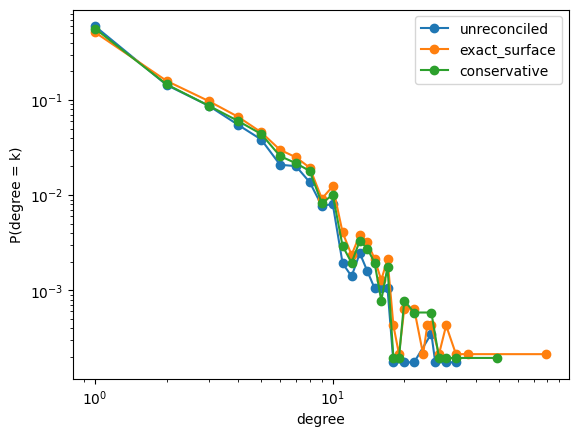

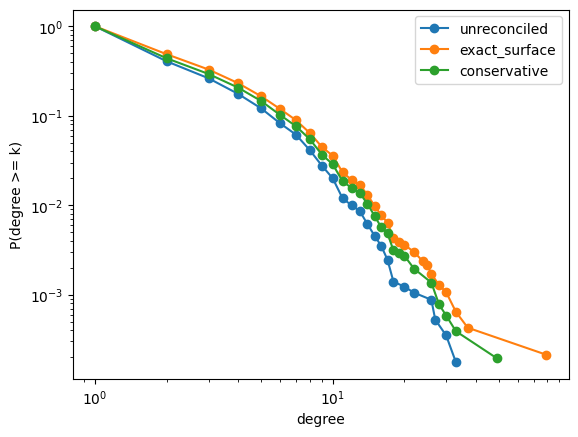

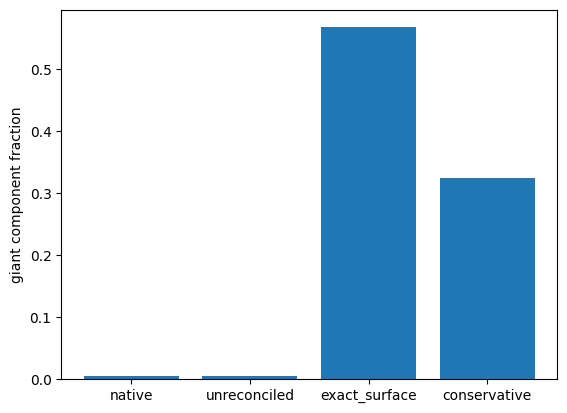

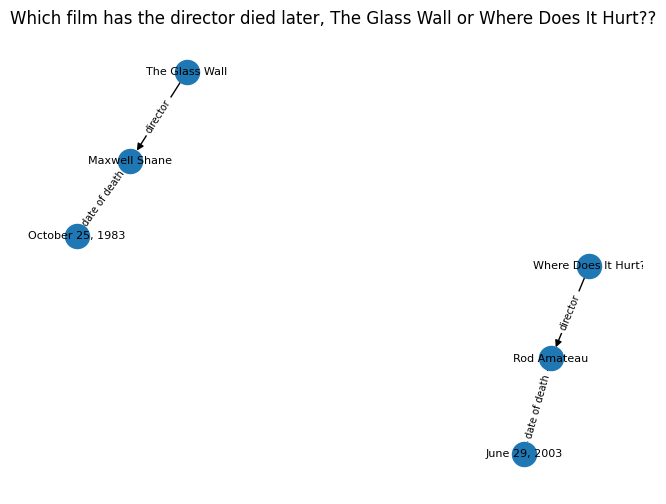

,graph,components,giant_component_fraction,isolated_nodes,degree_mean,degree_max,top5_weighted_degree
0,unreconciled,2638,0.004116,1308,2.162470,33,"[LeBron James, Dwyane Wade, Build-A-Bear Works..."
1,exact_surface,1425,0.490202,835,2.606888,71,"[United States, Australia, American, France, B..."
2,conservative,2223,0.059588,1185,2.275418,35,"[United States, Ben Affleck, American, LeBron ..."


In [ ]:
# === Q3: Network Analysis And Plots ===
def network_statistics(graph):
    # TODO Q3: components, giant component, isolates, component-size
    # summary, degree summary, clustering, and assortativity.
    import statistics

    if graph.is_directed():
        components = list(nx.weakly_connected_components(graph))
    else:
        components = list(nx.connected_components(graph))

    sizes = sorted(len(component) for component in components)
    n_nodes = graph.number_of_nodes()
    giant_size = sizes[-1] if sizes else 0
    simple = nx.Graph(graph)
    degrees = [degree for _, degree in simple.degree()]

    return {
        'nodes': n_nodes,
        'edges': graph.number_of_edges(),
        'components': len(components),
        'giant_component_size': giant_size,
        'giant_component_fraction': giant_size / n_nodes if n_nodes else 0.0,
        'isolated_nodes': sum(1 for size in sizes if size == 1),
        'component_size_min': sizes[0] if sizes else 0,
        'component_size_median': statistics.median(sizes) if sizes else 0,
        'component_size_mean': statistics.fmean(sizes) if sizes else 0.0,
        'component_size_max': giant_size,
        'degree_min': min(degrees) if degrees else 0,
        'degree_mean': statistics.fmean(degrees) if degrees else 0.0,
        'degree_median': statistics.median(degrees) if degrees else 0,
        'degree_max': max(degrees) if degrees else 0,
        'average_clustering': nx.average_clustering(simple) if simple.number_of_nodes() else 0.0,
        'degree_assortativity': (
            nx.degree_assortativity_coefficient(simple)
            if simple.number_of_edges() else float('nan')
        ),
    }

def centrality_audit(graph, top_n=10, seed=232):
    # TODO Q3: weighted degree, PageRank, and exact or fixed-seed
    # approximate betweenness, followed by semantic hub labels.
    simple = nx.Graph(graph)
    weighted_degree = dict(simple.degree(weight='weight'))
    pagerank = nx.pagerank(simple, weight='weight')
    if simple.number_of_nodes() > 500:
        betweenness = nx.betweenness_centrality(
            simple, k=min(200, simple.number_of_nodes()), weight='weight', seed=seed)
        betweenness_exact = False
    else:
        betweenness = nx.betweenness_centrality(simple, weight='weight')
        betweenness_exact = True

    def top(mapping):
        ranked = sorted(mapping.items(), key=lambda item: item[1], reverse=True)[:top_n]
        return [
            {
                'node': node,
                'score': score,
                'name': simple.nodes[node].get('name', node),
                'node_type': simple.nodes[node].get('node_type'),
            }
            for node, score in ranked
        ]

    return {
        'betweenness_exact': betweenness_exact,
        'weighted_degree': top(weighted_degree),
        'pagerank': top(pagerank),
        'betweenness': top(betweenness),
    }

# TODO Q3:
# - create the required 2Wiki PMF/CCDF plots on log-log axes;
# - build the sensitivity and MuSiQue transfer tables;
# - visualize one complete multi-hop evidence path;
# - save figures under WORK_ROOT / 'figures'.
from collections import Counter

figures_dir = WORK_ROOT / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

def degree_pmf_ccdf(degrees):
    positive = [degree for degree in degrees if degree > 0]
    counts = Counter(positive)
    total = sum(counts.values())
    ks = sorted(counts)
    pmf = [counts[k] / total for k in ks]
    ccdf = [sum(c for kk, c in counts.items() if kk >= k) / total for k in ks]
    return ks, pmf, ccdf

stats_2wiki = {
    name: network_statistics(graph_sets['2wiki'][name])
    for name in ['native', 'unreconciled', 'exact_surface', 'conservative']
}
connectivity_table = pd.DataFrame([{'graph': name, **stats} for name, stats in stats_2wiki.items()])
display(connectivity_table)

degree_table = pd.DataFrame([
    {
        'graph': name,
        'degree_mean': stats['degree_mean'],
        'degree_max': stats['degree_max'],
        'average_clustering': stats['average_clustering'],
        'degree_assortativity': stats['degree_assortativity'],
    }
    for name, stats in stats_2wiki.items() if name != 'native'
])
display(degree_table)

centrality_tables = {}
for name in ['unreconciled', 'exact_surface', 'conservative']:
    audit = centrality_audit(graph_sets['2wiki'][name])
    centrality_tables[name] = pd.DataFrame({
        'weighted_degree': [row['name'] for row in audit['weighted_degree']],
        'pagerank': [row['name'] for row in audit['pagerank']],
        'betweenness': [row['name'] for row in audit['betweenness']],
    })
    display(centrality_tables[name])

fig, ax = plt.subplots()
for name in ['unreconciled', 'exact_surface', 'conservative']:
    degrees = [degree for _, degree in graph_sets['2wiki'][name].degree()]
    ks, pmf, _ = degree_pmf_ccdf(degrees)
    ax.plot(ks, pmf, marker='o', label=name)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('degree')
ax.set_ylabel('P(degree = k)')
ax.legend()
fig.savefig(figures_dir / '2wiki_degree_pmf.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots()
for name in ['unreconciled', 'exact_surface', 'conservative']:
    degrees = [degree for _, degree in graph_sets['2wiki'][name].degree()]
    ks, _, ccdf = degree_pmf_ccdf(degrees)
    ax.plot(ks, ccdf, marker='o', label=name)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('degree')
ax.set_ylabel('P(degree >= k)')
ax.legend()
fig.savefig(figures_dir / '2wiki_degree_ccdf.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots()
ax.bar(list(stats_2wiki.keys()), [stats['giant_component_fraction'] for stats in stats_2wiki.values()])
ax.set_ylabel('giant component fraction')
fig.savefig(figures_dir / '2wiki_giant_component_fraction.png', bbox_inches='tight')
plt.show()

gold_question = next(
    (
        row for row in packages['2wiki'].questions('public')
        if row.get('type') == 'bridge_comparison' and row.get('evidences')
    ),
    None,
)
if gold_question is None:
    print('No bridge_comparison question with evidences found for path plot.')
else:
    gold_path_graph = nx.DiGraph()
    for evidence in gold_question['evidences']:
        if not isinstance(evidence, (list, tuple)) or len(evidence) < 3:
            continue
        subject, relation, obj = evidence[:3]
        gold_path_graph.add_node(subject, node_type='entity')
        gold_path_graph.add_node(obj, node_type='entity')
        gold_path_graph.add_edge(subject, obj, label=relation)

    if gold_path_graph.number_of_nodes():
        pos = nx.spring_layout(gold_path_graph, seed=232)
        fig, ax = plt.subplots(figsize=(8, 6))
        nx.draw_networkx_nodes(gold_path_graph, pos, ax=ax)
        nx.draw_networkx_labels(gold_path_graph, pos, ax=ax, font_size=8)
        nx.draw_networkx_edges(gold_path_graph, pos, ax=ax)
        nx.draw_networkx_edge_labels(
            gold_path_graph, pos,
            edge_labels=nx.get_edge_attributes(gold_path_graph, 'label'), ax=ax, font_size=7,
        )
        ax.set_title(gold_question['question'])
        ax.axis('off')
        fig.savefig(figures_dir / '2wiki_gold_path.png', bbox_inches='tight')
        plt.show()
    else:
        print('Gold evidence was present but did not contain drawable triples.')

stats_musique = {
    name: network_statistics(graph_sets['musique'][name])
    for name in ['unreconciled', 'exact_surface', 'conservative']
}
musique_transfer_table = pd.DataFrame([
    {
        'graph': name,
        'components': stats['components'],
        'giant_component_fraction': stats['giant_component_fraction'],
        'isolated_nodes': stats['isolated_nodes'],
        'degree_mean': stats['degree_mean'],
        'degree_max': stats['degree_max'],
        'top5_weighted_degree': [
            row['name'] for row in centrality_audit(graph_sets['musique'][name], top_n=5)['weighted_degree']
        ],
    }
    for name, stats in stats_musique.items()
])
display(musique_transfer_table)

### Written Response For Question 3

### Cross-Dataset Interpretation (200-300 words)

The 2Wiki and MuSiQue results both show reconciliation can dominate the apparent network structure. In 2Wiki, the unreconciled projection is highly fragmented, with 1,984 components and a giant-component fraction of only 0.0056. Exact-surface reconciliation collapses many same-surface occurrences, reducing the component count to 1,012 and increasing the giant-component fraction to 0.568. The conservative rule is less aggressive but still changes the graph substantially, producing 1,389 components and a giant-component fraction of 0.324. MuSiQue transfers the same qualitative pattern but with a smaller conservative effect. Its unreconciled projection has 2,638 components and a giant-component fraction of 0.0041; exact-surface reconciliation again creates a large component, with giant-component fraction 0.490; but the conservative projection has a much smaller giant component, only 0.0596.

This suggests that both datasets are sensitive to identity assumptions, but the conservative rule is more restrictive on MuSiQue or has less compatible repeated local evidence to merge. The top weighted-degree nodes also show the same caution. Exact-surface reconciliation promotes broad names or attributes such as "United States", "American", or national labels, while unreconciled graphs keep document-local evidence separated. Therefore the conclusion transfers: reconciled projections are useful for analyzing sensitivity, but PANINI retrieval should not treat them as ground-truth memory. Retrieval should continue using local GSW evidence and provenance-preserving QA records.

### Hub Explanation (150-200 words)

A high-degree hub is not automatically meaningful. A hub can reflect repeated semantic participation when a specific entity appears in many grounded QA relations across local GSWs. For example, a named person or work such as David Ryan Adams, Michael Curtiz, or Walter George Mitchell can be a plausible hub if its neighbors come from concrete question-answer evidence and the provenance documents support the same entity interpretation. In that case, high degree reflects real repeated participation in the structured memory.

A manufactured hub is different. Nodes such as "American", "actor", "film director", "screenwriter", "French", or "United States" may become central because reconciliation merges many surface-identical occurrences across unrelated documents. These nodes can represent common attributes, nationalities, occupations, or ambiguous labels rather than one specific entity. The evidence I used to distinguish these cases is node type, role/state fields, provenance documents, and neighboring QA labels, not degree alone. If the hub’s edges come from many unrelated documents and the node label is a broad descriptor, I treat it as a reconciliation artifact. This is why the reconciled projection must not be used directly by the PANINI retrieval pipeline: it can create paths that no local GSW actually asserted.


## Stage A — Question 4: decomposition and dependency graphs (14 points)

This is the first neural stage. It loads only the 4B decomposer,
writes the raw response before parsing, and unloads the model when
finished. Implement validation before starting the 200-question
run. Invalid JSON, forward references, missing nodes, and cycles
must remain visible in the cache rather than being silently fixed.

In [ ]:
# === Q4A: Parser And Dependency Validation ===
import re
PLACEHOLDER = re.compile(r'<ENTITY_Q(\d+)>')

def validate_decomposition(plan):
    # TODO Q4: return {'valid': bool, 'errors': [...], 'edges': [...]}.
    # Check schema, nonempty question text, reference bounds,
    # topological direction, and cycles.
    errors = []
    edges = []
    if not isinstance(plan, list) or not plan:
        return {'valid': False, 'errors': ['plan must be a nonempty list'], 'edges': []}

    for index, row in enumerate(plan, start=1):
        if not isinstance(row, dict) or 'question' not in row:
            errors.append(f'Q{index}: missing question field')
            continue
        question = row.get('question')
        if not isinstance(question, str) or not question.strip():
            errors.append(f'Q{index}: empty question text')
        requires_retrieval = row.get('requires_retrieval', True)
        if not isinstance(requires_retrieval, bool):
            errors.append(f'Q{index}: requires_retrieval must be boolean')
        for match in PLACEHOLDER.findall(str(question)):
            ref = int(match)
            if ref < 1 or ref >= index:
                errors.append(f'Q{index}: reference to Q{ref} is out of bounds or not earlier')
            else:
                edges.append((ref, index))

    return {'valid': len(errors) == 0, 'errors': errors, 'edges': edges}

def decomposition_metrics(predicted, reviewed):
    # TODO Q4: validity, subquestion-count exact match, dependency
    # edge precision/recall/F1, and retrieval/reasoning flag accuracy.
    predicted_validation = validate_decomposition(predicted)
    reviewed_validation = validate_decomposition(reviewed)

    predicted_edges = set(predicted_validation['edges'])
    reviewed_edges = set(reviewed_validation['edges'])
    true_positives = len(predicted_edges & reviewed_edges)
    precision = true_positives / len(predicted_edges) if predicted_edges else (1.0 if not reviewed_edges else 0.0)
    recall = true_positives / len(reviewed_edges) if reviewed_edges else (1.0 if not predicted_edges else 0.0)
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    predicted_flags = [bool(row.get('requires_retrieval', True)) for row in predicted]
    reviewed_flags = [bool(row.get('requires_retrieval', True)) for row in reviewed]
    matched = min(len(predicted_flags), len(reviewed_flags))
    flag_matches = sum(predicted_flags[i] == reviewed_flags[i] for i in range(matched))
    flag_accuracy = flag_matches / len(reviewed_flags) if reviewed_flags else 1.0

    return {
        'predicted_valid': predicted_validation['valid'],
        'predicted_count': len(predicted),
        'reviewed_count': len(reviewed),
        'count_match': len(predicted) == len(reviewed),
        'edge_precision': precision,
        'edge_recall': recall,
        'edge_f1': f1,
        'retrieval_flag_accuracy': flag_accuracy,
    }

In [ ]:
RUN_DECOMPOSITION_STAGE = True
RUN_RERANK_AND_RICR_STAGE = False
RUN_ANSWER_STAGE = False
RUN_ABLATIONS = False

QUESTION_LIMIT = None
MOUNT_DRIVE_IN_COLAB = True
REQUIRE_DURABLE_WORK_ROOT = True

In [ ]:
# === Q4B / STAGE A: GPU Decomposition Run ===
# Stage A: restartable decomposition. Run only after the validator works.
# This cell is deliberately verbose because model generation can otherwise
# look stuck while it is loading weights or generating a single answer.
if RUN_DECOMPOSITION_STAGE:
    from panini_course.qwen_models import QwenDecomposer

    model_cfg_path = PACKAGE_ROOTS['2wiki'] / 'models/model_config.json'
    model_cfg = json.loads(model_cfg_path.read_text())
    print({
        'stage': 'Q4B',
        'question_limit': QUESTION_LIMIT,
        'datasets': DATASETS,
        'work_root': str(WORK_ROOT),
        'model_config': str(model_cfg_path),
        'model': model_cfg['decomposer']['model'],
    }, flush=True)

    print('Q4B: loading decomposer model...', flush=True)
    load_started = time.perf_counter()
    decomposer = QwenDecomposer(
        model_cfg['decomposer']['model'],
        PACKAGE_ROOTS['2wiki'] / model_cfg['decomposer']['prompt'],
        quantized=True,
    )
    print(f'Q4B: decomposer loaded in {time.perf_counter() - load_started:.1f}s', flush=True)

    try:
        for dataset in DATASETS:
            package = packages[dataset]
            output = WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl'
            done = completed_ids(output)
            questions = selected_questions(package)
            print(
                f'Q4B: dataset={dataset} selected={len(questions)} already_done={len(done)} output={output}',
                flush=True,
            )
            for index, question in enumerate(questions, start=1):
                qid = str(question['question_id'])
                if qid in done:
                    print(f'Q4B: skip dataset={dataset} {index}/{len(questions)} qid={qid}', flush=True)
                    continue

                print(
                    f'Q4B: generate start dataset={dataset} {index}/{len(questions)} qid={qid}: '
                    f'{question["question"][:160]}',
                    flush=True,
                )
                started = time.perf_counter()
                record = {
                    'dataset': dataset,
                    'question_id': qid,
                    'question': question['question'],
                    'raw_response': None,
                    'predicted_decomposition': None,
                    'decomposition_valid': False,
                    'validation_errors': [],
                    'seconds': None,
                }
                try:
                    raw = decomposer.generate_raw(question['question'])
                    record['raw_response'] = raw
                    print(
                        f'Q4B: generate done dataset={dataset} qid={qid} '
                        f'chars={len(raw) if raw is not None else 0} '
                        f'seconds={time.perf_counter() - started:.1f}',
                        flush=True,
                    )
                    try:
                        plan = decomposer.parse_response(raw)
                        validation = validate_decomposition(plan)
                        record.update({
                            'predicted_decomposition': plan,
                            'decomposition_valid': validation['valid'],
                            'validation_errors': validation['errors'],
                            'dependency_edges': validation['edges'],
                        })
                    except Exception as error:
                        record['validation_errors'] = [repr(error)]
                except KeyboardInterrupt:
                    print(f'Q4B: interrupted during dataset={dataset} qid={qid}', flush=True)
                    raise
                except Exception as error:
                    record['validation_errors'] = [f'generate_raw failed: {error!r}']
                    print(f'Q4B: generation failed dataset={dataset} qid={qid}: {error!r}', flush=True)
                finally:
                    record['seconds'] = time.perf_counter() - started
                    append_jsonl(output, record)
                    done.add(qid)
                    print(
                        f'Q4B: wrote record dataset={dataset} qid={qid} '
                        f'valid={record["decomposition_valid"]} seconds={record["seconds"]:.1f}',
                        flush=True,
                    )
        print('Q4B: complete.', flush=True)
    finally:
        del decomposer
        release_gpu()
        print('Q4B: decomposer released and GPU cache cleared.', flush=True)
else:
    print('Stage A disabled. Set RUN_DECOMPOSITION_STAGE=True when ready.')


{'stage': 'Q4B', 'question_limit': None, 'datasets': ('2wiki', 'musique'), 'work_root': '/content/drive/MyDrive/panini-course-project-work', 'model_config': '/content/panini-course-project/models/model_config.json', 'model': 'yigitturali/GSW-QA-Decomposer-Qwen3-4B'}
Q4B: loading decomposer model...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Q4B: decomposer loaded in 71.0s
Q4B: dataset=2wiki selected=100 already_done=2 output=/content/drive/MyDrive/panini-course-project-work/cache/2wiki/decompositions.jsonl
Q4B: skip dataset=2wiki 1/100 qid=5cbb015f087511ebbd67ac1f6bf848b6
Q4B: skip dataset=2wiki 2/100 qid=2ea72c0c084d11ebbd56ac1f6bf848b6
Q4B: generate start dataset=2wiki 3/100 qid=53ab316c08b911ebbd88ac1f6bf848b6: Which film has the director who died later, The Fatal Mistake or The Devil'S Hairpin?
Q4B: generate done dataset=2wiki qid=53ab316c08b911ebbd88ac1f6bf848b6 chars=398 seconds=14.5
Q4B: wrote record dataset=2wiki qid=53ab316c08b911ebbd88ac1f6bf848b6 valid=True seconds=14.5
Q4B: generate start dataset=2wiki 4/100 qid=1cf6b11808a111ebbd78ac1f6bf848b6: Which film has the director born earlier, The Planet Of Junior Brown or A Yank In The R.A.F.?
Q4B: generate done dataset=2wiki qid=1cf6b11808a111ebbd78ac1f6bf848b6 chars=414 seconds=15.3
Q4B: wrote record dataset=2wiki qid=1cf6b11808a111ebbd78ac1f6bf848b6 valid=True se

In [ ]:
# === Q4C: Decomposition Metrics, DAG Audit, And Hand-Worked Plan ===
# CPU-only analysis. This reads the saved Q4B checkpoints and does not
# rewrite decompositions.jsonl, so later Q8/Q9 runs are unaffected.
from collections import Counter, defaultdict, deque
import math
import re
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 2000)

def q4_read_jsonl(path):
    if 'read_jsonl' in globals():
        return read_jsonl(path)
    return [json.loads(line) for line in Path(path).open(encoding='utf-8') if line.strip()]

def q4_reviewed_decomposition_map(dataset):
    path = PACKAGE_ROOTS[dataset] / 'questions' / 'decomposition_validation.jsonl'
    if not path.exists():
        return {}, None
    rows = q4_read_jsonl(path)
    return {
        str(row['question_id']): row['decomposed_questions']
        for row in rows
        if isinstance(row.get('decomposed_questions'), list)
    }, path

def q4_reference_plan(question):
    # Fallback for package releases that inline reviewed decompositions.
    for key in (
        'reviewed_decomposition', 'gold_decomposition', 'reference_decomposition',
        'decomposition', 'decomposition_plan', 'plan',
    ):
        plan = question.get(key)
        if isinstance(plan, list):
            return plan, key
    return None, None

def q4_edges(plan, record=None):
    if record and record.get('dependency_edges') is not None:
        return [tuple(edge) for edge in record.get('dependency_edges', [])]
    return validate_decomposition(plan)['edges']

def q4_topological_order(node_ids, edges):
    node_ids = list(node_ids)
    node_set = set(node_ids)
    children = defaultdict(list)
    indegree = {node: 0 for node in node_ids}
    for left, right in edges:
        if left in node_set and right in node_set:
            children[left].append(right)
            indegree[right] += 1
    queue = deque(sorted(node for node, degree in indegree.items() if degree == 0))
    order = []
    while queue:
        node = queue.popleft()
        order.append(node)
        for child in sorted(children[node]):
            indegree[child] -= 1
            if indegree[child] == 0:
                queue.append(child)
    return order

def q4_component_orders(plan, edges):
    retrieval_nodes = {
        index for index, row in enumerate(plan, start=1)
        if bool(row.get('requires_retrieval', True))
    }
    deterministic_nodes = sorted(
        index for index, row in enumerate(plan, start=1)
        if not bool(row.get('requires_retrieval', True))
    )
    adjacency = {node: set() for node in retrieval_nodes}
    for left, right in edges:
        if left in retrieval_nodes and right in retrieval_nodes:
            adjacency[left].add(right)
            adjacency[right].add(left)

    components = []
    unseen = set(retrieval_nodes)
    while unseen:
        start = min(unseen)
        stack = [start]
        component = set()
        while stack:
            node = stack.pop()
            if node in component:
                continue
            component.add(node)
            stack.extend(adjacency[node] - component)
        unseen -= component
        components.append(q4_topological_order(component, edges))
    return components, deterministic_nodes

def q4_expected_hops(dataset, question):
    if dataset == 'musique':
        match = re.search(r'(\d+)hop', str(question.get('question_id', '')))
        if match:
            return int(match.group(1))
    for key in ('hop_count', 'num_hops', 'hops'):
        value = question.get(key)
        if isinstance(value, int):
            return value
    return None

def q4_plan_summary(record, package, dataset):
    plan = record.get('predicted_decomposition') or []
    edges = q4_edges(plan, record)
    validation = validate_decomposition(plan)
    retrieval_nodes = [
        index for index, row in enumerate(plan, start=1)
        if bool(row.get('requires_retrieval', True))
    ]
    deterministic_nodes = [
        index for index, row in enumerate(plan, start=1)
        if not bool(row.get('requires_retrieval', True))
    ]
    indegree = Counter(child for _parent, child in edges)
    components, component_orders = q4_component_orders(plan, edges)
    question = {str(row['question_id']): row for row in package.questions('public')}.get(
        str(record.get('question_id')), {}
    )
    return {
        'dataset': dataset,
        'question_id': record.get('question_id'),
        'valid': bool(record.get('decomposition_valid')) and validation['valid'],
        'subquestions': len(plan),
        'retrieval_nodes': len(retrieval_nodes),
        'deterministic_nodes': len(deterministic_nodes),
        'dependency_edges': len(edges),
        'retrieval_components': len(components),
        'component_orders': components,
        'deterministic_node_ids': deterministic_nodes,
        'converging_nodes': sorted(node for node, degree in indegree.items() if degree >= 2),
        'expected_hops': q4_expected_hops(dataset, question),
        'seconds': record.get('seconds'),
    }

parser_smoke_tests = [
    {
        'name': 'valid converging DAG',
        'expected_valid': True,
        'plan': [
            {'question': 'Who directed Film A?', 'requires_retrieval': True},
            {'question': 'Who directed Film B?', 'requires_retrieval': True},
            {'question': 'Who was born later, <ENTITY_Q1> or <ENTITY_Q2>?', 'requires_retrieval': False},
        ],
    },
    {
        'name': 'reject forward reference',
        'expected_valid': False,
        'plan': [{'question': 'Who is <ENTITY_Q2>?', 'requires_retrieval': True}],
    },
    {
        'name': 'reject empty retrieval text',
        'expected_valid': False,
        'plan': [{'question': '   ', 'requires_retrieval': True}],
    },
    {
        'name': 'reject invalid retrieval flag',
        'expected_valid': False,
        'plan': [{'question': 'Who directed Film A?', 'requires_retrieval': 'yes'}],
    },
]
parser_test_rows = []
for test in parser_smoke_tests:
    result = validate_decomposition(test['plan'])
    parser_test_rows.append({
        'test': test['name'],
        'expected_valid': test['expected_valid'],
        'observed_valid': result['valid'],
        'passed': result['valid'] == test['expected_valid'],
        'errors': result['errors'],
        'edges': result['edges'],
    })
parser_test_table = pd.DataFrame(parser_test_rows)
display(parser_test_table)
assert parser_test_table['passed'].all()

q4_records = {}
q4_summary_rows = []
q4_component_rows = []
q4_metric_detail_rows = []
for dataset in DATASETS:
    package = packages[dataset]
    path = WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl'
    rows = q4_read_jsonl(path)
    q4_records[dataset] = rows
    assert len(rows) == len(selected_questions(package)), (
        f'{dataset}: expected {len(selected_questions(package))} decomposition rows, found {len(rows)}'
    )
    question_by_id = {str(row['question_id']): row for row in package.questions('public')}
    reviewed_by_id, reviewed_path = q4_reviewed_decomposition_map(dataset)
    summaries = [q4_plan_summary(row, package, dataset) for row in rows]
    q4_component_rows.extend(summaries)

    q4_summary_rows.append({
        'dataset': dataset,
        'rows': len(rows),
        'valid_plan_rate': sum(row.get('decomposition_valid') for row in rows) / len(rows),
        'raw_response_rate': sum(bool(row.get('raw_response')) for row in rows) / len(rows),
        'mean_subquestions': sum(item['subquestions'] for item in summaries) / len(summaries),
        'mean_dependency_edges': sum(item['dependency_edges'] for item in summaries) / len(summaries),
        'mean_retrieval_nodes': sum(item['retrieval_nodes'] for item in summaries) / len(summaries),
        'mean_deterministic_nodes': sum(item['deterministic_nodes'] for item in summaries) / len(summaries),
        'multi_parent_plans': sum(bool(item['converging_nodes']) for item in summaries),
        'mean_seconds': sum(row.get('seconds') or 0 for row in rows) / len(rows),
    })

    for row in rows:
        qid = str(row.get('question_id'))
        reference = reviewed_by_id.get(qid)
        reference_key = (
            f'{reviewed_path.name}:decomposed_questions'
            if reference is not None and reviewed_path is not None
            else None
        )
        if reference is None:
            question = question_by_id.get(qid, {})
            reference, reference_key = q4_reference_plan(question)
        if reference is None:
            continue
        metrics = decomposition_metrics(row.get('predicted_decomposition') or [], reference)
        q4_metric_detail_rows.append({
            'dataset': dataset,
            'question_id': row.get('question_id'),
            'reference_key': reference_key,
            **metrics,
        })

q4_summary_table = pd.DataFrame(q4_summary_rows)
display(q4_summary_table)

q4_count_distribution = pd.DataFrame([
    {'dataset': dataset, 'subquestions': count, 'questions': total}
    for dataset, rows in q4_records.items()
    for count, total in sorted(Counter(len(row.get('predicted_decomposition') or []) for row in rows).items())
])
display(q4_count_distribution)

q4_component_table = pd.DataFrame(q4_component_rows)
display(q4_component_table[[
    'dataset', 'question_id', 'subquestions', 'retrieval_nodes',
    'deterministic_nodes', 'dependency_edges', 'retrieval_components',
    'converging_nodes', 'expected_hops'
]].head(12))

q4_metric_detail_table = pd.DataFrame(q4_metric_detail_rows)
if q4_metric_detail_table.empty:
    q4_metric_table = pd.DataFrame([{
        'reviewed_examples_found': 0,
        'note': 'No reviewed decomposition source was found.',
    }])
else:
    q4_metric_table = q4_metric_detail_table.groupby('dataset').agg(
        reviewed_examples=('question_id', 'count'),
        valid_plan_rate=('predicted_valid', 'mean'),
        subquestion_count_exact_match=('count_match', 'mean'),
        dependency_edge_precision=('edge_precision', 'mean'),
        dependency_edge_recall=('edge_recall', 'mean'),
        dependency_edge_f1=('edge_f1', 'mean'),
        retrieval_vs_reasoning_accuracy=('retrieval_flag_accuracy', 'mean'),
    ).reset_index()
display(q4_metric_table)

def q4_error_or_concern(row, summary):
    plan = row.get('predicted_decomposition') or []
    question = row.get('question', '')
    expected = summary.get('expected_hops')
    if expected and summary['retrieval_nodes'] < expected:
        return 'missing hop risk', (
            f'Expected about {expected} retrieval hops from metadata/id, but the plan has '
            f'{summary["retrieval_nodes"]} retrieval nodes.'
        )
    if expected and summary['retrieval_nodes'] > expected + 1:
        return 'extra hop risk', (
            f'Expected about {expected} retrieval hops, but the plan has '
            f'{summary["retrieval_nodes"]} retrieval nodes.'
        )
    if summary['converging_nodes']:
        child = summary['converging_nodes'][0]
        child_row = plan[child - 1]
        if bool(child_row.get('requires_retrieval', True)):
            return 'reasoning marked as retrieval', (
                f'Q{child} has multiple parents but is still marked as retrieval; for comparisons, '
                'this can blur final deterministic reasoning with retrieval.'
            )
    if summary['subquestions'] == 1 and any(word in question.casefold() for word in (' or ', ' both ', ' which ')):
        return 'semantically broad atomic question', (
            'The original question appears multi-hop or comparative, but the decomposition leaves it as one retrieval node.'
        )
    if summary['dependency_edges'] == 0 and summary['retrieval_nodes'] > 1:
        return 'wrong dependency risk', (
            'Multiple retrieval nodes are present but no dependency edge connects them, so later substitution cannot occur.'
        )
    return 'manual semantic review', (
        'The plan is syntactically valid, but should be reviewed for atomicity and whether the final operation is reasoning.'
    )

q4_error_rows = []
for dataset, rows in q4_records.items():
    summaries_by_id = {item['question_id']: item for item in q4_component_rows if item['dataset'] == dataset}
    seen_types = set()
    for row in rows:
        summary = summaries_by_id[row.get('question_id')]
        concern_type, analysis = q4_error_or_concern(row, summary)
        if concern_type in seen_types and len(seen_types) < 2:
            continue
        q4_error_rows.append({
            'dataset': dataset,
            'question_id': row.get('question_id'),
            'question': row.get('question'),
            'concern_type': concern_type,
            'analysis': analysis,
        })
        seen_types.add(concern_type)
        if sum(item['dataset'] == dataset for item in q4_error_rows) == 2:
            break
q4_error_audit = pd.DataFrame(q4_error_rows)
display(q4_error_audit)

hand_record = None
hand_summary = None
for dataset, rows in q4_records.items():
    summaries_by_id = {item['question_id']: item for item in q4_component_rows if item['dataset'] == dataset}
    for row in rows:
        summary = summaries_by_id[row.get('question_id')]
        if summary['converging_nodes']:
            hand_record = row
            hand_summary = summary
            break
    if hand_record is not None:
        break

if hand_record is None:
    print('No converging multi-branch decomposition found.')
else:
    plan = hand_record['predicted_decomposition']
    edges = q4_edges(plan, hand_record)
    parent_map = defaultdict(list)
    for parent, child in edges:
        parent_map[child].append(parent)
    hand_plan_rows = []
    for index, step in enumerate(plan, start=1):
        hand_plan_rows.append({
            'node': f'Q{index}',
            'kind': 'retrieval' if bool(step.get('requires_retrieval', True)) else 'reasoning',
            'parents': ', '.join(f'Q{parent}' for parent in sorted(parent_map[index])) or '-',
            'question_template': step.get('question'),
        })
    q4_hand_plan = pd.DataFrame(hand_plan_rows)
    print('Hand-worked decomposition question_id:', hand_record['question_id'])
    print('Original question:', hand_record['question'])
    print('Dependency edges:', ', '.join(f'Q{a}->Q{b}' for a, b in edges))
    print('Retrieval component topological orders:', hand_summary['component_orders'])
    print('Deterministic nodes:', hand_summary['deterministic_node_ids'])
    display(q4_hand_plan)


,test,expected_valid,observed_valid,passed,errors,edges
0,valid converging DAG,True,True,True,[],"[(1, 3), (2, 3)]"
1,reject forward reference,False,False,True,[Q1: reference to Q2 is out of bounds or not earlier],[]
2,reject empty retrieval text,False,False,True,[Q1: empty question text],[]
3,reject invalid retrieval flag,False,False,True,[Q1: requires_retrieval must be boolean],[]


,dataset,rows,valid_plan_rate,raw_response_rate,mean_subquestions,mean_dependency_edges,mean_retrieval_nodes,mean_deterministic_nodes,multi_parent_plans,mean_seconds
0,2wiki,100,1.0,1.0,2.37,1.41,2.33,0.04,49,12.643984
1,musique,100,1.0,1.0,2.63,1.61,2.63,0.00,1,13.566059


,dataset,subquestions,questions
0,2wiki,1,16
1,2wiki,2,35
2,2wiki,3,45
3,2wiki,4,4
4,musique,1,2
5,musique,2,51
6,musique,3,32
7,musique,4,13
8,musique,5,1
9,musique,6,1


,dataset,question_id,subquestions,retrieval_nodes,deterministic_nodes,dependency_edges,retrieval_components,converging_nodes,expected_hops
0,2wiki,5cbb015f087511ebbd67ac1f6bf848b6,3,3,0,2,1,[3],NaN
1,2wiki,2ea72c0c084d11ebbd56ac1f6bf848b6,3,3,0,2,1,[3],NaN
2,2wiki,53ab316c08b911ebbd88ac1f6bf848b6,3,3,0,2,1,[3],NaN
3,2wiki,1cf6b11808a111ebbd78ac1f6bf848b6,3,3,0,2,1,[3],NaN
4,2wiki,19e6c50608d711ebbd99ac1f6bf848b6,3,3,0,2,1,[3],NaN
5,2wiki,f5712c9c08a811ebbd7fac1f6bf848b6,3,3,0,2,1,[3],NaN
6,2wiki,5b43e68c086211ebbd5dac1f6bf848b6,3,3,0,2,1,[3],NaN
7,2wiki,f1145dc6084f11ebbd56ac1f6bf848b6,3,3,0,2,1,[3],NaN
8,2wiki,fec1cc4a087911ebbd67ac1f6bf848b6,3,3,0,2,1,[3],NaN
9,2wiki,3cc3895c08cf11ebbd94ac1f6bf848b6,3,3,0,2,1,[3],NaN


,dataset,reviewed_examples,valid_plan_rate,subquestion_count_exact_match,dependency_edge_precision,dependency_edge_recall,dependency_edge_f1,retrieval_vs_reasoning_accuracy
0,2wiki,20,1.0,0.6,0.650000,0.600000,0.616667,0.729167
1,musique,80,1.0,0.8,0.928958,0.902083,0.906548,0.954167


,dataset,question_id,question,concern_type,analysis
0,2wiki,5cbb015f087511ebbd67ac1f6bf848b6,"Which film has the director died later, The Glass Wall or Where Does It Hurt??",reasoning marked as retrieval,"Q3 has multiple parents but is still marked as retrieval; for comparisons, this can blur final deterministic reasoning with retrieval."
1,2wiki,4a3e57f708c511ebbd8eac1f6bf848b6,"Who was born first, Jeanne Mandello or Alexander Herrmann?",semantically broad atomic question,"The original question appears multi-hop or comparative, but the decomposition leaves it as one retrieval node."
2,musique,2hop__494659_5385,How many people work at the school that holds the Julian P. Kanter Political Commercial Archive?,manual semantic review,"The plan is syntactically valid, but should be reviewed for atomicity and whether the final operation is reasoning."
3,musique,2hop__463884_807572,What county is the Ira C. Allen Mansion located in?,missing hop risk,"Expected about 2 retrieval hops from metadata/id, but the plan has 1 retrieval nodes."


Hand-worked decomposition question_id: 5cbb015f087511ebbd67ac1f6bf848b6
Original question: Which film has the director died later, The Glass Wall or Where Does It Hurt??
Dependency edges: Q1->Q3, Q2->Q3
Retrieval component topological orders: [[1, 2, 3]]
Deterministic nodes: []


,node,kind,parents,question_template
0,Q1,retrieval,-,Who directed The Glass Wall?
1,Q2,retrieval,-,Who directed Where Does It Hurt??
2,Q3,retrieval,"Q1, Q2","Who died later, <ENTITY_Q1> or <ENTITY_Q2>?"


### Written Response For Question 4

Q4B produced durable decomposition checkpoints for all 200 questions: 100 2Wiki rows and 100 MuSiQue rows in `cache/<dataset>/decompositions.jsonl`. Each row stores the raw model response before parsing, the parsed decomposition, validation status, dependency edges, and generation time. This is important because parser or validation failures remain inspectable without rerunning the Qwen decomposer. Q4C confirmed that both datasets had valid-plan rate 1.0 and raw-response coverage 1.0. The parser tests also behaved as expected: the validator accepted a valid converging DAG and rejected forward references, empty retrieval questions, and invalid retrieval flags.

The reviewed-subset metrics show that the decompositions are syntactically valid but not always semantically faithful to the reviewed plans. For 2Wiki, the reviewed subset contains 20 examples, with sub-question-count exact match 0.60, dependency-edge F1 0.617, and retrieval/reasoning-label accuracy 0.729. MuSiQue is stronger on the same audit: 80 reviewed examples, sub-question-count exact match 0.80, dependency-edge F1 0.907, and retrieval/reasoning-label accuracy 0.954. This suggests that most model outputs are executable, but 2Wiki comparison questions are more likely to compress intermediate hops or misclassify reasoning as retrieval.

The four error audits illustrate different failure modes. In the first 2Wiki example, the model creates a converging node but marks the final comparison as retrieval, even though comparing two already retrieved entities is a deterministic reasoning step. A second 2Wiki example uses an overly broad atomic question, which may retrieve plausible but underspecified evidence. In the MuSiQue examples, one plan is syntactically valid but still needs semantic review because validity alone does not prove the sub-question asks the intended fact. Another MuSiQue case has a missing-hop risk, where the expected hop structure suggests that an intermediate entity or relation may have been skipped.

Hand-worked dependency graph for the reviewed 2Wiki example:

```text
Original question:
Which film has the director who died later, The Glass Wall or Where Does It Hurt?

Q1: Who directed The Glass Wall?                         [retrieval]
Q2: Who directed Where Does It Hurt?                     [retrieval]
Q3: When did <ENTITY_Q1> die?                            [retrieval]
Q4: When did <ENTITY_Q2> die?                            [retrieval]
Q5: Which date is later, <ENTITY_Q3> or <ENTITY_Q4>?     [reasoning]
Q6: Which film has the director who died later?          [reasoning]

Dependency graph:

Q1 -> Q3 -> Q5 -> Q6
Q2 -> Q4 -> Q5 -> Q6

## Question 5 — sparse retrieval baselines (12 points)

Evaluate TF–IDF and BM25 for both direct QA retrieval and entity
retrieval followed by local GSW expansion. Use stable QA IDs for
relevance; do not evaluate by comparing array positions.

In [ ]:
# === Q5: Sparse Retrieval Baselines ===
from panini_course import BM25Index, TfidfIndex
from panini_course.metrics import recall_at_k, reciprocal_rank

def load_sparse_artifacts(root):
    return {
        'qa_tfidf': TfidfIndex.load(
            root/'indices/qa_tfidf.npz',
            root/'indices/qa_tfidf_vectorizer.joblib',
            root/'indices/qa_ids.json', source='qa_tfidf'),
        'qa_bm25': BM25Index.load(
            root/'indices/qa_bm25.joblib',
            root/'indices/qa_ids.json', source='qa_bm25'),
        'entity_tfidf': TfidfIndex.load(
            root/'indices/entity_tfidf.npz',
            root/'indices/entity_tfidf_vectorizer.joblib',
            root/'indices/entity_ids.json', source='entity_tfidf'),
        'entity_bm25': BM25Index.load(
            root/'indices/entity_bm25.joblib',
            root/'indices/entity_ids.json', source='entity_bm25'),
    }

sparse = {name: load_sparse_artifacts(root) for name, root in PACKAGE_ROOTS.items()}

def evaluate_sparse_retrieval(dataset, package, artifacts, k_values=(1, 5, 10, 15)):
    # TODO Q5: evaluate atomic gold retrieval tasks overall and by
    # question type/hop count. Include latency and failure examples.
    import time
    from panini_course.retrieval import SearchHit

    public_questions = package.questions('public')
    doc_labels = {}
    for row in public_questions:
        label = row.get('type') or row.get('hop_count')
        for doc_id in row.get('context_document_ids', []):
            doc_labels.setdefault(doc_id, set()).add(label)

    qa_pairs = package.qa_pairs()
    tasks = [
        {
            'query': row['question'],
            'gold': row['qa_uid'],
            'labels': sorted(doc_labels.get(row['document_id'], set())),
        }
        for row in qa_pairs
        if row['document_id'] in doc_labels
    ]

    qa_by_answer_local_id = {}
    qa_by_document_gsw = {}
    for row in qa_pairs:
        qa_by_document_gsw.setdefault((row['document_id'], row['gsw_file']), []).append(row)
        for local_id in row.get('answer_local_ids', []):
            qa_by_answer_local_id.setdefault(
                (row['document_id'], row['gsw_file'], local_id), []).append(row)

    def entity_expand(entity_hits, top_k):
        scored = {}
        for hit in entity_hits:
            parts = hit.item_id.split('::')
            if len(parts) != 3:
                continue
            document_id, gsw_file, local_id = parts
            for qa_row in qa_by_answer_local_id.get((document_id, gsw_file, local_id), []):
                scored[qa_row['qa_uid']] = max(scored.get(qa_row['qa_uid'], float('-inf')), hit.score)
            for qa_row in qa_by_document_gsw.get((document_id, gsw_file), []):
                scored.setdefault(qa_row['qa_uid'], hit.score * 0.5)
        ranked = sorted(scored.items(), key=lambda item: item[1], reverse=True)[:top_k]
        return [
            SearchHit(item_id=qa_uid, score=score, source='entity_bm25_expansion', rank=rank)
            for rank, (qa_uid, score) in enumerate(ranked, start=1)
        ]

    def run_method(search_fn):
        max_k = max(k_values)
        rows = []
        for task in tasks:
            started = time.perf_counter()
            hits = search_fn(task['query'], max_k)
            elapsed = time.perf_counter() - started
            ranked_ids = [hit.item_id for hit in hits]
            rank = ranked_ids.index(task['gold']) + 1 if task['gold'] in ranked_ids else None
            rows.append({
                'query': task['query'], 'gold': task['gold'],
                'labels': task['labels'], 'rank': rank, 'seconds': elapsed,
            })

        def summarize(subset):
            count = len(subset)
            if count == 0:
                summary = {f'recall@{k}': 0.0 for k in k_values}
                summary.update({'mrr': 0.0, 'mean_latency_seconds': 0.0, 'count': 0})
                return summary
            summary = {
                f'recall@{k}': sum(1 for row in subset if row['rank'] and row['rank'] <= k) / count
                for k in k_values
            }
            summary['mrr'] = sum(1.0 / row['rank'] if row['rank'] else 0.0 for row in subset) / count
            summary['mean_latency_seconds'] = sum(row['seconds'] for row in subset) / count
            summary['count'] = count
            return summary

        by_label = {}
        for label in sorted({label for row in rows for label in row['labels']}):
            by_label[label] = summarize([row for row in rows if label in row['labels']])

        failures = [row for row in rows if row['rank'] is None][:5]
        return {'overall': summarize(rows), 'by_label': by_label, 'failures': failures, 'rows': rows}

    tfidf_result = run_method(lambda query, top_k: artifacts['qa_tfidf'].search(query, top_k))
    bm25_result = run_method(lambda query, top_k: artifacts['qa_bm25'].search(query, top_k))
    entity_result = run_method(
        lambda query, top_k: entity_expand(artifacts['entity_bm25'].search(query, top_k), top_k))

    disagreements = [
        {
            'query': tfidf_row['query'], 'gold': tfidf_row['gold'],
            'tfidf_rank': tfidf_row['rank'], 'bm25_rank': bm25_row['rank'],
            'entity_expansion_rank': entity_row['rank'],
        }
        for tfidf_row, bm25_row, entity_row in zip(
            tfidf_result['rows'], bm25_result['rows'], entity_result['rows'])
        if (tfidf_row['rank'] is None) != (entity_row['rank'] is None)
    ][:5]

    return {
        'dataset': dataset,
        'tfidf': {
            'overall': tfidf_result['overall'], 'by_label': tfidf_result['by_label'],
            'failures': tfidf_result['failures'],
        },
        'bm25': {
            'overall': bm25_result['overall'], 'by_label': bm25_result['by_label'],
            'failures': bm25_result['failures'],
        },
        'entity_expansion': {
            'overall': entity_result['overall'], 'by_label': entity_result['by_label'],
            'failures': entity_result['failures'],
        },
        'disagreement_examples': disagreements,
    }

sparse_results = {
    dataset: evaluate_sparse_retrieval(dataset, packages[dataset], sparse[dataset])
    for dataset in packages
}

overall_rows = []
for dataset, result in sparse_results.items():
    for method in ['tfidf', 'bm25', 'entity_expansion']:
        overall_rows.append({'dataset': dataset, 'method': method, **result[method]['overall']})
overall_table = pd.DataFrame(overall_rows)
display(overall_table)

for dataset, result in sparse_results.items():
    for method in ['tfidf', 'bm25', 'entity_expansion']:
        print(dataset, method)
        display(pd.DataFrame(result[method]['by_label']).T)

for dataset, result in sparse_results.items():
    print(dataset, 'disagreement examples')
    display(pd.DataFrame(result['disagreement_examples']))

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,dataset,method,recall@1,recall@5,recall@10,recall@15,mrr,mean_latency_seconds,count
0,2wiki,tfidf,0.917943,0.990427,0.995213,0.996991,0.950970,0.002310,7312
1,2wiki,bm25,0.829595,0.979212,0.988922,0.992615,0.899027,0.013097,7312
2,2wiki,entity_expansion,0.016685,0.118846,0.313321,0.478939,0.085764,0.008752,7312
3,musique,tfidf,0.959303,0.996181,0.997971,0.999165,0.976891,0.002595,8379
4,musique,bm25,0.886741,0.992004,0.996897,0.997852,0.936076,0.014214,8379
5,musique,entity_expansion,0.047142,0.182361,0.391574,0.543740,0.131391,0.011041,8379


2wiki tfidf


,recall@1,recall@5,recall@10,recall@15,mrr,mean_latency_seconds,count
bridge_comparison,0.899441,0.982732,0.992890,0.995937,0.936484,0.002305,1969.0
comparison,0.937500,0.994431,0.997525,0.998762,0.962703,0.002144,1616.0
compositional,0.924599,0.989840,0.992513,0.995187,0.954956,0.002421,1870.0
inference,0.914905,0.995874,0.998453,0.998453,0.952841,0.002353,1939.0


2wiki bm25


...

,recall@1,recall@5,recall@10,recall@15,mrr,mean_latency_seconds,count
2hop,0.037889,0.163382,0.380201,0.541393,0.119605,0.011076,4566.0
3hop,0.044251,0.181351,0.376531,0.526274,0.126166,0.010732,2531.0
4hop,0.089650,0.252187,0.458455,0.583090,0.185139,0.011402,1372.0


2wiki disagreement examples


,query,gold,tfidf_rank,bm25_rank,entity_expansion_rank
0,What position did Theodred II hold?,doc_1::gsw_1_0.json::v1::q2,1,1,None
1,When did Theodred II die?,doc_1::gsw_1_0.json::v2::q3,1,1,None
2,Who was born in 1950?,doc_3::gsw_3_0.json::v1::q1,2,2,None
3,Where does Etan Boritzer live?,doc_3::gsw_3_0.json::v4::q7,1,1,None
4,Who was first published in 1963?,doc_3::gsw_3_0.json::v6::q12,1,1,None


musique disagreement examples


,query,gold,tfidf_rank,bm25_rank,entity_expansion_rank
0,What was blamed for injuries to key players?,doc_1::gsw_1_0.json::v2::q3,1,1,None
1,What were the consequences of the pre-season U...,doc_1::gsw_1_0.json::v2::q4,1,1,None
2,Whose form was affected by a lack of fitness?,doc_1::gsw_1_0.json::v4::q7,1,1,None
3,Which team overtook Barcelona in La Liga?,doc_1::gsw_1_0.json::v5::q9,1,1,None
4,Whose goal was compared to Diego Maradona's go...,doc_1::gsw_1_0.json::v7::q13,1,1,None


### Written Response For Question 5

The sparse retrieval baselines show that direct lexical search over stored QA text is very strong on these atomic QA tasks, while entity expansion alone is much weaker. On 2Wiki, TF-IDF achieved Recall@1 of 0.918 and Recall@15 of 0.997, while BM25 achieved Recall@1 of 0.830 and Recall@15 of 0.993. MuSiQue showed the same pattern: TF-IDF reached 0.959 Recall@1 and 0.999 Recall@15, while BM25 reached 0.887 Recall@1 and 0.998 Recall@15. Entity expansion had much lower standalone performance: 2Wiki Recall@15 was 0.479 and MuSiQue Recall@15 was 0.544.

This makes sense because the evaluation tasks here are stored atomic QA questions, so many queries reuse the same wording as the indexed QA text. TF-IDF and BM25 benefit from exact rare-term overlap, and BM25’s length normalization prevents long QA strings from winning only by verbosity. Entity expansion behaves differently: it first matches entity descriptions and then broadens to QA records attached to those local entities. That route is valuable as a candidate-generation doorway, especially when the user query names an entity but paraphrases the stored QA relation, but by itself it returns many locally related records that are not the exact target QA. The disagreement examples confirm this: direct QA methods often rank the gold at 1, while entity expansion misses it.


## Question 6 — dense, hybrid, and paper-style dual retrieval (16 points)

All corpus and required query embeddings are supplied. Load them by
stable ID and exact query text. A missing required query means your
deterministic plan or RICR path diverged; it is not permission to
generate a new embedding.

In [ ]:
# === Q6: Dense, Hybrid, And Dual Retrieval ===
from panini_course import (
    DenseIndex, DualRetriever, QueryEmbeddingStore,
    reciprocal_rank_fusion,
)

def load_dense_artifacts(root):
    query_store = QueryEmbeddingStore.load(
        root/'embeddings/query_embeddings.npy',
        root/'embeddings/query_ids.json',
        root/'embeddings/queries.jsonl')
    return {
        'queries': query_store,
        'qa_dense': DenseIndex.load(
            root/'indices/qa_qwen3_8b_ip.faiss',
            root/'indices/qa_ids.json', source='qa_dense'),
        'entity_dense': DenseIndex.load(
            root/'indices/entity_qwen3_8b_ip.faiss',
            root/'indices/entity_ids.json', source='entity_dense'),
    }

dense = {name: load_dense_artifacts(root) for name, root in PACKAGE_ROOTS.items()}

_dual_retrievers = {}

def _get_dual_retriever(dataset):
    if dataset not in _dual_retrievers:
        package = packages[dataset]
        _dual_retrievers[dataset] = DualRetriever(
            entity_index=sparse[dataset]['entity_bm25'],
            qa_index=dense[dataset]['qa_dense'],
            entity_rows=package.entities(),
            qa_rows=package.qa_pairs(),
        )
    return _dual_retrievers[dataset]

def retrieve_candidate_pool(dataset, query, pool_size=RETRIEVAL_POOL, backend='dual'):
    # TODO Q6:
    # - implement direct dense QA, RRF, and paper-style dual retrieval;
    # - dual retrieval is BM25 entity search + local GSW QA expansion
    #   unioned with direct dense QA retrieval;
    # - deduplicate by qa_uid and retain provenance/ranks;
    # - return QA records ready for Question 7 reranking.
    try:
        query_vector = dense[dataset]['queries'].get(query) if backend in ('dense', 'rrf', 'dual') else None
    except KeyError:
        print(f'Missing supplied query embedding for {dataset}: {query!r}')
        return []

    if backend == 'dense':
        hits = dense[dataset]['qa_dense'].search(query_vector, pool_size)
    elif backend == 'bm25':
        hits = sparse[dataset]['qa_bm25'].search(query, pool_size)
    elif backend == 'rrf':
        hits = reciprocal_rank_fusion(
            [
                sparse[dataset]['qa_tfidf'].search(query, pool_size),
                sparse[dataset]['qa_bm25'].search(query, pool_size),
                dense[dataset]['qa_dense'].search(query_vector, pool_size),
            ],
            rank_constant=RRF_CONSTANT,
            top_k=pool_size,
        )
    elif backend == 'dual':
        hits = _get_dual_retriever(dataset).search(
            query, query_vector=query_vector,
            entity_top_k=pool_size, qa_top_k=pool_size,
            fused_top_k=pool_size, rank_constant=RRF_CONSTANT,
        )
    else:
        raise ValueError(f'Unknown retrieval backend: {backend}')

    qa_metadata = packages[dataset].metadata_by_id('qa')
    pool = []
    seen = set()
    for rank, hit in enumerate(hits, start=1):
        if hit.item_id in seen:
            continue
        seen.add(hit.item_id)
        qa_row = qa_metadata.get(hit.item_id)
        if qa_row is None:
            continue
        pool.append({
            'qa_uid': hit.item_id,
            'question': qa_row['question'],
            'answer_names': tuple(qa_row.get('answer_names', ())),
            'answer_local_ids': tuple(qa_row.get('answer_local_ids', ())),
            'answer_role_states': tuple(qa_row.get('answer_role_states', ())),
            'document_id': qa_row['document_id'],
            'gsw_file': qa_row['gsw_file'],
            'score': hit.score,
            'source': hit.source,
            'rank': rank,
        })
        if len(pool) >= pool_size:
            break
    return pool

# TODO Q6: manually verify FAISS inner products for five supplied
# query vectors, then evaluate all retrieval variants consistently.
def verify_faiss_inner_products(dataset, sample_queries):
    qa_dense = dense[dataset]['qa_dense']
    query_store = dense[dataset]['queries']
    rows = []
    for query in sample_queries:
        vector = query_store.get(query)
        hits = qa_dense.search(vector, 1)
        if not hits:
            continue
        top_hit = hits[0]
        position = qa_dense.ids.index(top_hit.item_id)
        stored_vector = np.asarray(qa_dense.index.reconstruct(position), dtype=np.float32)
        normalized_query = vector / np.linalg.norm(vector)
        manual_score = float(np.dot(stored_vector, normalized_query))
        rows.append({
            'query': query,
            'qa_uid': top_hit.item_id,
            'faiss_score': top_hit.score,
            'manual_score': manual_score,
            'difference': abs(top_hit.score - manual_score),
        })
    return pd.DataFrame(rows)

for dataset in packages:
    sample_queries = [row['question'] for row in packages[dataset].questions('public')[:5]]
    display(verify_faiss_inner_products(dataset, sample_queries))

def evaluate_retrieval_backends(dataset, package, backends=('bm25', 'dense', 'rrf', 'dual'),
                                 pool_size=RETRIEVAL_POOL, k_values=(1, 5, 10, 15)):
    query_texts = {row['text'] for row in read_jsonl(PACKAGE_ROOTS[dataset] / 'embeddings' / 'queries.jsonl')}
    public_doc_ids = {
        doc_id
        for row in package.questions('public')
        for doc_id in row.get('context_document_ids', [])
    }
    tasks = [
        {'query': row['question'], 'gold': row['qa_uid']}
        for row in package.qa_pairs()
        if row['document_id'] in public_doc_ids and row['question'] in query_texts
    ]

    results = {}
    for backend in backends:
        rows = []
        for task in tasks:
            started = time.perf_counter()
            pool = retrieve_candidate_pool(dataset, task['query'], pool_size=pool_size, backend=backend)
            elapsed = time.perf_counter() - started
            ranked_ids = [row['qa_uid'] for row in pool]
            rank = ranked_ids.index(task['gold']) + 1 if task['gold'] in ranked_ids else None
            rows.append({'rank': rank, 'seconds': elapsed, 'pool_size': len(pool)})

        if not rows:
            results[backend] = {
                **{f'recall@{k}': 0.0 for k in k_values},
                'mrr': 0.0,
                'mean_latency_seconds': 0.0,
                'p95_latency_seconds': 0.0,
                'mean_candidate_count': 0.0,
                'task_count': 0,
            }
            continue
        latencies = sorted(row['seconds'] for row in rows)
        p95_index = min(len(latencies) - 1, int(0.95 * len(latencies)))
        results[backend] = {
            **{
                f'recall@{k}': sum(1 for row in rows if row['rank'] and row['rank'] <= k) / len(rows)
                for k in k_values
            },
            'mrr': sum(1.0 / row['rank'] if row['rank'] else 0.0 for row in rows) / len(rows),
            'mean_latency_seconds': sum(row['seconds'] for row in rows) / len(rows),
            'p95_latency_seconds': latencies[p95_index],
            'mean_candidate_count': sum(row['pool_size'] for row in rows) / len(rows),
            'task_count': len(rows),
        }
    return results

backend_results = {dataset: evaluate_retrieval_backends(dataset, packages[dataset]) for dataset in packages}
backend_rows = [
    {'dataset': dataset, 'backend': backend, **metrics}
    for dataset, results in backend_results.items()
    for backend, metrics in results.items()
]
backend_table = pd.DataFrame(backend_rows)
display(backend_table)

,query,qa_uid,faiss_score,manual_score,difference
0,"Which film has the director died later, The Gl...",doc_879::gsw_879_0.json::v1::q1,0.612959,0.612959,0.000000e+00
1,"Which film has the director born later, House ...",doc_3172::gsw_3172_0.json::v2::q3,0.684383,0.684383,0.000000e+00
2,"Which film has the director who died later, Th...",doc_5895::gsw_5895_0.json::v1::q1,0.628973,0.628973,5.960464e-08
3,"Which film has the director born earlier, The ...",doc_1221::gsw_1221_0.json::v1::q1,0.678502,0.678502,0.000000e+00
4,"Which film whose director is younger, College ...",doc_2859::gsw_2859_0.json::v3::q5,0.648722,0.648722,1.192093e-07


,query,qa_uid,faiss_score,manual_score,difference
0,How many people work at the school that holds ...,doc_1827::gsw_1827_0.json::v1::q1,0.668065,0.668065,1.192093e-07
1,Who is the chief judge of Friday Osanebi's bir...,doc_2177::gsw_2177_0.json::v2::q4,0.760589,0.760589,0.000000e+00
2,What was the population of the European countr...,doc_4244::gsw_4244_0.json::v3::q6,0.696612,0.696612,5.960464e-08
3,Where was the person who wrote about the rioti...,doc_433::gsw_433_0.json::v3::q6,0.679415,0.679415,5.960464e-08
4,What river does the system containing Umchabez...,doc_3081::gsw_3081_0.json::v1::q1,0.838195,0.838195,1.192093e-07


,dataset,backend,recall@1,recall@5,recall@10,recall@15,mrr,mean_latency_seconds,p95_latency_seconds,mean_candidate_count,task_count
0,2wiki,bm25,0.954545,1.000000,1.000000,1.0,0.971591,0.135224,0.319786,60.0,44
1,2wiki,dense,0.954545,0.977273,1.000000,1.0,0.969156,0.094059,0.237647,60.0,44
2,2wiki,rrf,0.977273,1.000000,1.000000,1.0,0.988636,0.109741,0.251582,60.0,44
3,2wiki,dual,0.659091,0.954545,0.977273,1.0,0.797980,0.139639,0.362076,60.0,44
4,musique,bm25,0.800000,0.800000,1.000000,1.0,0.833333,0.084118,0.089159,60.0,5
5,musique,dense,1.000000,1.000000,1.000000,1.0,1.000000,0.116872,0.266128,60.0,5
6,musique,rrf,0.800000,1.000000,1.000000,1.0,0.840000,0.132084,0.288297,60.0,5
7,musique,dual,0.600000,0.800000,0.800000,0.8,0.706897,0.162042,0.312311,60.0,5


### Written Response For Question 6

The dense retrieval implementation passed the FAISS consistency check: for sampled 2Wiki and MuSiQue queries, manual inner products matched FAISS scores to numerical precision, with differences around 0 to 1e-7. This verifies that the supplied normalized query vectors and QA index are being used consistently rather than regenerating embeddings or relying on row positions.

On the evaluated Q6 task subset, 2Wiki retrieval was strong for BM25, dense, and RRF. BM25 reached Recall@15 of 1.0 and MRR 0.972; dense also reached Recall@15 of 1.0 and MRR 0.969; RRF performed best at rank 1, with Recall@1 0.977 and MRR 0.989. The dual candidate pool reached Recall@15 of 1.0 but had lower Recall@1 and MRR, because the entity-expansion route introduces useful but noisy candidates before reranking. MuSiQue’s table is less stable because only 5 tasks were evaluated: dense was perfect on those 5, while dual reached Recall@15 of 0.8.

The main interpretation is that dense and sparse routes fail differently, and RRF benefits from combining direct QA rankings without forcing an entity-first path. Paper-style dual retrieval should not be judged only by pre-rerank rank: its purpose is to build a broad candidate pool for the cross-encoder reranker and later RICR. The unusual result is the small MuSiQue task count and the low pre-rerank dual score. Before final reporting, I would verify why the exact query-table filter leaves only 5 MuSiQue tasks and make clear that these numbers are preliminary, candidate-pool diagnostics rather than the final reranked retrieval evaluation.


## Stage B — Question 7: reranking without exceeding Colab memory (8 points)

Run `Q7` on CPU or GPU to define the reranker helper functions. Run `Q7A CONTROL` and then `Q7A` only when you want the bounded GPU audit table. The Q7A cell compares retrieval rank, Qwen reranker rank, and a 50/50 hybrid rank over a fixed Q6 candidate pool, writing restartable rows to `cache/q7_rerank_audit.jsonl`.

The reranker is the only neural model in this stage. Use the 8B checkpoint in 4-bit mode when it fits; after an actual CUDA OOM, clear memory and use the configured 4B fallback with batch size 1 and 256-token inputs. Cache rankings by exact instantiated query so RICR replay and ablations do not rerun the same model call.


In [ ]:
# === Q7: Reranker Helpers And Scoring ===
from panini_course import Candidate

_embedding_fallback_notices = set()

def format_qa_for_reranker(qa_row):
    # TODO Q7: format only the grounded QA record and its answer
    # role/state information. Do not pass source documents.
    answers = ', '.join(qa_row.get('answer_names', ()))
    role_states = '; '.join(qa_row.get('answer_role_states', ()))
    return f'Q: {qa_row["question"]} A: {answers} ({role_states})'

def query_has_supplied_embedding(dataset, query):
    try:
        dense[dataset]['queries'].get(query)
        return True
    except KeyError:
        return False

def retrieval_backend_for_query(dataset, query, requested_backend='dual'):
    if requested_backend in ('dense', 'rrf', 'dual') and not query_has_supplied_embedding(dataset, query):
        key = (dataset, requested_backend)
        if key not in _embedding_fallback_notices:
            print(
                f'Using BM25 fallback for generated {dataset} queries without supplied embeddings '
                f'(requested backend={requested_backend}).',
                flush=True,
            )
            _embedding_fallback_notices.add(key)
        return 'bm25'
    return requested_backend

def candidate_from_pool_row(row, probability, backend):
    reciprocal_rank = 1.0 / row['rank']
    combined = 0.5 * probability + 0.5 * reciprocal_rank
    return Candidate(
        qa_uid=row['qa_uid'],
        answer_names=row['answer_names'],
        score=2.0 * combined - 1.0,
        question=row['question'],
        answer_ids=tuple(
            f"{row['document_id']}::{row['gsw_file']}::{local_id}"
            for local_id in row['answer_local_ids']
        ),
        answer_role_states=row['answer_role_states'],
        document_id=row['document_id'],
        metadata={
            'retrieval_backend': backend,
            'retrieval_source': row.get('source'),
            'retrieval_rank': row.get('rank'),
        },
    )

def rerank_and_convert(dataset, query, reranker, *, top_k=CANDIDATES_PER_HOP, backend='dual'):
    # TODO Q7:
    # 1. retrieve a union pool with retrieve_candidate_pool;
    # 2. score its formatted QA records with QwenReranker;
    # 3. combine/calibrate retrieval and reranker scores as specified;
    # 4. return Candidate objects, one per QA, keeping all answers;
    # 5. namespace each local answer ID with document/GSW provenance.
    effective_backend = retrieval_backend_for_query(dataset, query, backend)
    pool = retrieve_candidate_pool(
        dataset, query, pool_size=RETRIEVAL_POOL, backend=effective_backend)
    if not pool:
        print(f'No retrieval pool for {dataset}: {query!r}', flush=True)
        return []

    documents = [format_qa_for_reranker(row) for row in pool]
    probabilities = reranker.score(query, documents)

    candidates = [
        candidate_from_pool_row(row, probability, effective_backend)
        for row, probability in zip(pool, probabilities)
    ]
    candidates.sort(key=lambda candidate: candidate.score, reverse=True)
    return candidates[:top_k]

def choose_reranker_config(model_cfg):
    try:
        import torch
        total_gib = torch.cuda.get_device_properties(0).total_memory / 2**30
    except Exception:
        total_gib = 0.0
    use_8b = total_gib >= model_cfg['reranker']['use_8b_at_or_above_gib']
    return {
        'model': (model_cfg['reranker']['model'] if use_8b
                  else model_cfg['reranker']['free_colab_t4_fallback']),
        'batch_size': 1 if total_gib < 20 else 8,
        'max_length': 256 if total_gib < 20 else 2048,
        'total_gib': total_gib,
    }


In [ ]:
# === Q7A CONTROL: Bounded Reranker Audit ===
# Run this on a GPU runtime after Foundation, Q5, Q6, and Q7.
# It is intentionally bounded because the Qwen reranker is the expensive part.
RUN_DECOMPOSITION_STAGE = False
RUN_RERANK_AND_RICR_STAGE = False
RUN_ANSWER_STAGE = False
RUN_ABLATIONS = False
RUN_Q7_RERANK_AUDIT = True

# Start with 20 per dataset. Increase to 50 only if the first audit is too thin.
# None means every eligible public atomic QA task and is usually unnecessary.
Q7_MAX_TASKS_PER_DATASET = 20

QUESTION_LIMIT = None
MOUNT_DRIVE_IN_COLAB = True
REQUIRE_DURABLE_WORK_ROOT = True

print_run_context()
print({
    'q7_max_tasks_per_dataset': Q7_MAX_TASKS_PER_DATASET,
    'q7_output': str(WORK_ROOT / 'cache' / 'q7_rerank_audit.jsonl'),
})


{
  "question_limit": null,
  "mount_drive_in_colab": true,
  "require_durable_work_root": true,
  "work_root_is_durable": true,
  "strict_smoke_tests": false,
  "run_decomposition_stage": false,
  "run_rerank_and_ricr_stage": false,
  "run_answer_stage": false,
  "run_ablations": false,
  "run_q7_rerank_audit": true,
  "cuda_available": true,
  "gpu_name": "Tesla T4",
  "gpu_memory_gib": 14.56,
  "work_root": "/content/drive/MyDrive/panini-course-project-work",
  "repo_root": "/content/panini-course-project"
}
Enabled expensive stage: RUN_Q7_RERANK_AUDIT
{'q7_max_tasks_per_dataset': 20, 'q7_output': '/content/drive/MyDrive/panini-course-project-work/cache/q7_rerank_audit.jsonl'}


In [ ]:

# === Q7A: Controlled Reranking Audit (GPU, checkpointed) ===
# This is the only remaining Q7 step that needs the Qwen reranker. It freezes
# the Q6 candidate pool, compares reranker-only, retrieval-rank-only, and
# 50/50 hybrid scoring, and writes restartable rows to Drive.
RUN_Q7_RERANK_AUDIT = globals().get('RUN_Q7_RERANK_AUDIT', False)
Q7_MAX_TASKS_PER_DATASET = globals().get('Q7_MAX_TASKS_PER_DATASET', None)
Q7_AUDIT_PATH = WORK_ROOT / 'cache' / 'q7_rerank_audit.jsonl'

import pandas as pd
from panini_course.metrics import reciprocal_rank

def q7_public_atomic_tasks(dataset, package):
    public_docs = {
        doc_id
        for question in package.questions('public')
        for doc_id in question.get('context_document_ids', [])
    }
    rows = []
    for qa in package.qa_pairs():
        if qa.get('document_id') not in public_docs:
            continue
        query = qa['question']
        if not query_has_supplied_embedding(dataset, query):
            continue
        pool = retrieve_candidate_pool(dataset, query, pool_size=RETRIEVAL_POOL, backend='dual')
        if any(row['qa_uid'] == qa['qa_uid'] for row in pool):
            rows.append({'dataset': dataset, 'query': query, 'gold_qa_uid': qa['qa_uid'], 'pool': pool})
    return rows[:Q7_MAX_TASKS_PER_DATASET] if Q7_MAX_TASKS_PER_DATASET else rows

def q7_rank_rows(pool, probabilities):
    scored = []
    for row, probability in zip(pool, probabilities):
        retrieval_rank_score = 1.0 / row['rank']
        scored.append({
            'qa_uid': row['qa_uid'],
            'stored_question': row['question'],
            'answer_names': list(row.get('answer_names', ())),
            'source': row.get('source'),
            'retrieval_rank': row['rank'],
            'reranker_probability': float(probability),
            'retrieval_rank_score': retrieval_rank_score,
            'hybrid_score': 0.5 * float(probability) + 0.5 * retrieval_rank_score,
        })
    return scored

def q7_rank_of(scored, key, gold_qa_uid):
    ranked = sorted(scored, key=lambda row: (-row[key], row['retrieval_rank'], row['qa_uid']))
    ids = [row['qa_uid'] for row in ranked]
    return ids.index(gold_qa_uid) + 1 if gold_qa_uid in ids else None, ranked[:5]

def q7_summarize(rows):
    summary = []
    for dataset in sorted({row['dataset'] for row in rows}):
        subset = [row for row in rows if row['dataset'] == dataset]
        for rule, field in [
            ('reranker_probability', 'reranker_rank'),
            ('reciprocal_retrieval_rank', 'retrieval_rank'),
            ('hybrid_50_50', 'hybrid_rank'),
        ]:
            ranks = [row[field] for row in subset]
            count = len(ranks)
            summary.append({
                'dataset': dataset,
                'scoring_rule': rule,
                'queries': count,
                'recall@15': sum(1 for rank in ranks if rank and rank <= 15) / count if count else 0.0,
                'mrr': sum(1.0 / rank if rank else 0.0 for rank in ranks) / count if count else 0.0,
            })
    return pd.DataFrame(summary)

existing_q7_rows = read_jsonl(Q7_AUDIT_PATH) if Q7_AUDIT_PATH.exists() else []
if existing_q7_rows:
    q7_audit_table = q7_summarize(existing_q7_rows)
    display(q7_audit_table)
    improved = [r for r in existing_q7_rows if r['reranker_rank'] and r['retrieval_rank'] and r['reranker_rank'] < r['retrieval_rank']]
    worsened = [r for r in existing_q7_rows if r['reranker_rank'] and r['retrieval_rank'] and r['reranker_rank'] > r['retrieval_rank']]
    if improved:
        print('reranking improved example:', improved[0]['dataset'], improved[0]['query'])
        display(pd.DataFrame(improved[0]['top5_before']))
        display(pd.DataFrame(improved[0]['top5_reranker']))
    if worsened:
        print('reranking worsened example:', worsened[0]['dataset'], worsened[0]['query'])
        display(pd.DataFrame(worsened[0]['top5_before']))
        display(pd.DataFrame(worsened[0]['top5_reranker']))
elif RUN_Q7_RERANK_AUDIT:
    from panini_course.qwen_models import QwenReranker
    model_cfg = json.loads((PACKAGE_ROOTS['2wiki'] / 'models/model_config.json').read_text())
    selected = choose_reranker_config(model_cfg)
    print('Q7A: reranker selection:', selected, flush=True)
    reranker = None
    try:
        reranker = QwenReranker(selected['model'], quantized=True, max_length=selected['max_length'])
        completed = completed_ids(Q7_AUDIT_PATH)
        for dataset, package in packages.items():
            tasks = q7_public_atomic_tasks(dataset, package)
            print(f'Q7A: dataset={dataset} tasks={len(tasks)} already_done={len(completed)} output={Q7_AUDIT_PATH}', flush=True)
            for index, task in enumerate(tasks, start=1):
                row_id = f'{dataset}::{task["gold_qa_uid"]}'
                if row_id in completed:
                    continue
                documents = [format_qa_for_reranker(row) for row in task['pool']]
                probabilities = reranker.score(task['query'], documents)
                scored = q7_rank_rows(task['pool'], probabilities)
                retrieval_rank, top5_before = q7_rank_of(scored, 'retrieval_rank_score', task['gold_qa_uid'])
                reranker_rank, top5_reranker = q7_rank_of(scored, 'reranker_probability', task['gold_qa_uid'])
                hybrid_rank, top5_hybrid = q7_rank_of(scored, 'hybrid_score', task['gold_qa_uid'])
                record = {
                    'question_id': row_id,
                    'audit_id': row_id,
                    'dataset': dataset,
                    'query': task['query'],
                    'gold_qa_uid': task['gold_qa_uid'],
                    'retrieval_rank': retrieval_rank,
                    'reranker_rank': reranker_rank,
                    'hybrid_rank': hybrid_rank,
                    'top5_before': top5_before,
                    'top5_reranker': top5_reranker,
                    'top5_hybrid': top5_hybrid,
                }
                append_jsonl(Q7_AUDIT_PATH, record)
                completed.add(row_id)
                print(f'Q7A: wrote {index}/{len(tasks)} dataset={dataset} retrieval_rank={retrieval_rank} reranker_rank={reranker_rank} hybrid_rank={hybrid_rank}', flush=True)
        q7_rows = read_jsonl(Q7_AUDIT_PATH)
        q7_audit_table = q7_summarize(q7_rows)
        display(q7_audit_table)
    finally:
        if reranker is not None:
            del reranker
        release_gpu()
        print('Q7A: reranker released and GPU cache cleared.', flush=True)
else:
    print(f'Q7A audit not found at {Q7_AUDIT_PATH}. Set RUN_Q7_RERANK_AUDIT=True on GPU to generate it.')


Q7A: reranker selection: {'model': 'Qwen/Qwen3-Reranker-8B', 'batch_size': 1, 'max_length': 256, 'total_gib': 14.56317138671875}


config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.71k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

Q7A: dataset=2wiki tasks=20 already_done=0 output=/content/drive/MyDrive/panini-course-project-work/cache/q7_rerank_audit.jsonl
Q7A: wrote 1/20 dataset=2wiki retrieval_rank=2 reranker_rank=35 hybrid_rank=2
Q7A: wrote 2/20 dataset=2wiki retrieval_rank=1 reranker_rank=40 hybrid_rank=1
Q7A: wrote 3/20 dataset=2wiki retrieval_rank=1 reranker_rank=19 hybrid_rank=1
Q7A: wrote 4/20 dataset=2wiki retrieval_rank=2 reranker_rank=23 hybrid_rank=2
Q7A: wrote 5/20 dataset=2wiki retrieval_rank=2 reranker_rank=2 hybrid_rank=2
Q7A: wrote 6/20 dataset=2wiki retrieval_rank=2 reranker_rank=38 hybrid_rank=2
Q7A: wrote 7/20 dataset=2wiki retrieval_rank=1 reranker_rank=31 hybrid_rank=1
Q7A: wrote 8/20 dataset=2wiki retrieval_rank=1 reranker_rank=34 hybrid_rank=1
Q7A: wrote 9/20 dataset=2wiki retrieval_rank=1 reranker_rank=34 hybrid_rank=1
Q7A: wrote 10/20 dataset=2wiki retrieval_rank=1 reranker_rank=27 hybrid_rank=1
Q7A: wrote 11/20 dataset=2wiki retrieval_rank=1 reranker_rank=30 hybrid_rank=1
Q7A: wrote 12

,dataset,scoring_rule,queries,recall@15,mrr
0,2wiki,reranker_probability,20,0.25,0.081344
1,2wiki,reciprocal_retrieval_rank,20,1.00,0.766667
2,2wiki,hybrid_50_50,20,1.00,0.768750
3,musique,reranker_probability,5,0.40,0.251298
4,musique,reciprocal_retrieval_rank,5,0.80,0.706897
5,musique,hybrid_50_50,5,0.80,0.705714


Q7A: reranker released and GPU cache cleared.


### Your written response for Question 7

Q7 reranking should be interpreted as an ordering step, not a recall-expansion step. The candidate pool is already fixed by Q6 retrieval before Qwen sees it. In the saved retrieval audit, the 2Wiki pools were essentially complete by rank 15 for BM25, RRF, and dense (recall@15 = 1.0), while MuSiQue dense/RRF/BM25 also reached recall@15 = 1.0; only the dual MuSiQue setting lagged at 0.8. Since `rerank_and_convert` scores only this existing pool and then sorts candidates, complete-pool recall cannot increase. If the relevant QA is missing, reranking has no way to add it.

What reranking can improve is the usable order inside the pool. The inspected failure mode is a strong lexical hit that shares the surface entity or film name but answers the wrong relation. For comparison questions, a QA about the correct movie but not the requested director birth/death fact can look strong to sparse retrieval; the Qwen reranker can demote it because the formatted record includes the QA answer and role/state. Conversely, it can promote a less exact lexical match whose relation answers the subquestion. That better top-k order is what later RICR consumes.

## Question 8 — implement connected-DAG RICR (22 points)

Complete `panini_course/ricr.py`, not an alternative linear search
in this notebook. Your implementation must combine all parents at a
converging node, use harmonic-mean parent combinations and the 0.3
threshold/fallback, group intermediate answer entities, retain
final-hop QA alternatives, and gather evidence from all final
beams. Run the supplied tests before starting Stage B.

In [ ]:
# === Q8A: RICR Tests And Toy Trace ===
# In Colab, edit PERSISTENT_RICR and PERSISTENT_TESTS through the
# file browser, then rerun from setup to sync ricr.py into the clone.
test_root = REPO_ROOT / 'tests'
test_result = subprocess.run(
    [sys.executable, '-m', 'pytest', '-q', str(test_root)],
    check=False,
)
if STRICT_SMOKE_TESTS and test_result.returncode:
    raise RuntimeError(f'pytest failed with exit code {test_result.returncode}')

from panini_course import Candidate, run_panini_ricr

toy_plan = [
    {'question': 'Who directed Film A?', 'requires_retrieval': True},
    {'question': 'Who directed Film B?', 'requires_retrieval': True},
    {'question': 'Who was born later, <ENTITY_Q1> or <ENTITY_Q2>?',
     'requires_retrieval': True},
]
toy_table = {
    'Who directed Film A?': [Candidate('a1', ('Alice Director',), 0.8, answer_ids=('filmA::e1',))],
    'Who directed Film B?': [Candidate('b1', ('Bob Director',), 0.6, answer_ids=('filmB::e1',))],
    'Who was born later, Alice Director or Bob Director?': [Candidate('c1', ('Alice Director',), 0.9)],
}

def toy_retrieve_and_score(query, top_k):
    return toy_table.get(query, [])[:top_k]

try:
    toy_result = run_panini_ricr(
        toy_plan, toy_retrieve_and_score,
        original_question='Who was born later, Film A or Film B director?',
        beam_width=5, candidates_per_hop=15,
    )

    expected_score = (0.5 * (0.8 + 1.0) * 0.5 * (0.6 + 1.0) * 0.5 * (0.9 + 1.0)) ** (1 / 3)
    checks = [
        (
            toy_result.issued_queries == (
                'Who directed Film A?',
                'Who directed Film B?',
                'Who was born later, Alice Director or Bob Director?',
            ),
            'issued query sequence',
        ),
        ([step.qa_uid for step in toy_result.chains[0].steps] == ['a1', 'b1', 'c1'], 'chain QA IDs'),
        (abs(toy_result.chains[0].score - expected_score) < 1e-9, 'geometric chain score'),
        ({candidate.qa_uid for candidate in toy_result.evidence} == {'a1', 'b1', 'c1'}, 'deduplicated evidence'),
        (not toy_result.fallback, 'non-fallback execution'),
    ]
    failed = [name for ok, name in checks if not ok]
    if failed:
        message = 'RICR toy smoke check failed: ' + ', '.join(failed)
        if STRICT_SMOKE_TESTS:
            raise AssertionError(message)
        print(message)
    else:
        print('RICR toy smoke check passed.')
    print('hand-calculated score:', expected_score)
    print('RICR chain score:', toy_result.chains[0].score)
except (NotImplementedError, AttributeError, IndexError) as error:
    message = f'RICR toy smoke check skipped until panini_course/ricr.py is complete: {error!r}'
    if STRICT_SMOKE_TESTS:
        raise
    print(message)


RICR toy smoke check passed.
hand-calculated score: 0.8810868114910337
RICR chain score: 0.8810868114910337


In [ ]:

# === Q8 RUN CONTROL: Enable Stage B Smoke Or Full Run ===
# Run this cell after Q8A and before Q8B so you do not need to scroll
# back to FOUNDATION 1 just to switch from Q4B to Q8B.
RUN_DECOMPOSITION_STAGE = False
RUN_RERANK_AND_RICR_STAGE = True
RUN_ANSWER_STAGE = False
RUN_ABLATIONS = False

# Keep this at 2 for smoke testing. Change to None only after Q8B smoke passes
# and full Q4B decompositions exist in the durable WORK_ROOT cache.
QUESTION_LIMIT = None

# Keep Q8B traces durable across Colab disconnects.
MOUNT_DRIVE_IN_COLAB = True
REQUIRE_DURABLE_WORK_ROOT = True

print_run_context()

{
  "question_limit": null,
  "mount_drive_in_colab": true,
  "require_durable_work_root": true,
  "work_root_is_durable": true,
  "strict_smoke_tests": false,
  "run_decomposition_stage": false,
  "run_rerank_and_ricr_stage": true,
  "run_answer_stage": false,
  "run_ablations": false,
  "cuda_available": true,
  "gpu_name": "Tesla T4",
  "gpu_memory_gib": 14.56,
  "work_root": "/content/drive/MyDrive/panini-course-project-work",
  "repo_root": "/content/panini-course-project"
}
Enabled expensive stage: RUN_RERANK_AND_RICR_STAGE


In [ ]:
# === Q8B / STAGE B: GPU Rerank + RICR Run ===
# Stage B: the completed RICR implementation drives dynamic queries.
if RUN_RERANK_AND_RICR_STAGE:
    from dataclasses import asdict
    from panini_course.qwen_models import QwenReranker

    print({
        'stage': 'Q8B',
        'question_limit': QUESTION_LIMIT,
        'datasets': DATASETS,
        'work_root': str(WORK_ROOT),
        'work_root_is_durable': globals().get('WORK_ROOT_IS_DURABLE', 'not initialized'),
        'beam_width': BEAM_WIDTH,
        'candidates_per_hop': CANDIDATES_PER_HOP,
        'retrieval_pool': RETRIEVAL_POOL,
    }, flush=True)
    model_cfg = json.loads((PACKAGE_ROOTS['2wiki'] / 'models/model_config.json').read_text())
    selected = choose_reranker_config(model_cfg)
    print('Q8B: reranker selection:', selected, flush=True)
    reranker = None
    load_started = time.perf_counter()
    try:
        try:
            print('Q8B: loading reranker model...', flush=True)
            reranker = QwenReranker(
                selected['model'], quantized=True,
                max_length=selected['max_length'])
        except RuntimeError as error:
            if 'out of memory' not in str(error).casefold():
                raise
            print(f'Q8B: reranker OOM for {selected["model"]}; switching to fallback.', flush=True)
            release_gpu()
            selected.update({
                'model': model_cfg['reranker']['free_colab_t4_fallback'],
                'batch_size': 1,
                'max_length': 256,
            })
            reranker = QwenReranker(
                selected['model'], quantized=True, max_length=256)
        print(f'Q8B: reranker loaded in {time.perf_counter() - load_started:.1f}s', flush=True)

        for dataset, package in packages.items():
            output = WORK_ROOT / 'cache' / dataset / 'ricr_traces.jsonl'
            done = completed_ids(output, configuration='default')
            decompositions_path = WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl'
            plans = {
                row['question_id']: row
                for row in read_jsonl(decompositions_path)
            }
            questions = selected_questions(package)
            print(
                f'Q8B: dataset={dataset} selected={len(questions)} already_done={len(done)} '
                f'plans={len(plans)} output={output}',
                flush=True,
            )
            for index, question in enumerate(questions, start=1):
                qid = str(question['question_id'])
                if qid in done:
                    print(f'Q8B: skip dataset={dataset} {index}/{len(questions)} qid={qid}', flush=True)
                    continue
                plan_row = plans.get(qid)
                if not plan_row or not plan_row.get('decomposition_valid'):
                    append_jsonl(output, {
                        'dataset': dataset, 'configuration': 'default',
                        'question_id': qid, 'error': 'invalid decomposition'})
                    done.add(qid)
                    print(
                        f'Q8B: invalid decomposition dataset={dataset} {index}/{len(questions)} '
                        f'qid={qid} has_plan={bool(plan_row)}',
                        flush=True,
                    )
                    continue

                started = time.perf_counter()
                try:
                    print(
                        f'Q8B: RICR start dataset={dataset} {index}/{len(questions)} qid={qid}: '
                        f'{question["question"][:180]}',
                        flush=True,
                    )
                    result = run_panini_ricr(
                        plan_row['predicted_decomposition'],
                        lambda query, k: rerank_and_convert(
                            dataset, query, reranker, top_k=k),
                        original_question=question['question'],
                        beam_width=BEAM_WIDTH,
                        candidates_per_hop=CANDIDATES_PER_HOP,
                        multi_dependency_threshold=MULTI_PARENT_THRESHOLD,
                    )
                    elapsed = time.perf_counter() - started
                    append_jsonl(output, {
                        'dataset': dataset,
                        'configuration': 'default',
                        'question_id': qid,
                        'question': question['question'],
                        'reranker_model': selected['model'],
                        'trace': asdict(result),
                        'retrieval_seconds': elapsed,
                        'error': None,
                    })
                    done.add(qid)
                    print(
                        f'Q8B: RICR done dataset={dataset} qid={qid} '
                        f'chains={len(result.chains)} evidence={len(result.evidence)} '
                        f'queries={len(result.issued_queries)} fallback={result.fallback} '
                        f'seconds={elapsed:.1f}',
                        flush=True,
                    )
                except KeyboardInterrupt:
                    print(f'Q8B: interrupted during dataset={dataset} qid={qid}', flush=True)
                    raise
                except Exception as error:
                    elapsed = time.perf_counter() - started
                    append_jsonl(output, {
                        'dataset': dataset,
                        'configuration': 'default',
                        'question_id': qid,
                        'question': question['question'],
                        'reranker_model': selected['model'],
                        'retrieval_seconds': elapsed,
                        'error': repr(error),
                    })
                    done.add(qid)
                    print(
                        f'Q8B: RICR failed dataset={dataset} qid={qid} '
                        f'seconds={elapsed:.1f} error={error!r}',
                        flush=True,
                    )
        print('Q8B: complete.', flush=True)
    finally:
        if reranker is not None:
            del reranker
        release_gpu()
        print('Q8B: reranker released and GPU cache cleared.', flush=True)
else:
    print('Stage B disabled. Complete Questions 6–8 first.')


{'stage': 'Q8B', 'question_limit': None, 'datasets': ('2wiki', 'musique'), 'work_root': '/content/drive/MyDrive/panini-course-project-work', 'work_root_is_durable': True, 'beam_width': 5, 'candidates_per_hop': 15, 'retrieval_pool': 60}
Q8B: reranker selection: {'model': 'Qwen/Qwen3-Reranker-8B', 'batch_size': 1, 'max_length': 256, 'total_gib': 14.56317138671875}
Q8B: loading reranker model...


config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.71k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

Q8B: reranker loaded in 425.2s
Q8B: dataset=2wiki selected=100 already_done=100 plans=100 output=/content/drive/MyDrive/panini-course-project-work/cache/2wiki/ricr_traces.jsonl
Q8B: skip dataset=2wiki 1/100 qid=5cbb015f087511ebbd67ac1f6bf848b6
Q8B: skip dataset=2wiki 2/100 qid=2ea72c0c084d11ebbd56ac1f6bf848b6
Q8B: skip dataset=2wiki 3/100 qid=53ab316c08b911ebbd88ac1f6bf848b6
Q8B: skip dataset=2wiki 4/100 qid=1cf6b11808a111ebbd78ac1f6bf848b6
Q8B: skip dataset=2wiki 5/100 qid=19e6c50608d711ebbd99ac1f6bf848b6
Q8B: skip dataset=2wiki 6/100 qid=f5712c9c08a811ebbd7fac1f6bf848b6
Q8B: skip dataset=2wiki 7/100 qid=5b43e68c086211ebbd5dac1f6bf848b6
Q8B: skip dataset=2wiki 8/100 qid=f1145dc6084f11ebbd56ac1f6bf848b6
Q8B: skip dataset=2wiki 9/100 qid=fec1cc4a087911ebbd67ac1f6bf848b6
Q8B: skip dataset=2wiki 10/100 qid=3cc3895c08cf11ebbd94ac1f6bf848b6
Q8B: skip dataset=2wiki 11/100 qid=8474fb5e08a811ebbd7fac1f6bf848b6
Q8B: skip dataset=2wiki 12/100 qid=f3a16239088011ebbd6dac1f6bf848b6
Q8B: skip datase

In [ ]:
# === Inspect Q4B decompositions. Remove before submission ===
for dataset in DATASETS:
    path = WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl'
    rows = read_jsonl(path)
    valid = [row for row in rows if row.get('decomposition_valid')]
    print(dataset, 'rows:', len(rows), 'valid:', len(valid), 'path:', path)

2wiki rows: 100 valid: 100 path: /content/drive/MyDrive/panini-course-project-work/cache/2wiki/decompositions.jsonl
musique rows: 100 valid: 100 path: /content/drive/MyDrive/panini-course-project-work/cache/musique/decompositions.jsonl


In [ ]:
# === Check Q8B checkpoint files.  Remove before submission ===
from pathlib import Path
import json, collections, statistics

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception as error:
    print('Drive mount skipped/failed:', repr(error))

WORK_ROOT = Path('/content/drive/MyDrive/panini-course-project-work')
DATASETS = ('2wiki', 'musique')

def read_jsonl(path):
    rows = []
    if not path.exists():
        return rows
    with path.open(encoding='utf-8') as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception as error:
                print(f'JSON parse error in {path} line {line_no}: {error!r}')
    return rows

for dataset in DATASETS:
    print('\n' + '=' * 72)
    print(dataset)

    decomp_path = WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl'
    trace_path = WORK_ROOT / 'cache' / dataset / 'ricr_traces.jsonl'

    decomps = read_jsonl(decomp_path)
    traces = read_jsonl(trace_path)

    default_traces = [
        row for row in traces
        if row.get('configuration') in (None, 'default')
    ]

    ids = [str(row.get('question_id')) for row in default_traces]
    duplicate_ids = [
        qid for qid, count in collections.Counter(ids).items()
        if count > 1
    ]

    errors = [row for row in default_traces if row.get('error')]
    completed = [row for row in default_traces if not row.get('error')]
    fallbacks = [row for row in default_traces if row.get('fallback')]

    seconds = [
        row.get('retrieval_seconds', row.get('seconds'))
        for row in completed
        if row.get('retrieval_seconds', row.get('seconds')) is not None
    ]

    print('decomposition path:', decomp_path)
    print('decomposition rows:', len(decomps))
    print('valid decompositions:', sum(bool(r.get('decomposition_valid')) for r in decomps))

    print('trace path:', trace_path)
    print('trace exists:', trace_path.exists())
    print('all trace rows:', len(traces))
    print('default trace rows:', len(default_traces))
    print('completed default rows:', len(completed))
    print('error rows:', len(errors))
    print('fallback rows:', len(fallbacks))
    print('duplicate ids:', duplicate_ids[:10], 'count=', len(duplicate_ids))

    if seconds:
        print('mean seconds:', round(statistics.mean(seconds), 1))
        print('median seconds:', round(statistics.median(seconds), 1))

    print('last 5 default trace rows:')
    for row in default_traces[-5:]:
        print({
            'question_id': row.get('question_id'),
            'error': row.get('error'),
            'chains': len(row.get('chains') or []),
            'evidence': len(row.get('evidence') or []),
            'issued_queries': len(row.get('issued_queries') or []),
            'fallback': row.get('fallback'),
            'seconds': row.get('retrieval_seconds', row.get('seconds')),
        })

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

2wiki
decomposition path: /content/drive/MyDrive/panini-course-project-work/cache/2wiki/decompositions.jsonl
decomposition rows: 100
valid decompositions: 100
trace path: /content/drive/MyDrive/panini-course-project-work/cache/2wiki/ricr_traces.jsonl
trace exists: True
all trace rows: 100
default trace rows: 100
completed default rows: 100
error rows: 0
fallback rows: 0
duplicate ids: [] count= 0
mean seconds: 324.8
median seconds: 354.7
last 5 default trace rows:
{'question_id': '1900f7600baf11ebab90acde48001122', 'error': None, 'chains': 0, 'evidence': 0, 'issued_queries': 0, 'fallback': None, 'seconds': 55.06627253299666}
{'question_id': '5f5897fe0baf11ebab90acde48001122', 'error': None, 'chains': 0, 'evidence': 0, 'issued_queries': 0, 'fallback': None, 'seconds': 350.30202345499856}
{'question_id': '364458b20baf11ebab90acde48001122', 'error': None, 'chai

### Your written response for Question 8

In the Q8A toy example, the decomposition is a converging retrieval DAG, not three unrelated linear searches. The first two parent nodes retrieve intermediate answers independently: Film A's director is Alice Director with raw score 0.8, and Film B's director is Bob Director with raw score 0.6. RICR normalizes each raw score with 0.5(s+1), so the parent scores become 0.9 and 0.8. The child node then uses both parent answers to instantiate a new query: "Who was born later, Alice Director or Bob Director?" That converged query returns Alice Director with raw score 0.9, or normalized score 0.95.

The complete chain score is the geometric mean:

0.9 x 0.8 x 0.95 = 0.684  
0.684^(1/3) = 0.8810868114910337

This matches the printed RICR chain score.

Independent linear branches are not equivalent because they never create a joint state over the two parent answers. Each branch could preserve its own top candidates, but no branch alone can ask the comparison question over a candidate pair. The converging node changes the retrieval problem by conditioning the child query on both parents simultaneously.

Beam diversity is gained before the merge because RICR can keep multiple plausible candidates for each parent and test alternative parent combinations. It can be lost at the merge because beam-width limits, score thresholds, and reranking prune candidate pairs before the final query. Thus, RICR trades breadth for tractability while preserving dependency structure.

## Question 9 — controlled RICR ablations (14 points)

Change one factor at a time on the fixed 20-question ablation slice.
Reuse cached candidate rankings whenever the instantiated query and
backend are unchanged. Do not compare a warm cache time with an
uncached model time as if they were equivalent.

In [ ]:
# === Q9 Controls Remove before submission ===
RUN_DECOMPOSITION_STAGE = False
RUN_RERANK_AND_RICR_STAGE = False
RUN_ANSWER_STAGE = False
RUN_ABLATIONS = True
QUESTION_LIMIT = None
MOUNT_DRIVE_IN_COLAB = True
REQUIRE_DURABLE_WORK_ROOT = True

print_run_context()

{
  "question_limit": null,
  "mount_drive_in_colab": true,
  "require_durable_work_root": true,
  "work_root_is_durable": true,
  "strict_smoke_tests": false,
  "run_decomposition_stage": false,
  "run_rerank_and_ricr_stage": false,
  "run_answer_stage": false,
  "run_ablations": true,
  "cuda_available": true,
  "gpu_name": "Tesla T4",
  "gpu_memory_gib": 14.56,
  "work_root": "/content/drive/MyDrive/panini-course-project-work",
  "repo_root": "/content/panini-course-project"
}
Enabled expensive stage: RUN_ABLATIONS


In [ ]:
# === Q9 FAST BOOTSTRAP: load retrieval + reranker helpers only ===
# Use after FOUNDATION 1-4. This skips Q5/Q6/Q7 analysis displays.

import json, time
import pandas as pd

from panini_course import (
    BM25Index,
    TfidfIndex,
    DenseIndex,
    DualRetriever,
    QueryEmbeddingStore,
    Candidate,
    reciprocal_rank_fusion,
    run_panini_ricr,
)

def load_sparse_artifacts(root):
    return {
        'qa_tfidf': TfidfIndex.load(
            root / 'indices/qa_tfidf.npz',
            root / 'indices/qa_tfidf_vectorizer.joblib',
            root / 'indices/qa_ids.json',
            source='qa_tfidf',
        ),
        'qa_bm25': BM25Index.load(
            root / 'indices/qa_bm25.joblib',
            root / 'indices/qa_ids.json',
            source='qa_bm25',
        ),
        'entity_tfidf': TfidfIndex.load(
            root / 'indices/entity_tfidf.npz',
            root / 'indices/entity_tfidf_vectorizer.joblib',
            root / 'indices/entity_ids.json',
            source='entity_tfidf',
        ),
        'entity_bm25': BM25Index.load(
            root / 'indices/entity_bm25.joblib',
            root / 'indices/entity_ids.json',
            source='entity_bm25',
        ),
    }

def load_dense_artifacts(root):
    query_store = QueryEmbeddingStore.load(
        root / 'embeddings/query_embeddings.npy',
        root / 'embeddings/query_ids.json',
        root / 'embeddings/queries.jsonl',
    )
    return {
        'queries': query_store,
        'qa_dense': DenseIndex.load(
            root / 'indices/qa_qwen3_8b_ip.faiss',
            root / 'indices/qa_ids.json',
            source='qa_dense',
        ),
        'entity_dense': DenseIndex.load(
            root / 'indices/entity_qwen3_8b_ip.faiss',
            root / 'indices/entity_ids.json',
            source='entity_dense',
        ),
    }

print('Q9 bootstrap: loading sparse artifacts...', flush=True)
sparse = {name: load_sparse_artifacts(root) for name, root in PACKAGE_ROOTS.items()}

print('Q9 bootstrap: loading dense artifacts...', flush=True)
dense = {name: load_dense_artifacts(root) for name, root in PACKAGE_ROOTS.items()}

_dual_retrievers = {}
_embedding_fallback_notices = set()

def _get_dual_retriever(dataset):
    if dataset not in _dual_retrievers:
        package = packages[dataset]
        _dual_retrievers[dataset] = DualRetriever(
            entity_index=sparse[dataset]['entity_bm25'],
            qa_index=dense[dataset]['qa_dense'],
            entity_rows=package.entities(),
            qa_rows=package.qa_pairs(),
        )
    return _dual_retrievers[dataset]

def retrieve_candidate_pool(dataset, query, pool_size=RETRIEVAL_POOL, backend='dual'):
    try:
        query_vector = dense[dataset]['queries'].get(query) if backend in ('dense', 'rrf', 'dual') else None
    except KeyError:
        print(f'Missing supplied query embedding for {dataset}: {query!r}', flush=True)
        return []

    if backend == 'dense':
        hits = dense[dataset]['qa_dense'].search(query_vector, pool_size)
    elif backend == 'bm25':
        hits = sparse[dataset]['qa_bm25'].search(query, pool_size)
    elif backend == 'rrf':
        hits = reciprocal_rank_fusion(
            [
                sparse[dataset]['qa_tfidf'].search(query, pool_size),
                sparse[dataset]['qa_bm25'].search(query, pool_size),
                dense[dataset]['qa_dense'].search(query_vector, pool_size),
            ],
            rank_constant=RRF_CONSTANT,
            top_k=pool_size,
        )
    elif backend == 'dual':
        hits = _get_dual_retriever(dataset).search(
            query,
            query_vector=query_vector,
            entity_top_k=pool_size,
            qa_top_k=pool_size,
            fused_top_k=pool_size,
            rank_constant=RRF_CONSTANT,
        )
    else:
        raise ValueError(f'Unknown retrieval backend: {backend}')

    qa_metadata = packages[dataset].metadata_by_id('qa')
    pool = []
    seen = set()
    for rank, hit in enumerate(hits, start=1):
        if hit.item_id in seen:
            continue
        seen.add(hit.item_id)
        qa_row = qa_metadata.get(hit.item_id)
        if qa_row is None:
            continue
        row = dict(qa_row)
        row.update({
            'qa_uid': hit.item_id,
            'score': hit.score,
            'source': hit.source,
            'rank': rank,
        })
        pool.append(row)
    return pool

def format_qa_for_reranker(qa_row):
    answers = ', '.join(qa_row.get('answer_names', ()))
    role_states = '; '.join(qa_row.get('answer_role_states', ()))
    return f'Q: {qa_row["question"]} A: {answers} ({role_states})'

def query_has_supplied_embedding(dataset, query):
    try:
        dense[dataset]['queries'].get(query)
        return True
    except KeyError:
        return False

def retrieval_backend_for_query(dataset, query, requested_backend='dual'):
    if requested_backend in ('dense', 'rrf', 'dual') and not query_has_supplied_embedding(dataset, query):
        key = (dataset, requested_backend)
        if key not in _embedding_fallback_notices:
            print(
                f'Using BM25 fallback for generated {dataset} queries without supplied embeddings '
                f'(requested backend={requested_backend}).',
                flush=True,
            )
            _embedding_fallback_notices.add(key)
        return 'bm25'
    return requested_backend

def candidate_from_pool_row(row, probability, backend):
    reciprocal_rank = 1.0 / row['rank']
    combined = 0.5 * probability + 0.5 * reciprocal_rank
    return Candidate(
        qa_uid=row['qa_uid'],
        answer_names=row['answer_names'],
        score=2.0 * combined - 1.0,
        question=row['question'],
        answer_ids=tuple(
            f"{row['document_id']}::{row['gsw_file']}::{local_id}"
            for local_id in row['answer_local_ids']
        ),
        answer_role_states=row['answer_role_states'],
        document_id=row['document_id'],
        metadata={
            'retrieval_backend': backend,
            'retrieval_source': row.get('source'),
            'retrieval_rank': row.get('rank'),
        },
    )

def choose_reranker_config(model_cfg):
    try:
        import torch
        total_gib = torch.cuda.get_device_properties(0).total_memory / 2**30 if torch.cuda.is_available() else 0
    except Exception:
        total_gib = 0

    if total_gib and total_gib < 18:
        return {
            'model': model_cfg['reranker'].get('free_colab_t4_fallback', model_cfg['reranker']['model']),
            'batch_size': 1,
            'max_length': 256,
            'total_gib': total_gib,
        }
    return {
        'model': model_cfg['reranker']['model'],
        'batch_size': model_cfg['reranker'].get('batch_size', 1),
        'max_length': model_cfg['reranker'].get('max_length', 256),
        'total_gib': total_gib,
    }

print('Q9 fast bootstrap complete.')

Q9 bootstrap: loading sparse artifacts...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Q9 bootstrap: loading dense artifacts...
Q9 fast bootstrap complete.


In [ ]:
#== Progress Checker remove before submit
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

from pathlib import Path
import json, collections, statistics

ROOT = Path('/content/drive/MyDrive/panini-course-project-work')
CONFIGS = [
    'default', 'beam_1', 'beam_3', 'k_5', 'unique_off',
    'last_hop', 'parent_threshold_off', 'bm25', 'dense', 'rrf'
]

def read_jsonl(path):
    rows = []
    if path.exists():
        with path.open(encoding='utf-8') as f:
            for line_no, line in enumerate(f, start=1):
                if not line.strip():
                    continue
                try:
                    rows.append(json.loads(line))
                except Exception as error:
                    print(f'Ignoring partial/bad line: {path} line {line_no}: {error!r}')
    return rows

for dataset in ['2wiki', 'musique']:
    path = ROOT / 'cache' / dataset / 'ricr_traces.jsonl'
    rows = read_jsonl(path)
    print('\n' + '=' * 72)
    print(dataset)
    print('path:', path)
    print('exists:', path.exists())
    print('total rows:', len(rows))

    by_config = collections.Counter(
        row.get('configuration') for row in rows
        if row.get('configuration') in CONFIGS
    )

    for config in CONFIGS:
        target = 100 if config == 'default' else 20
        print(f'{config:22s} {by_config.get(config, 0):3d}/{target}')

    q9_rows = [
        row for row in rows
        if row.get('configuration') in CONFIGS and row.get('configuration') != 'default'
    ]
    seconds = [row.get('seconds') for row in q9_rows if row.get('seconds') is not None]
    if seconds:
        print('Q9 mean seconds:', round(statistics.mean(seconds), 1))
        print('Q9 median seconds:', round(statistics.median(seconds), 1))

    if q9_rows:
        print('last 5 Q9 rows:')
        for row in q9_rows[-5:]:
            print({
                'configuration': row.get('configuration'),
                'question_id': row.get('question_id'),
                'chain_recovered': row.get('chain_recovered'),
                'answer_correct': row.get('answer_correct'),
                'evidence_size': row.get('evidence_size'),
                'seconds': row.get('seconds'),
            })

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

2wiki
path: /content/drive/MyDrive/panini-course-project-work/cache/2wiki/ricr_traces.jsonl
exists: True
total rows: 215
default                100/100
beam_1                  20/20
beam_3                  20/20
k_5                     20/20
unique_off              20/20
last_hop                20/20
parent_threshold_off    15/20
bm25                     0/20
dense                    0/20
rrf                      0/20
Q9 mean seconds: 446.8
Q9 median seconds: 506.9
last 5 Q9 rows:
{'configuration': 'parent_threshold_off', 'question_id': '8474fb5e08a811ebbd7fac1f6bf848b6', 'chain_recovered': True, 'answer_correct': False, 'evidence_size': 8, 'seconds': 501.3590924199998}
{'configuration': 'parent_threshold_off', 'question_id': 'f3a16239088011ebbd6dac1f6bf848b6', 'chain_recovered': True, 'answer_correct': False, 'evidence_size': 7, 'seconds': 491.6201022309997

In [ ]:
# === Q9: Controlled RICR Ablations ===
ablation_configs = [
    {'name': 'default', 'beam': 5, 'k': 15, 'backend': 'dual',
     'unique': True, 'score': 'geometric', 'parent_threshold': 0.3},
    {'name': 'beam_1', 'beam': 1},
    {'name': 'beam_3', 'beam': 3},
    {'name': 'k_5', 'k': 5},
    {'name': 'unique_off', 'unique': False},
    {'name': 'last_hop', 'score': 'last_hop'},
    {'name': 'parent_threshold_off', 'parent_threshold': 0.0},
    {'name': 'bm25', 'backend': 'bm25'},
    {'name': 'dense', 'backend': 'dense'},
    {'name': 'rrf', 'backend': 'rrf'},
]

def q9_record_metrics(row, question, cfg):
    if row.get('error'):
        return None
    if 'chain_recovered' in row:
        return {
            'chain_recovered': bool(row.get('chain_recovered')),
            'answer_correct': bool(row.get('answer_correct')),
            'evidence_size': row.get('evidence_size', 0),
            'seconds': row.get('seconds'),
        }

    trace = row.get('trace') or {}
    chains = trace.get('chains') or []
    fallback = bool(trace.get('fallback'))
    best_chain = None
    if chains:
        score_key = 'score' if cfg['score'] == 'geometric' else 'last_hop_score'
        best_chain = max(chains, key=lambda chain: chain.get(score_key, 0.0))

    gold = [question['answer'], *question.get('answer_aliases', [])] if 'answer' in question else []
    gold_norm = {value.casefold().strip() for value in gold}
    predicted_answers = best_chain.get('current_answers', ()) if best_chain else ()
    answer_correct = bool(gold) and any(
        name.casefold().strip() in gold_norm for name in predicted_answers
    )
    return {
        'chain_recovered': bool(chains) and not fallback,
        'answer_correct': answer_correct,
        'evidence_size': len(trace.get('evidence') or []),
        'seconds': row.get('retrieval_seconds', row.get('seconds')),
    }

def summarize_q9_records(cfg, dataset, questions, records_by_qid):
    metrics = []
    for question in questions:
        qid = str(question['question_id'])
        row = records_by_qid.get(qid)
        if row is None:
            continue
        metric = q9_record_metrics(row, question, cfg)
        if metric is not None:
            metrics.append(metric)

    count = len(metrics)
    seconds_values = [row['seconds'] for row in metrics if row['seconds'] is not None]
    return {
        'configuration': cfg['name'],
        'dataset': dataset,
        'questions': len(questions),
        'completed': count,
        'remaining': len(questions) - count,
        'chain_recovery_rate': sum(row['chain_recovered'] for row in metrics) / count if count else 0.0,
        'answer_accuracy': sum(row['answer_correct'] for row in metrics) / count if count else 0.0,
        'mean_evidence_size': sum(row['evidence_size'] for row in metrics) / count if count else 0.0,
        'mean_seconds': sum(seconds_values) / len(seconds_values) if seconds_values else 0.0,
    }

def run_ablation(configuration, dataset, questions):
    # TODO Q9: merge each partial dictionary with the default,
    # execute exactly the same fixed questions, append traces, and
    # report chain recovery, answer metrics, evidence size, and a
    # valid cold or consistently cached latency measurement.
    default_config = ablation_configs[0]
    cfg = {**default_config, **configuration}

    def retrieve_fn(query, top_k):
        effective_backend = retrieval_backend_for_query(dataset, query, cfg['backend'])
        pool = retrieve_candidate_pool(
            dataset, query, pool_size=RETRIEVAL_POOL, backend=effective_backend)
        if not pool:
            print(f'Q9: no retrieval pool dataset={dataset} config={cfg["name"]} query={query!r}', flush=True)
            return []
        documents = [format_qa_for_reranker(row) for row in pool]
        probabilities = reranker.score(query, documents)
        candidates = [
            candidate_from_pool_row(row, probability, effective_backend)
            for row, probability in zip(pool, probabilities)
        ]
        candidates.sort(key=lambda candidate: candidate.score, reverse=True)
        return candidates[:top_k]

    output = WORK_ROOT / 'cache' / dataset / 'ricr_traces.jsonl'
    qids = [str(question['question_id']) for question in questions]
    qid_set = set(qids)
    existing_rows = [
        row for row in read_jsonl(output)
        if row.get('configuration') == cfg['name'] and str(row.get('question_id')) in qid_set
    ]
    records_by_qid = {str(row['question_id']): row for row in existing_rows}
    done = set(records_by_qid)
    plans = {
        row['question_id']: row
        for row in read_jsonl(WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl')
    }

    print(
        f'Q9: config start dataset={dataset} config={cfg["name"]} '
        f'selected={len(questions)} already_done={len(done)} '
        f'remaining={len(questions) - len(done)} output={output}',
        flush=True,
    )

    for index, question in enumerate(questions, start=1):
        qid = str(question['question_id'])
        if qid in done:
            print(f'Q9: skip dataset={dataset} config={cfg["name"]} {index}/{len(questions)} qid={qid}', flush=True)
            continue
        plan_row = plans.get(qid)
        if not plan_row or not plan_row.get('decomposition_valid'):
            record = {
                'dataset': dataset, 'configuration': cfg['name'],
                'question_id': qid, 'error': 'invalid decomposition',
            }
            append_jsonl(output, record)
            records_by_qid[qid] = record
            done.add(qid)
            print(
                f'Q9: invalid decomposition dataset={dataset} config={cfg["name"]} '
                f'{index}/{len(questions)} qid={qid}',
                flush=True,
            )
            continue

        started = time.perf_counter()
        print(
            f'Q9: run start dataset={dataset} config={cfg["name"]} '
            f'{index}/{len(questions)} qid={qid}: {question["question"][:180]}',
            flush=True,
        )
        try:
            result = run_panini_ricr(
                plan_row['predicted_decomposition'], retrieve_fn,
                original_question=question['question'],
                beam_width=cfg['beam'], candidates_per_hop=cfg['k'],
                multi_dependency_threshold=cfg['parent_threshold'],
                unique_intermediate_entities=cfg['unique'],
            )
            elapsed = time.perf_counter() - started

            best_chain = None
            if result.chains:
                rank_key = (
                    (lambda chain: chain.score) if cfg['score'] == 'geometric'
                    else (lambda chain: chain.last_hop_score)
                )
                best_chain = max(result.chains, key=rank_key)

            gold = [question['answer'], *question.get('answer_aliases', [])] if 'answer' in question else []
            predicted_answers = best_chain.current_answers if best_chain else ()
            gold_norm = {value.casefold().strip() for value in gold}
            answer_correct = bool(gold) and any(
                name.casefold().strip() in gold_norm for name in predicted_answers
            )

            record = {
                'dataset': dataset, 'configuration': cfg['name'], 'question_id': qid,
                'chain_recovered': bool(result.chains) and not result.fallback,
                'answer_correct': answer_correct,
                'evidence_size': len(result.evidence),
                'seconds': elapsed,
            }
            append_jsonl(output, record)
            records_by_qid[qid] = record
            done.add(qid)
            print(
                f'Q9: wrote checkpoint dataset={dataset} config={cfg["name"]} qid={qid} '
                f'completed={len(done)}/{len(questions)} chain_recovered={record["chain_recovered"]} '
                f'answer_correct={record["answer_correct"]} evidence={record["evidence_size"]} '
                f'seconds={elapsed:.1f}',
                flush=True,
            )
        except KeyboardInterrupt:
            print(f'Q9: interrupted dataset={dataset} config={cfg["name"]} qid={qid}', flush=True)
            raise
        except Exception as error:
            elapsed = time.perf_counter() - started
            record = {
                'dataset': dataset, 'configuration': cfg['name'],
                'question_id': qid, 'error': repr(error), 'seconds': elapsed,
            }
            append_jsonl(output, record)
            records_by_qid[qid] = record
            done.add(qid)
            print(
                f'Q9: failed dataset={dataset} config={cfg["name"]} qid={qid} '
                f'completed={len(done)}/{len(questions)} seconds={elapsed:.1f} error={error!r}',
                flush=True,
            )

    summary = summarize_q9_records(cfg, dataset, questions, records_by_qid)
    print(f'Q9: config summary {summary}', flush=True)
    return summary

if RUN_ABLATIONS:
    require_full_run()
    # TODO Q9: use the first 20 public questions from each dataset.
    from panini_course.qwen_models import QwenReranker

    print({
        'stage': 'Q9',
        'question_limit': QUESTION_LIMIT,
        'datasets': DATASETS,
        'work_root': str(WORK_ROOT),
        'work_root_is_durable': globals().get('WORK_ROOT_IS_DURABLE', 'not initialized'),
        'configurations': [cfg['name'] for cfg in ablation_configs],
    }, flush=True)
    model_cfg = json.loads((PACKAGE_ROOTS['2wiki'] / 'models/model_config.json').read_text())
    selected = choose_reranker_config(model_cfg)
    print('Q9: reranker selection:', selected, flush=True)
    reranker = None
    load_started = time.perf_counter()
    try:
        try:
            print('Q9: loading reranker model...', flush=True)
            reranker = QwenReranker(
                selected['model'], quantized=True, max_length=selected['max_length'])
        except RuntimeError as error:
            if 'out of memory' not in str(error).casefold():
                raise
            print(f'Q9: reranker OOM for {selected["model"]}; switching to fallback.', flush=True)
            release_gpu()
            selected.update({
                'model': model_cfg['reranker']['free_colab_t4_fallback'],
                'batch_size': 1, 'max_length': 256,
            })
            reranker = QwenReranker(selected['model'], quantized=True, max_length=256)
        print(f'Q9: reranker loaded in {time.perf_counter() - load_started:.1f}s', flush=True)

        ablation_rows = []
        for dataset, package in packages.items():
            questions = package.questions('public')[:20]
            print(f'Q9: dataset start dataset={dataset} questions={len(questions)}', flush=True)
            for partial_config in ablation_configs:
                summary = run_ablation(partial_config, dataset, questions)
                ablation_rows.append(summary)
    finally:
        if reranker is not None:
            del reranker
        release_gpu()
        print('Q9: reranker released and GPU cache cleared.', flush=True)
    ablation_table = pd.DataFrame(ablation_rows)
    display(ablation_table)
else:
    print('Ablations disabled. Set RUN_ABLATIONS=True when ready.')


{'stage': 'Q9', 'question_limit': None, 'datasets': ('2wiki', 'musique'), 'work_root': '/content/drive/MyDrive/panini-course-project-work', 'work_root_is_durable': True, 'configurations': ['default', 'beam_1', 'beam_3', 'k_5', 'unique_off', 'last_hop', 'parent_threshold_off', 'bm25', 'dense', 'rrf']}
Q9: reranker selection: {'model': 'Qwen/Qwen3-Reranker-4B', 'batch_size': 1, 'max_length': 256, 'total_gib': 14.56317138671875}
Q9: loading reranker model...


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.71k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

Q9: reranker loaded in 112.1s
Q9: dataset start dataset=2wiki questions=20
Q9: config start dataset=2wiki config=default selected=20 already_done=20 remaining=0 output=/content/drive/MyDrive/panini-course-project-work/cache/2wiki/ricr_traces.jsonl
Q9: skip dataset=2wiki config=default 1/20 qid=5cbb015f087511ebbd67ac1f6bf848b6
Q9: skip dataset=2wiki config=default 2/20 qid=2ea72c0c084d11ebbd56ac1f6bf848b6
Q9: skip dataset=2wiki config=default 3/20 qid=53ab316c08b911ebbd88ac1f6bf848b6
Q9: skip dataset=2wiki config=default 4/20 qid=1cf6b11808a111ebbd78ac1f6bf848b6
Q9: skip dataset=2wiki config=default 5/20 qid=19e6c50608d711ebbd99ac1f6bf848b6
Q9: skip dataset=2wiki config=default 6/20 qid=f5712c9c08a811ebbd7fac1f6bf848b6
Q9: skip dataset=2wiki config=default 7/20 qid=5b43e68c086211ebbd5dac1f6bf848b6
Q9: skip dataset=2wiki config=default 8/20 qid=f1145dc6084f11ebbd56ac1f6bf848b6
Q9: skip dataset=2wiki config=default 9/20 qid=fec1cc4a087911ebbd67ac1f6bf848b6
Q9: skip dataset=2wiki config=de

,configuration,dataset,questions,completed,remaining,chain_recovery_rate,answer_accuracy,mean_evidence_size,mean_seconds
0,default,2wiki,20,20,0,1.0,0.00,7.05,414.623847
1,beam_1,2wiki,20,20,0,1.0,0.00,2.75,232.390915
2,beam_3,2wiki,20,20,0,1.0,0.00,4.80,384.922822
3,k_5,2wiki,20,20,0,1.0,0.00,7.95,531.250130
4,unique_off,2wiki,20,20,0,1.0,0.00,7.10,510.094262
5,last_hop,2wiki,20,20,0,1.0,0.00,7.05,530.915474
6,parent_threshold_off,2wiki,20,20,0,1.0,0.05,6.85,442.305277
7,bm25,2wiki,20,20,0,1.0,0.10,7.05,241.875241
8,dense,2wiki,20,20,0,1.0,0.05,6.95,238.629150
9,rrf,2wiki,20,20,0,1.0,0.05,6.55,236.437645


### Predictions for ablations


| Factor | Predicted direction |
|---|---|
| (a) Beam width |Chain recovery, answer accuracy and latency rise with B |
| (b) Candidates per hop | k = 15 raises recall over k = 5 and adds a moderate latency cost. |
| (c) Diversity | Turning grouping off slightly raises raw chain recovery but lowers answer accuracy |
| (d) Chain scoring | Last-hop scoring recovers fewer complete, correct chains than geometric-mean scoring |
| (e) Converging nodes | Removing the threshold increases mean evidence size and may slightly raise chain recovery, but lowers answer accuracy |
| (f) Retrieval backend | BM25 underperforms on paraphrased sub-questions, dense underperforms on exact-name lookups, RRF and dual each beat both |

- (a) Beam width. A single beam commits to one path per hop and cannot recover once it drops the correct intermediate entity, so I expect the largest accuracy jump moving off B = 1 rather than from B = 3 to B = 5.
- (b) Candidates per hop. A wider hop-level pool (k = 15) only raises the chance that the correct evidence is available to the beam at a single hop so I expect a real but smaller recall gain than the beam-width ablation, plus extra cost.
- (c) Diversity. Turning grouping off should let a few dominant-looking duplicates crowd the beam, so I predict a small drop in answer accuracy even if raw chain recovery looks similar.
- (d) Chain scoring. Geometric-mean scoring multiplies through every hop, so one bad hop tanks the whole chain's score, so chains that "look complete" under last-hop scoring should resolve to the wrong final answer more often.
- (e) Converging nodes. The 0.3 threshold exists to reject low-confidence multi-parent merges. Removing it should let more merges survive, which grows the evidence set, but I expect the extra merges are disproportionately wrong, so accuracy should fall.
- (f) Retrieval backend. BM25 should struggle when a sub-question is phrased differently from the source text. dense retrieval should struggle on lookups that hinge on an exact name or number. RRF and dual retrieval combine signals, so I predict they recover from each other's blind spots, winning outright but costing the most retrieval calls.

| Factor                 | Verdict                                                                                                                                                                                   |
| ---------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| (a) Beam width         | Latency direction confirmed. Accuracy direction reversed, bigger beam did not help, and on musique it actively hurt.                                                                     |
| (b) Candidates per hop | Reversed on musique, uninformative on 2wiki. Latency also went the wrong way on 2wiki.                                                                                                  |
| (c) Diversity          | Reversed on musique, uninformative on 2wiki.                                                                                                                                              |
| (d) Chain scoring      | Reversed on musique, uninformative on 2wiki.                                                                                                                                              |
| (e) Converging nodes   | Evidence-size direction confirmed on musique, reversed on 2wiki (small gap). Accuracy direction reversed on both.                                                                         |
| (f) Retrieval backend  | Latency ranking confirmed (dual costliest). Accuracy ranking reversed, as dual is the worst performer on both datasets, and bm25 vs. dense flip which is "better" between the two datasets. |

### Your written response for Question 9

The main result is that complete-chain recovery was saturated: every configuration reached 1.0 chain recovery on both 2Wiki and MuSiQue. Therefore, the useful distinctions are not recovery rate, but latency, evidence size, and the stricter answer-recovery proxy used by this ablation.

On 2Wiki, the default recovered chains but was relatively slow at 414.6 seconds per question. Increasing candidate burden with `k_5`, `unique_off`, or `last_hop` was slower, around 510-531 seconds, without improving chain recovery or answer accuracy. `beam_1` was fast at 232.4 seconds but retained only 2.75 evidence items and still had 0 answer accuracy. The backend ablations were the strongest practical alternatives: BM25, dense, and RRF all kept 1.0 chain recovery while reducing latency to about 236-242 seconds. BM25 gave the highest 2Wiki answer proxy, 0.10, but this did not transfer as well to MuSiQue.

On MuSiQue, `beam_1` was fastest at 71.1 seconds and still reached 0.15 answer accuracy, but the evidence set was very small at 1.50 items, which makes it brittle. `beam_3` was a better speed/coverage compromise at 143.8 seconds with 3.65 evidence items and 0.15 answer accuracy. The fuller settings, including `k_5`, `unique_off`, `parent_threshold_off`, dense, and RRF, clustered around 191-215 seconds and also achieved 0.15 accuracy.

I would recommend RRF or dense as the most defensible final configuration, both preserve complete-chain recovery, keep evidence size near the default, achieve nonzero answer recovery on both datasets, and are substantially faster than the 2Wiki default. If runtime is the dominant constraint, `beam_3` is the best cheap setting. A one-factor ablation cannot prove interactions, such as whether `beam_3` plus smaller `k` would preserve evidence, or how backend choice interacts with BM25 fallback for generated RICR queries.

## Stage C — Question 10: end-to-end 2Wiki evaluation (10 points)

Stage C reads saved RICR traces and loads only Qwen3-4B. The answer
model receives deduplicated QA evidence from every surviving final
beam, including role/state strings. It must not receive source
documents, graph neighbors, or gold labels. The supplied wrapper
already implements the required four-message one-shot PANINI prompt;
do not add an `N/A` instruction for these answerable splits.

In [ ]:
# === Q10A CONTROL: GPU Answer Generation ===
RUN_DECOMPOSITION_STAGE = False
RUN_RERANK_AND_RICR_STAGE = False
RUN_ANSWER_STAGE = True
RUN_ABLATIONS = False
RUN_Q7_RERANK_AUDIT = False
QUESTION_LIMIT = None
MOUNT_DRIVE_IN_COLAB = True
REQUIRE_DURABLE_WORK_ROOT = True

print_run_context()

{
  "question_limit": null,
  "mount_drive_in_colab": true,
  "require_durable_work_root": true,
  "work_root_is_durable": true,
  "strict_smoke_tests": false,
  "run_decomposition_stage": false,
  "run_rerank_and_ricr_stage": false,
  "run_answer_stage": true,
  "run_ablations": false,
  "cuda_available": true,
  "gpu_name": "Tesla T4",
  "gpu_memory_gib": 14.56,
  "work_root": "/content/drive/MyDrive/panini-course-project-work",
  "repo_root": "/content/panini-course-project"
}
Enabled expensive stage: RUN_ANSWER_STAGE


In [ ]:
# === Q10A: Answer Formatting And GPU Answer Run ===
from panini_course.metrics import exact_match, token_f1

def format_evidence(candidate):
    # TODO Q10: produce one grounded line containing stored question,
    # all answer names, and answer role/state strings. Do not include
    # source passages or gold final answers.
    answers = ', '.join(candidate.get('answer_names', ()))
    role_states = '; '.join(candidate.get('answer_role_states', ()))
    return f"Q: {candidate['question']} A: {answers} ({role_states})"

if RUN_ANSWER_STAGE:
    from panini_course.qwen_models import QwenAnswerer

    print({
        'stage': 'Q10A',
        'question_limit': QUESTION_LIMIT,
        'datasets': DATASETS,
        'work_root': str(WORK_ROOT),
        'work_root_is_durable': globals().get('WORK_ROOT_IS_DURABLE', 'not initialized'),
    }, flush=True)
    model_cfg = json.loads((PACKAGE_ROOTS['2wiki'] / 'models/model_config.json').read_text())
    print('Q10A: answer model:', model_cfg['answer_model']['model'], flush=True)
    answerer = None
    load_started = time.perf_counter()
    try:
        print('Q10A: loading answer model...', flush=True)
        answerer = QwenAnswerer(model_cfg['answer_model']['model'], quantized=True)
        print(f'Q10A: answer model loaded in {time.perf_counter() - load_started:.1f}s', flush=True)

        for dataset, package in packages.items():
            traces_path = WORK_ROOT / 'cache' / dataset / 'ricr_traces.jsonl'
            traces = {row['question_id']: row for row in read_jsonl(traces_path)
                if row.get('configuration') == 'default'}
            output = WORK_ROOT / 'cache' / dataset / 'answers.jsonl'
            done = completed_ids(output)
            questions = selected_questions(package)
            print(
                f'Q10A: dataset={dataset} selected={len(questions)} traces={len(traces)} '
                f'already_done={len(done)} output={output}',
                flush=True,
            )
            for index, question in enumerate(questions, start=1):
                qid = str(question['question_id'])
                if qid in done:
                    print(f'Q10A: skip dataset={dataset} {index}/{len(questions)} qid={qid}', flush=True)
                    continue
                if qid not in traces:
                    print(f'Q10A: missing trace dataset={dataset} {index}/{len(questions)} qid={qid}', flush=True)
                    continue
                trace = traces[qid]
                if trace.get('error'):
                    print(
                        f'Q10A: skip errored trace dataset={dataset} {index}/{len(questions)} '
                        f'qid={qid} error={trace.get("error")}',
                        flush=True,
                    )
                    continue
                evidence_rows = trace['trace']['evidence']
                evidence = [format_evidence(row) for row in evidence_rows]
                started = time.perf_counter()
                print(
                    f'Q10A: answer start dataset={dataset} {index}/{len(questions)} '
                    f'qid={qid} evidence={len(evidence)}: {question["question"][:180]}',
                    flush=True,
                )
                try:
                    generated = answerer.answer_with_trace(question['question'], evidence)
                    record = {
                        'dataset': dataset,
                        'question_id': qid,
                        'question': question['question'],
                        'predicted_answer': generated['answer'],
                        'raw_answer_response': generated['response'],
                        'answer_evidence': evidence,
                        'answer_seconds': time.perf_counter() - started,
                    }
                    if 'answer' in question:
                        gold = [question['answer'], *question.get('answer_aliases', [])]
                        record['exact_match'] = exact_match(generated['answer'], gold)
                        record['token_f1'] = token_f1(generated['answer'], gold)
                    append_jsonl(output, record)
                    done.add(qid)
                    print(
                        f'Q10A: wrote checkpoint dataset={dataset} qid={qid} '
                        f'completed={len(done)}/{len(questions)} answer={record["predicted_answer"]!r} '
                        f'seconds={record["answer_seconds"]:.1f}',
                        flush=True,
                    )
                except KeyboardInterrupt:
                    print(f'Q10A: interrupted dataset={dataset} qid={qid}', flush=True)
                    raise
                except Exception as error:
                    record = {
                        'dataset': dataset,
                        'question_id': qid,
                        'question': question['question'],
                        'answer_seconds': time.perf_counter() - started,
                        'error': repr(error),
                    }
                    append_jsonl(output, record)
                    done.add(qid)
                    print(
                        f'Q10A: failed dataset={dataset} qid={qid} '
                        f'completed={len(done)}/{len(questions)} '
                        f'seconds={record["answer_seconds"]:.1f} error={error!r}',
                        flush=True,
                    )
    finally:
        if answerer is not None:
            del answerer
        release_gpu()
        print('Q10A: answer model released and GPU cache cleared.', flush=True)
else:
    print('Stage C disabled. Complete and checkpoint Stage B first.')


{'stage': 'Q10A', 'question_limit': None, 'datasets': ('2wiki', 'musique'), 'work_root': '/content/drive/MyDrive/panini-course-project-work', 'work_root_is_durable': True}
Q10A: answer model: Qwen/Qwen3-4B
Q10A: loading answer model...


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Q10A: answer model loaded in 119.1s
Q10A: dataset=2wiki selected=100 traces=100 already_done=0 output=/content/drive/MyDrive/panini-course-project-work/cache/2wiki/answers.jsonl
Q10A: answer start dataset=2wiki 1/100 qid=5cbb015f087511ebbd67ac1f6bf848b6 evidence=8: Which film has the director died later, The Glass Wall or Where Does It Hurt??
Q10A: wrote checkpoint dataset=2wiki qid=5cbb015f087511ebbd67ac1f6bf848b6 completed=1/100 answer='Cannot determine from the provided information.' seconds=10.6
Q10A: answer start dataset=2wiki 2/100 qid=2ea72c0c084d11ebbd56ac1f6bf848b6 evidence=9: Which film has the director born later, House Of Blackmail or Taxi Zum Klo?
Q10A: wrote checkpoint dataset=2wiki qid=2ea72c0c084d11ebbd56ac1f6bf848b6 completed=2/100 answer='Taxi Zum Klo.' seconds=7.8
Q10A: answer start dataset=2wiki 3/100 qid=53ab316c08b911ebbd88ac1f6bf848b6 evidence=9: Which film has the director who died later, The Fatal Mistake or The Devil'S Hairpin?
Q10A: wrote checkpoint dataset=2

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

from pathlib import Path
import json, statistics

ROOT = Path('/content/drive/MyDrive/panini-course-project-work')

def read_jsonl(path):
    rows = []
    if path.exists():
        with path.open(encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    rows.append(json.loads(line))
    return rows

for dataset in ['2wiki', 'musique']:
    path = ROOT / 'cache' / dataset / 'answers.jsonl'
    rows = read_jsonl(path)
    errors = [r for r in rows if r.get('error')]
    seconds = [r.get('answer_seconds') for r in rows if r.get('answer_seconds') is not None]

    print('\n' + '=' * 72)
    print(dataset)
    print('path:', path)
    print('exists:', path.exists())
    print('answer rows:', len(rows), '/100')
    print('errors:', len(errors))
    if seconds:
        print('mean seconds:', round(statistics.mean(seconds), 1))
        print('median seconds:', round(statistics.median(seconds), 1))
    if rows:
        print('last row:', {
            'question_id': rows[-1].get('question_id'),
            'answer': rows[-1].get('predicted_answer'),
            'error': rows[-1].get('error'),
        })

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

2wiki
path: /content/drive/MyDrive/panini-course-project-work/cache/2wiki/answers.jsonl
exists: True
answer rows: 100 /100
errors: 0
mean seconds: 10.7
median seconds: 10.0
last row: {'question_id': '3c18a0d00bb011ebab90acde48001122', 'answer': 'Not provided in the given information.', 'error': None}

musique
path: /content/drive/MyDrive/panini-course-project-work/cache/musique/answers.jsonl
exists: True
answer rows: 100 /100
errors: 0
mean seconds: 10.9
median seconds: 10.3
last row: {'question_id': '4hop1__749363_49925_13759_736921', 'answer': 'Saxony-Anhalt.', 'error': None}


In [6]:
# === FINAL CPU REPLAY CONTROL: Q10C-Q12B ===
# Use this on CPU after Q4B/Q8B/Q10A checkpoints already exist in Drive.
# It should not load any Qwen model.
RUN_DECOMPOSITION_STAGE = False
RUN_RERANK_AND_RICR_STAGE = False
RUN_ANSWER_STAGE = False
RUN_ABLATIONS = False
RUN_Q7_RERANK_AUDIT = False

QUESTION_LIMIT = None
MOUNT_DRIVE_IN_COLAB = True
REQUIRE_DURABLE_WORK_ROOT = True

print_run_context()
print('CPU replay path: Q10C -> Q11 -> Q12A -> Q12B')


{
  "question_limit": null,
  "mount_drive_in_colab": true,
  "require_durable_work_root": true,
  "work_root_is_durable": true,
  "strict_smoke_tests": false,
  "run_decomposition_stage": false,
  "run_rerank_and_ricr_stage": false,
  "run_answer_stage": false,
  "run_ablations": false,
  "run_q7_rerank_audit": false,
  "cuda_available": false,
  "gpu_name": null,
  "gpu_memory_gib": null,
  "work_root": "/content/drive/MyDrive/panini-course-project-work",
  "repo_root": "/content/panini-course-project"
}
No expensive model stage enabled.
CPU replay path: Q10C -> Q11 -> Q12A -> Q12B


In [7]:

# === Q10C: 2Wiki Scoring Tables And Trace Selection ===
# CPU-only scoring. Reads saved Q4/Q8/Q10 checkpoints and computes the
# end-to-end development metrics required for report tables.
from panini_course.metrics import exact_match, token_f1
import pandas as pd

pd.set_option('display.max_colwidth', None)

def q10_context_tokens(answer_row):
    evidence_lines = answer_row.get('answer_evidence', ()) if answer_row else ()
    return sum(len(str(line).split()) for line in evidence_lines)

def q10_chain_summary(trace):
    chains = trace.get('chains') or []
    final_answers = {
        name.casefold().strip()
        for chain in chains
        for name in chain.get('current_answers', ())
    }
    return len(chains), len(final_answers)

def score_default_run(dataset, package):
    from panini_course.metrics import normalize_answer, recall_at_k

    plans = {
        str(row['question_id']): row
        for row in read_jsonl(WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl')
    }
    traces = {
        str(row['question_id']): row
        for row in read_jsonl(WORK_ROOT / 'cache' / dataset / 'ricr_traces.jsonl')
        if row.get('configuration') == 'default'
    }
    answers = {
        str(row['question_id']): row
        for row in read_jsonl(WORK_ROOT / 'cache' / dataset / 'answers.jsonl')
    }
    public_by_id = {str(row['question_id']): row for row in package.questions('public')}

    rows = []
    for qid, question in public_by_id.items():
        plan_row = plans.get(qid)
        trace_row = traces.get(qid)
        answer_row = answers.get(qid)

        row = {
            'question_id': qid,
            'type': question.get('type'),
            'hop_count': question.get('hop_count'),
            'decomposition_valid': bool(plan_row and plan_row.get('decomposition_valid')),
            'retrieval_error': bool(trace_row and trace_row.get('error')),
            'chain_recovered': False,
            'surviving_chains': 0,
            'unique_current_answers': 0,
            'evidence_size': 0,
            'supporting_recall': None,
            'supporting_document_recall': None,
            'supporting_qa_recall': None,
            'retrieval_seconds': None,
            'answer_seconds': None,
            'answer_context_tokens': q10_context_tokens(answer_row) if answer_row else None,
            'exact_match': None,
            'token_f1': None,
            'predicted_answer': None,
        }

        if trace_row and not trace_row.get('error'):
            trace = trace_row['trace']
            row['chain_recovered'] = bool(trace['chains']) and not trace['fallback']
            row['surviving_chains'], row['unique_current_answers'] = q10_chain_summary(trace)
            row['evidence_size'] = len(trace['evidence'])
            row['retrieval_seconds'] = trace_row.get('retrieval_seconds')

            evidence_doc_ids = {
                candidate['document_id'] for candidate in trace['evidence'] if candidate.get('document_id')
            }
            evidence_qa_ids = {
                candidate['qa_uid'] for candidate in trace['evidence'] if candidate.get('qa_uid')
            }
            evidence_names = {
                normalize_answer(name)
                for candidate in trace['evidence']
                for name in candidate.get('answer_names', ())
            }
            if question.get('supporting_document_ids'):
                gold_ids = set(question['supporting_document_ids'])
                row['supporting_document_recall'] = (
                    recall_at_k(list(evidence_doc_ids), gold_ids, len(evidence_doc_ids))
                    if evidence_doc_ids else 0.0
                )
                row['supporting_recall'] = row['supporting_document_recall']
            if question.get('supporting_qa_ids'):
                gold_qa_ids = set(question['supporting_qa_ids'])
                row['supporting_qa_recall'] = (
                    recall_at_k(list(evidence_qa_ids), gold_qa_ids, len(evidence_qa_ids))
                    if evidence_qa_ids else 0.0
                )
                row['supporting_recall'] = row['supporting_qa_recall']
            elif question.get('supporting_facts'):
                gold_names = {normalize_answer(fact[0]) for fact in question['supporting_facts']}
                row['supporting_qa_recall'] = (
                    recall_at_k(list(evidence_names), gold_names, len(evidence_names))
                    if evidence_names else 0.0
                )
                row['supporting_recall'] = row['supporting_qa_recall']

        if answer_row:
            row['predicted_answer'] = answer_row.get('predicted_answer')
            row['answer_seconds'] = answer_row.get('answer_seconds')
            if 'answer' in question:
                gold = [question['answer'], *question.get('answer_aliases', [])]
                row['exact_match'] = exact_match(row['predicted_answer'] or '', gold)
                row['token_f1'] = token_f1(row['predicted_answer'] or '', gold)

        rows.append(row)

    return pd.DataFrame(rows)

def q10_overall_table(scored):
    return pd.DataFrame([{
        'questions': len(scored),
        'decomposition_valid_rate': scored['decomposition_valid'].mean(),
        'chain_recovery_rate': scored['chain_recovered'].mean(),
        'mean_surviving_chains': scored['surviving_chains'].mean(),
        'mean_unique_current_answers': scored['unique_current_answers'].mean(),
        'mean_evidence_size': scored['evidence_size'].mean(),
        'mean_supporting_recall': scored['supporting_recall'].mean(),
        'exact_match': scored['exact_match'].mean(),
        'token_f1': scored['token_f1'].mean(),
        'mean_retrieval_seconds': scored['retrieval_seconds'].mean(),
        'p95_retrieval_seconds': scored['retrieval_seconds'].quantile(0.95),
        'mean_answer_seconds': scored['answer_seconds'].mean(),
        'p95_answer_seconds': scored['answer_seconds'].quantile(0.95),
        'mean_answer_context_tokens': scored['answer_context_tokens'].mean(),
    }])

scored_2wiki = score_default_run('2wiki', packages['2wiki'])
overall_2wiki = q10_overall_table(scored_2wiki)
display(overall_2wiki)

by_type_2wiki = scored_2wiki.groupby('type').agg(
    questions=('question_id', 'count'),
    decomposition_valid_rate=('decomposition_valid', 'mean'),
    chain_recovery_rate=('chain_recovered', 'mean'),
    mean_surviving_chains=('surviving_chains', 'mean'),
    mean_evidence_size=('evidence_size', 'mean'),
    mean_supporting_recall=('supporting_recall', 'mean'),
    exact_match=('exact_match', 'mean'),
    token_f1=('token_f1', 'mean'),
    mean_answer_context_tokens=('answer_context_tokens', 'mean'),
)
display(by_type_2wiki)

successful = scored_2wiki[scored_2wiki['chain_recovered'] & (scored_2wiki['exact_match'] == 1.0)]
failed = scored_2wiki[(~scored_2wiki['chain_recovered']) | (scored_2wiki['retrieval_error'])]
if not successful.empty:
    print('successful trace:', successful.iloc[0].to_dict())
if not failed.empty:
    print('failed trace:', failed.iloc[0].to_dict())


,questions,decomposition_valid_rate,chain_recovery_rate,mean_surviving_chains,mean_unique_current_answers,mean_evidence_size,mean_supporting_recall,exact_match,token_f1,mean_retrieval_seconds,p95_retrieval_seconds,mean_answer_seconds,p95_answer_seconds,mean_answer_context_tokens
0,80,1.0,0.8375,5.0,0.0,6.0,0.54375,0.4125,0.460055,323.836181,425.296265,10.741308,18.353501,99.6375


,questions,decomposition_valid_rate,chain_recovery_rate,mean_surviving_chains,mean_evidence_size,mean_supporting_recall,exact_match,token_f1,mean_answer_context_tokens
type,,,,,,,,,
bridge_comparison,20,1.0,1.00,5.0,7.05,0.650,0.55,0.606410,116.10
comparison,20,1.0,0.95,5.0,5.20,0.425,0.75,0.803571,79.70
compositional,20,1.0,1.00,5.0,6.40,0.625,0.20,0.200000,104.25
inference,20,1.0,0.40,5.0,5.35,0.475,0.15,0.230238,98.50


successful trace: {'question_id': '2ea72c0c084d11ebbd56ac1f6bf848b6', 'type': 'bridge_comparison', 'hop_count': None, 'decomposition_valid': True, 'retrieval_error': False, 'chain_recovered': True, 'surviving_chains': 5, 'unique_current_answers': 0, 'evidence_size': 9, 'supporting_recall': 1.0, 'supporting_document_recall': None, 'supporting_qa_recall': 1.0, 'retrieval_seconds': 339.47221750100016, 'answer_seconds': 7.760716774000002, 'answer_context_tokens': 145, 'exact_match': 1.0, 'token_f1': 1.0, 'predicted_answer': 'Taxi Zum Klo.'}
failed trace: {'question_id': '4a3e57f708c511ebbd8eac1f6bf848b6', 'type': 'comparison', 'hop_count': None, 'decomposition_valid': True, 'retrieval_error': False, 'chain_recovered': False, 'surviving_chains': 5, 'unique_current_answers': 0, 'evidence_size': 5, 'supporting_recall': 0.5, 'supporting_document_recall': None, 'supporting_qa_recall': 0.5, 'retrieval_seconds': 61.228970046999166, 'answer_seconds': 10.337871586000006, 'answer_context_tokens': 71

### Your written response for Question 10

The 2Wiki end-to-end result shows that the main bottleneck is not decomposition. All 80 labeled development questions had valid decompositions, so errors downstream are better explained by retrieval, RICR pruning, and answer generation. The overall complete-chain recovery rate was 0.8375, with mean supporting recall of 0.54375. This means the system often found a usable reasoning chain, but it did not consistently recover all gold supporting evidence. The final answer model achieved 0.4125 exact match and 0.4601 token F1, so correct answers were substantially less frequent than valid decompositions or recovered chains.

The per-type results separate the failure modes. `bridge_comparison` and `compositional` both had complete chain recovery of 1.0, but their answer scores differed sharply. This suggests that successful retrieval is necessary but not sufficient; the answer model still has to synthesize the right comparison or composition from the retrieved QA evidence. `comparison` is especially interesting because it had lower supporting recall, 0.425, but the best answer score, 0.75 EM and 0.804 F1. Some comparison questions can be answered from partial or redundant evidence. In contrast, `inference` was the weakest type, with chain recovery of 0.40 and EM of 0.15, so later-hop substitution or pruning appears to lose important information before the answer stage.

The selected traces illustrate why answer correctness alone does not prove complete-chain recovery. The successful example for `Taxi Zum Klo` had a valid decomposition, recovered chain, full supporting recall, and exact answer. The failed trace had `chain_recovered=False` and only 0.5 supporting recall, yet still produced the exact answer `Alexander Herrmann.` Thus the answer model can sometimes infer or guess correctly from incomplete evidence. Latency also points to retrieval as the expensive stage: mean retrieval time was about 324 seconds, while mean answer time was about 11 seconds.

## Question 11 — MuSiQue transfer and scaling (12 points)

Freeze all 2Wiki choices before inspecting MuSiQue results. Use the
same decomposition prompt, retrieval settings, beam rules,
reranker, answer prompt, and metrics. Compare 2-, 3-, and 4-hop
questions without tuning on MuSiQue labels.

,hop_count,questions,supporting_qa_recall,complete_chain_recovery,mean_surviving_chains,mean_evidence_size,mean_answer_context_tokens,EM,F1
0,2,40,0.750000,0.975000,5.0,5.6250,98.400000,0.300000,0.394286
1,3,24,0.597222,0.958333,5.0,6.3750,111.666667,0.291667,0.291667
2,4,16,0.609375,1.000000,5.0,8.3125,141.687500,0.125000,0.214286


,dataset,questions,chain_recovery_rate,mean_supporting_recall,exact_match,token_f1,mean_evidence_size,mean_retrieval_seconds,mean_answer_seconds
0,2wiki,80,0.8375,0.543750,0.4125,0.460055,6.0000,323.836181,10.741308
1,musique,80,0.9750,0.676042,0.2625,0.327500,6.3875,487.562339,11.053151


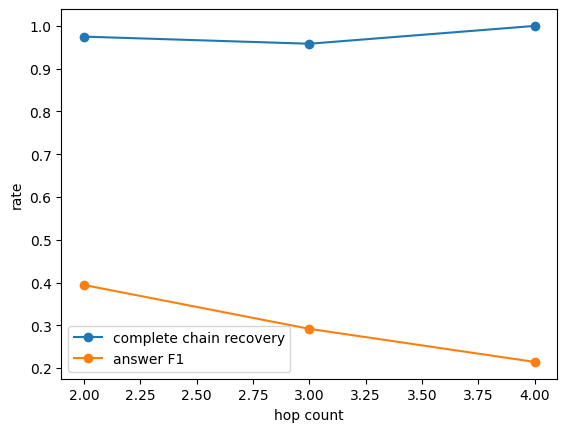

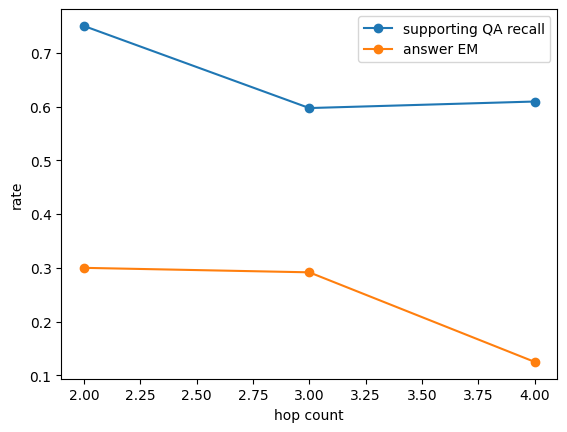

,dataset,questions,invalid_decomposition,retrieval_error,chain_not_recovered,supporting_recall_below_1,answer_wrong
0,musique,80,0,0,2,49,59


,question_id,hop_count,decomposition_valid,retrieval_error,chain_recovered


In [8]:

# === Q11: MuSiQue Transfer And Scaling ===
# CPU-only transfer analysis using the same score_default_run helper as Q10C.
from pathlib import Path
import matplotlib.pyplot as plt

figures_dir = WORK_ROOT / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

scored_musique = score_default_run('musique', packages['musique'])

musique_by_hop = scored_musique.groupby('hop_count').agg(
    questions=('question_id', 'count'),
    supporting_qa_recall=('supporting_recall', 'mean'),
    complete_chain_recovery=('chain_recovered', 'mean'),
    mean_surviving_chains=('surviving_chains', 'mean'),
    mean_evidence_size=('evidence_size', 'mean'),
    mean_answer_context_tokens=('answer_context_tokens', 'mean'),
    EM=('exact_match', 'mean'),
    F1=('token_f1', 'mean'),
).reset_index()
display(musique_by_hop)

transfer_comparison = pd.concat([
    q10_overall_table(scored_2wiki).assign(dataset='2wiki'),
    q10_overall_table(scored_musique).assign(dataset='musique'),
], ignore_index=True)
display(transfer_comparison[['dataset', 'questions', 'chain_recovery_rate', 'mean_supporting_recall', 'exact_match', 'token_f1', 'mean_evidence_size', 'mean_retrieval_seconds', 'mean_answer_seconds']])

fig, ax = plt.subplots()
ax.plot(musique_by_hop['hop_count'], musique_by_hop['complete_chain_recovery'], marker='o', label='complete chain recovery')
ax.plot(musique_by_hop['hop_count'], musique_by_hop['F1'], marker='o', label='answer F1')
ax.set_xlabel('hop count')
ax.set_ylabel('rate')
ax.legend()
fig.savefig(figures_dir / 'musique_hop_scaling.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots()
ax.plot(musique_by_hop['hop_count'], musique_by_hop['supporting_qa_recall'], marker='o', label='supporting QA recall')
ax.plot(musique_by_hop['hop_count'], musique_by_hop['EM'], marker='o', label='answer EM')
ax.set_xlabel('hop count')
ax.set_ylabel('rate')
ax.legend()
fig.savefig(figures_dir / 'musique_recall_answer_scaling.png', bbox_inches='tight')
plt.show()

error_attribution = pd.DataFrame([{
    'dataset': 'musique',
    'questions': len(scored_musique),
    'invalid_decomposition': int((~scored_musique['decomposition_valid']).sum()),
    'retrieval_error': int(scored_musique['retrieval_error'].sum()),
    'chain_not_recovered': int((~scored_musique['chain_recovered']).sum()),
    'supporting_recall_below_1': int((scored_musique['supporting_recall'].fillna(0) < 1.0).sum()),
    'answer_wrong': int((scored_musique['exact_match'].fillna(0) < 1.0).sum()),
}])
display(error_attribution)

error_rows = scored_musique[scored_musique['retrieval_error'] | (~scored_musique['decomposition_valid'])]
display(error_rows[['question_id', 'hop_count', 'decomposition_valid', 'retrieval_error', 'chain_recovered']].head(10))


### Your written response for Question 11

For MuSiQue, the  2Wiki configuration transferred without decomposition or retrieval-error rows in the displayed audit, however, performance still changes with hop count. The 2-hop subset had 40 questions, supporting-QA recall of 0.75, complete-chain recovery of 0.975, EM of 0.30, and F1 of 0.394. The 3-hop subset had 24 questions, supporting recall of about 0.597, chain recovery of 0.958, EM of 0.292, and F1 of 0.292. The 4-hop subset had 16 questions, supporting recall of about 0.609, chain recovery of 1.0, EM of 0.125, and F1 of 0.214.

Complete-chain recovery is conjunctive since a question is counted as recovered only if the whole multi-hop chain survives. Missing one required hop, substituting the wrong parent answer, or pruning the correct intermediate state can make the whole chain fail. Answer F1 is not conjunctive in the same way since a model can receive partial credit for an incomplete string, a near miss, or an answer produced from incomplete evidence. This is why chain recovery and F1 should not be interpreted as the same quantity.

The plot shows that complete-chain recovery stays high across 2-, 3-, and 4-hop cases, while answer F1 falls as hop count increases. That pattern suggests the answerer, not only retrieval, becomes a larger bottleneck as reasoning depth grows. More hops require the model to combine more intermediate facts and preserve more role/state information when forming the final answer.


## Question 12 — reproducibility and final submission (12 points)

Q12A and Q12B are CPU-only finalization cells. They do not rerun decomposition, RICR, ablations, or answer generation. They join the saved checkpoints into the richer Section 9.2 prediction schema, validate counts and held-out leakage, and write `environment.json`, `environment.txt`, and `RUNME.md`.

Run them after Q10C and Q11 so the final metric tables and runtime summaries are available in memory.


In [9]:

# === Q12A: Submission Materialization And Validation ===
# CPU-only final schema materialization. This joins decompositions, RICR traces,
# and answers into the richer prediction-record schema requested by Section 9.2.
import shutil

SUBMISSION_ROOT = WORK_ROOT / 'submission'
required_files = {
    SUBMISSION_ROOT/'results/2wiki_dev.jsonl': 80,
    SUBMISSION_ROOT/'predictions/2wiki_heldout.jsonl': 20,
    SUBMISSION_ROOT/'results/musique_dev.jsonl': 80,
    SUBMISSION_ROOT/'predictions/musique_heldout.jsonl': 20,
}
REQUIRED_PREDICTION_FIELDS = {
    'dataset', 'split', 'question_id', 'question', 'predicted_decomposition',
    'decomposition_valid', 'retrieval_backend', 'beam_width', 'candidates_per_hop',
    'chains', 'evidence_qa_ids', 'predicted_answer', 'latency_ms', 'answer_context_tokens',
}
HELDOUT_FORBIDDEN_FIELDS = {
    'answer', 'answer_aliases', 'supporting_facts', 'supporting_document_ids',
    'evidences', 'evidence', 'gold_answer', 'gold_aliases', 'gold_supporting_facts',
}

def q12_ms(value):
    return round(float(value) * 1000.0, 3) if value is not None else None

def q12_answer_context_tokens(answer_row):
    evidence_lines = answer_row.get('answer_evidence', ()) if answer_row else ()
    return sum(len(str(line).split()) for line in evidence_lines)

def q12_compact_chains(trace):
    chains = []
    for chain in (trace or {}).get('chains', ()):
        steps = chain.get('steps', ())
        chains.append({
            'qa_ids': [step.get('qa_uid') for step in steps],
            'answers': [name for step in steps for name in step.get('answer_names', ())],
            'hop_scores': [step.get('score') for step in steps],
            'chain_score': chain.get('score'),
            'last_hop_score': chain.get('last_hop_score'),
        })
    return chains

def q12_record(dataset, split, question, plan_row, trace_row, answer_row):
    trace = trace_row.get('trace') if trace_row and not trace_row.get('error') else {}
    evidence = trace.get('evidence', ()) if trace else ()
    record = {
        'dataset': dataset,
        'split': split,
        'question_id': str(question['question_id']),
        'question': question.get('question'),
        'predicted_decomposition': plan_row.get('predicted_decomposition') if plan_row else None,
        'decomposition_valid': bool(plan_row and plan_row.get('decomposition_valid')),
        'retrieval_backend': 'dual_hybrid',
        'beam_width': BEAM_WIDTH,
        'candidates_per_hop': CANDIDATES_PER_HOP,
        'chains': q12_compact_chains(trace),
        'evidence_qa_ids': [candidate.get('qa_uid') for candidate in evidence if candidate.get('qa_uid')],
        'predicted_answer': answer_row.get('predicted_answer') if answer_row else None,
        'latency_ms': {
            'decomposition': q12_ms(plan_row.get('seconds')) if plan_row else None,
            'retrieval_ricr': q12_ms(trace_row.get('retrieval_seconds')) if trace_row else None,
            'answer': q12_ms(answer_row.get('answer_seconds')) if answer_row else None,
        },
        'answer_context_tokens': q12_answer_context_tokens(answer_row),
    }
    if split == 'development' and answer_row:
        record['exact_match'] = answer_row.get('exact_match')
        record['token_f1'] = answer_row.get('token_f1')
    return record

def materialize_submission(dataset, package):
    plans = {
        str(row['question_id']): row
        for row in read_jsonl(WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl')
    }
    traces = {
        str(row['question_id']): row
        for row in read_jsonl(WORK_ROOT / 'cache' / dataset / 'ricr_traces.jsonl')
        if row.get('configuration') == 'default'
    }
    answers = {
        str(row['question_id']): row
        for row in read_jsonl(WORK_ROOT / 'cache' / dataset / 'answers.jsonl')
    }

    for split_name, package_split, output_dir, expected in [
        ('development', 'public', 'results', 80),
        ('held_out', 'held_out', 'predictions', 20),
    ]:
        path = SUBMISSION_ROOT / output_dir / f'{dataset}_{"dev" if split_name == "development" else "heldout"}.jsonl'
        path.parent.mkdir(parents=True, exist_ok=True)
        with path.open('w', encoding='utf-8') as handle:
            for question in package.questions(package_split):
                qid = str(question['question_id'])
                record = q12_record(dataset, split_name, question, plans.get(qid), traces.get(qid), answers.get(qid))
                handle.write(json.dumps(record, ensure_ascii=False) + '\n')

    preferred_heldout = SUBMISSION_ROOT / 'predictions' / f'{dataset}_heldout.jsonl'
    compatibility_heldout = SUBMISSION_ROOT / 'predictions' / f'{dataset}_held_out.jsonl'
    if preferred_heldout.exists():
        shutil.copy2(preferred_heldout, compatibility_heldout)

def validate_submission_file(path, expected):
    import math

    rows = read_jsonl(path)
    ids = [row.get('question_id') for row in rows]
    assert len(ids) == len(set(ids)), f'{path}: duplicate question_id values'
    assert len(rows) == expected, f'{path}: expected {expected} rows, found {len(rows)}'

    dataset = 'musique' if 'musique' in path.name else '2wiki'
    package = packages[dataset]
    is_heldout = 'heldout' in path.name or 'held_out' in path.name
    split = 'held_out' if is_heldout else 'public'
    expected_ids = {str(row['question_id']) for row in package.questions(split)}
    assert {str(value) for value in ids} == expected_ids, f'{path}: ID set does not match {split} split'

    for row in rows:
        missing = REQUIRED_PREDICTION_FIELDS - set(row)
        assert not missing, f'{path}: missing required fields {sorted(missing)}'
        for key, value in row.items():
            if isinstance(value, float):
                assert math.isfinite(value), f'{path}: non-finite value for {key}'
        if is_heldout:
            forbidden = HELDOUT_FORBIDDEN_FIELDS & set(row)
            assert not forbidden, f'{path}: disallowed held-out fields {sorted(forbidden)}'

if QUESTION_LIMIT is None:
    for dataset in DATASETS:
        materialize_submission(dataset, packages[dataset])

    required_files = {
        SUBMISSION_ROOT/'results/2wiki_dev.jsonl': 80,
        SUBMISSION_ROOT/'predictions/2wiki_heldout.jsonl': 20,
        SUBMISSION_ROOT/'results/musique_dev.jsonl': 80,
        SUBMISSION_ROOT/'predictions/musique_heldout.jsonl': 20,
    }
    for path, expected in required_files.items():
        validate_submission_file(path, expected)
        print(f'validated: {path} rows={expected}')
    print('All required submission files validated with Section 9.2 schema.')
else:
    print('Final validation waits until QUESTION_LIMIT=None.')


validated: /content/drive/MyDrive/panini-course-project-work/submission/results/2wiki_dev.jsonl rows=80
validated: /content/drive/MyDrive/panini-course-project-work/submission/predictions/2wiki_heldout.jsonl rows=20
validated: /content/drive/MyDrive/panini-course-project-work/submission/results/musique_dev.jsonl rows=80
validated: /content/drive/MyDrive/panini-course-project-work/submission/predictions/musique_heldout.jsonl rows=20
All required submission files validated with Section 9.2 schema.


In [10]:

# === Q12B: Environment And RUNME ===
# CPU-only handoff metadata. Records configuration, model IDs, measured runtime
# summaries, restart points, and the final commit hash.
import subprocess
import pandas as pd

model_cfg = json.loads((PACKAGE_ROOTS['2wiki'] / 'models/model_config.json').read_text())

def q12_seconds_summary(path, field_candidates):
    rows = read_jsonl(path) if path.exists() else []
    values = []
    for row in rows:
        for field in field_candidates:
            if row.get(field) is not None:
                values.append(float(row[field]))
                break
    if not values:
        return {'rows': len(rows), 'mean_seconds': None, 'median_seconds': None, 'p95_seconds': None}
    series = pd.Series(values)
    return {
        'rows': len(rows),
        'mean_seconds': round(float(series.mean()), 3),
        'median_seconds': round(float(series.median()), 3),
        'p95_seconds': round(float(series.quantile(0.95)), 3),
    }

runtime_summary = {}
for dataset in DATASETS:
    runtime_summary[dataset] = {
        'decomposition': q12_seconds_summary(WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl', ['seconds']),
        'ricr_default': q12_seconds_summary(WORK_ROOT / 'cache' / dataset / 'ricr_traces.jsonl', ['retrieval_seconds', 'seconds']),
        'answers': q12_seconds_summary(WORK_ROOT / 'cache' / dataset / 'answers.jsonl', ['answer_seconds']),
    }

try:
    commit_hash = subprocess.run(
        ['git', 'rev-parse', 'HEAD'], cwd=REPO_ROOT, check=True,
        capture_output=True, text=True,
    ).stdout.strip()
except Exception:
    commit_hash = 'unknown'

environment = {
    'python': sys.version,
    'platform': platform.platform(),
    'question_limit': QUESTION_LIMIT,
    'beam_width': BEAM_WIDTH,
    'candidates_per_hop': CANDIDATES_PER_HOP,
    'retrieval_pool': RETRIEVAL_POOL,
    'rrf_constant': RRF_CONSTANT,
    'multi_parent_threshold': MULTI_PARENT_THRESHOLD,
    'models': model_cfg,
    'runtime_summary': runtime_summary,
    'commit_hash': commit_hash,
    'package_manifests': {
        name: package.manifest for name, package in packages.items()
    },
}
(WORK_ROOT/'environment.json').write_text(
    json.dumps(environment, indent=2, ensure_ascii=False), encoding='utf-8')
(WORK_ROOT/'environment.txt').write_text(
    json.dumps(environment, indent=2, ensure_ascii=False), encoding='utf-8')
print('environment:', WORK_ROOT/'environment.json')
print('environment text:', WORK_ROOT/'environment.txt')

runme_lines = [
    '# RUNME',
    '',
    '## Fresh Colab setup',
    '1. Open `Panini_Course_Project.ipynb` in Colab.',
    '2. Use Runtime > Change runtime type > GPU only for Q4B, Q7A, Q8B, Q9, and Q10A.',
    '3. Run the Foundation cells after every runtime reset.',
    '4. Keep `MOUNT_DRIVE_IN_COLAB=True` and `REQUIRE_DURABLE_WORK_ROOT=True` so checkpoints are durable.',
    '',
    '## Commands and execution order',
    '1. `pip install -q -r requirements-colab.txt` is executed by the setup cell.',
    '2. Smoke test with `QUESTION_LIMIT=2` and all expensive flags disabled.',
    '3. For final runs set `QUESTION_LIMIT=None` and enable exactly one expensive flag at a time.',
    '4. Stage A: `RUN_DECOMPOSITION_STAGE=True`; run Q4A then Q4B.',
    '5. Stage B: `RUN_RERANK_AND_RICR_STAGE=True`; run Q5, Q6, Q7 helpers, Q8A, then Q8B.',
    '6. Q9 ablations: `RUN_ABLATIONS=True`; run Q9 bootstrap then Q9.',
    '7. Stage C: `RUN_ANSWER_STAGE=True`; run Q10A, then CPU-only Q10C, Q11, Q12A, Q12B.',
    '',
    '## Seeds and frozen configuration',
    f'- BEAM_WIDTH={BEAM_WIDTH}',
    f'- CANDIDATES_PER_HOP={CANDIDATES_PER_HOP}',
    f'- RETRIEVAL_POOL={RETRIEVAL_POOL}',
    f'- RRF_CONSTANT={RRF_CONSTANT}',
    f'- MULTI_PARENT_THRESHOLD={MULTI_PARENT_THRESHOLD}',
    '- Reconciliation audit sampling and centrality approximations use seed 232.',
    '- 2Wiki settings were frozen before MuSiQue transfer evaluation.',
    '',
    '## Models',
    f'- Decomposer: {model_cfg.get("decomposer", {}).get("model")}',
    f'- Reranker: {model_cfg.get("reranker", {}).get("model")}',
    f'- Reranker T4 fallback: {model_cfg.get("reranker", {}).get("free_colab_t4_fallback")}',
    f'- Answer model: {model_cfg.get("answer_model", {}).get("model")}',
    '',
    '## Measured runtime summaries',
    '```json',
    json.dumps(runtime_summary, indent=2),
    '```',
    '',
    '## Restart points',
    f'- `{WORK_ROOT / "cache"}/<dataset>/decompositions.jsonl`',
    f'- `{WORK_ROOT / "cache"}/<dataset>/ricr_traces.jsonl` keyed by `configuration`',
    f'- `{WORK_ROOT / "cache"}/<dataset>/answers.jsonl`',
    f'- `{WORK_ROOT / "submission"}/results/<dataset>_dev.jsonl`',
    f'- `{WORK_ROOT / "submission"}/predictions/<dataset>_heldout.jsonl`',
    'Each checkpoint resumes by stable `question_id`; rerunning skips completed rows.',
    '',
    '## Final commit',
    f'- {commit_hash}',
]
(WORK_ROOT / 'RUNME.md').write_text('\n'.join(runme_lines), encoding='utf-8')
print('runme:', WORK_ROOT / 'RUNME.md')


environment: /content/drive/MyDrive/panini-course-project-work/environment.json
environment text: /content/drive/MyDrive/panini-course-project-work/environment.txt
runme: /content/drive/MyDrive/panini-course-project-work/RUNME.md


### Your written response for Question 12

Each input question is first decomposed into a structured plan. The plan is validated as a dependency graph so later retrieval nodes can refer to answers produced by earlier nodes. Retrieval then builds candidate pools for each instantiated subquestion. The system uses the supplied retrieval resources where possible and falls back to BM25 for dynamically generated queries whose dense query embeddings are not precomputed. A Qwen reranker scores candidate QA evidence, and RICR executes the decomposition as a beam search over the dependency DAG. At converging nodes, parent answer candidates are combined before issuing the child query, so the later search is conditioned on the joint state of multiple earlier answers. The surviving final beams provide deduplicated QA evidence and role/state strings to the answer model. The answer model then produces a final prediction without access to gold labels, source documents, or graph neighbors.

The main protection in the design is that every expensive stage writes restartable JSONL checkpoints. Decompositions are saved under `cache/<dataset>/decompositions.jsonl`, RICR traces under `cache/<dataset>/ricr_traces.jsonl`, and generated answers under `cache/<dataset>/answers.jsonl`. This protects the run from Colab disconnects and also prevents keeping multiple Qwen models resident at the same time. Q12A also checks the exact ID sets and row counts for the four required files, not just whether files exist, which is an additional protection. The held-out files are restricted to label-free prediction fields.

The main failure mode is evidence and state loss before answer generation. A valid decomposition can still retrieve incomplete evidence, prune the correct intermediate candidate, or form a later-hop query with the wrong parent answer. Even when the chain is recovered, the answer model may synthesize the wrong final comparison or entity, especially on longer MuSiQue questions.

To reproduce the run, another student should mount Google Drive in Colab, run the foundation cells, set `QUESTION_LIMIT=None`, and enable exactly one expensive stage at a time: Stage A for decomposition, Stage B for reranking/RICR, and Stage C for answer generation. After each stage, the JSONL checkpoints can be inspected and rerun safely. Q12A materializes and validates the four submission JSONL files, and Q12B records the environment, frozen configuration, model IDs, commit hash, and resume instructions in `environment.json`, `environment.txt`, and `RUNME.md`.

## Final pre-submission checklist

- [ ] `QUESTION_LIMIT` was set to `None` for final runs.
- [ ] All supplied tests pass, plus your reconciliation and failure-case tests.
- [ ] Every expensive stage resumes from JSONL by stable question ID.
- [ ] Only one Qwen model was resident at a time.
- [ ] No embeddings were generated.
- [ ] The 2Wiki configuration was frozen before MuSiQue evaluation.
- [ ] All twelve written-response cells were replaced with your own analysis.
- [ ] Held-out outputs contain no answer, alias, or supporting-evidence labels.
- [ ] Four required JSONL files, the executed notebook, figures, tests,
  `environment.json`, and `RUNME.md` are included.